# Complete Candidate Clustering Pipeline

## Pipeline Overview

This notebook contains the complete end-to-end pipeline:

1. **Phase 1**: Skill Normalization (Tier 1 + Tier 2)
   - Input: `data/processed/candidates_raw.json` (1,271 raw skills)
   - Output: `data/processed/candidates_normalized_tier2.json` (786 normalized skills)
   - Reduction: ~38%

2. **Phase 2**: Feature Engineering
   - Input: Normalized candidates
   - Output: Feature matrix (158 × 1,902 features)
   - Includes: Core skills, inferred skills, domain aggregations, weakness modeling

3. **Phase 3**: Multi-Label Clustering
   - Input: Feature matrix
   - Output: 12 clusters with multi-label assignments
   - Method: Distance-based GMM

4. **Phase 4**: Visualization & Exploration
   - Interactive cluster exploration
   - Explain why candidates belong to specific clusters

# Complete Candidate Clustering Pipeline - Google Colab Ready

## Overview

This notebook is **self-contained** and ready to run on Google Colab without external dependencies.

### Pipeline Phases:

0. **Phase 0**: CSV Transformation
   - Input: `agent_scores.csv` (30,422 rows from evaluators)
   - Output: `candidates_raw.json` (158 candidates with aggregated scores)

1. **Phase 1**: Skill Normalization (Tier 1 + Tier 2)
   - Input: `candidates_raw.json` (1,271 raw skills)
   - Output: `candidates_normalized_tier2.json` (786 normalized skills)
   - Reduction: ~38%

2. **Phase 2**: Feature Engineering
   - Input: Normalized candidates
   - Output: Feature matrix (158 × 1,902 features)
   - Includes: Core skills, inferred skills, domain aggregations, weakness modeling

3. **Phase 3**: Multi-Label Clustering
   - Input: Feature matrix
   - Output: 12 clusters with multi-label assignments
   - Method: Distance-based GMM

4. **Phase 4**: Visualization & Exploration
   - Interactive cluster exploration
   - Explain why candidates belong to specific clusters

### Running on Google Colab:
1. Upload `agent_scores.csv` to Colab
2. Run all cells sequentially
3. All required classes are embedded in this notebook

---
# Embedded Custom Modules

These classes are embedded directly in the notebook for Google Colab compatibility.

---
# Phase 0: CSV Transformation

Transform `agent_scores.csv` (evaluator-level data) to `candidates_raw.json` (candidate-level data).

In [37]:
# # Option 1: Upload file manually
# from google.colab import files
# import os

# if not os.path.exists('agent_scores.csv'):
#     print('Please upload agent_scores.csv:')
#     uploaded = files.upload()
#     print('✓ File uploaded!')
# else:
#     print('✓ agent_scores.csv found!')

# # Create directories
# os.makedirs('data/processed', exist_ok=True)
# print('✓ Directories created!')

In [38]:
import pandas as pd
import json
from pathlib import Path

print("="*70)
print("PHASE 0: TRANSFORM agent_scores.csv -> candidates_raw.json")
print("="*70)

# Load agent_scores.csv
print("\n1. Loading agent_scores.csv...")
df = pd.read_csv('data/raw/agent_scores_202512100720.csv')

print(f"   - Total rows: {len(df)}")
print(f"   - Columns: {list(df.columns)}")
print(f"   - Unique candidates (meeting_id): {df['meeting_id'].nunique()}")
print(f"   - Unique skills (criteria_name): {df['criteria_name'].nunique()}")

# Aggregate scores per candidate per skill (average across evaluators)
print("\n2. Aggregating scores per candidate per skill...")
print("   (Taking average across multiple evaluators)")

candidate_skills = df.groupby(['meeting_id', 'criteria_name']).agg({
    'criteria_score': 'mean'
}).reset_index()

print(f"   [OK] After aggregation: {len(candidate_skills)} candidate-skill pairs")

# Transform to candidate-level format
print("\n3. Transforming to candidate-level format...")

candidates_raw = []

for candidate_id in candidate_skills['meeting_id'].unique():
    # Get all skills for this candidate
    candidate_data = candidate_skills[candidate_skills['meeting_id'] == candidate_id]
    
    # Extract skills and scores
    skills = candidate_data['criteria_name'].tolist()
    skill_scores = dict(zip(
        candidate_data['criteria_name'],
        candidate_data['criteria_score']
    ))
    
    candidates_raw.append({
        'candidate_id': candidate_id,
        'skills': skills,
        'skill_scores': skill_scores
    })

print(f"   [OK] Created {len(candidates_raw)} candidate profiles")

# Statistics
total_skills = sum(len(c['skills']) for c in candidates_raw)
avg_skills = total_skills / len(candidates_raw)
unique_skills = len(set(skill for c in candidates_raw for skill in c['skills']))

print(f"\n   Statistics:")
print(f"   - Total candidates: {len(candidates_raw)}")
print(f"   - Unique skills: {unique_skills}")
print(f"   - Avg skills per candidate: {avg_skills:.1f}")

# Save to JSON
print("\n4. Saving to candidates_raw_202512100720.json...")

with open('data/processed/candidates_raw_202512100720.json', 'w', encoding='utf-8') as f:
    json.dump(candidates_raw, f, indent=2, ensure_ascii=False)

print(f"   [OK] Saved to data/processed/candidates_raw_202512100720.json")

print("\n" + "="*70)
print("PHASE 0 COMPLETE")
print("="*70)

PHASE 0: TRANSFORM agent_scores.csv -> candidates_raw.json

1. Loading agent_scores.csv...
   - Total rows: 41142
   - Columns: ['meeting_id', 'role_name', 'question', 'criteria_name', 'criteria_score', 'criteria_weight']
   - Unique candidates (meeting_id): 206
   - Unique skills (criteria_name): 1321

2. Aggregating scores per candidate per skill...
   (Taking average across multiple evaluators)
   [OK] After aggregation: 4208 candidate-skill pairs

3. Transforming to candidate-level format...
   [OK] Created 206 candidate profiles

   Statistics:
   - Total candidates: 206
   - Unique skills: 1321
   - Avg skills per candidate: 20.4

4. Saving to candidates_raw_202512100720.json...
   [OK] Saved to data/processed/candidates_raw_202512100720.json

PHASE 0 COMPLETE


## Upload Data File

**IMPORTANT**: Upload `agent_scores.csv` before running further cells.

On Google Colab, use the file upload widget or place the file in your Google Drive.

In [39]:
!uv pip install -q sentence-transformers scikit-learn pandas numpy matplotlib seaborn umap-learn hdbscan openpyxl

print('✓ All dependencies installed!')

✓ All dependencies installed!


---
# Setup: Install Required Libraries

Run this first on Google Colab to install all dependencies.

## Setup: Import Libraries

In [95]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering & Dimensionality Reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import pairwise_distances
import umap
import hdbscan

# Add src to path
sys.path.insert(0, str(Path.cwd() / "src"))

# Import custom modules

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('✓ All libraries imported successfully!')

✓ All libraries imported successfully!


In [96]:
"""
Skill Normalization Module - 3-Tier Pipeline

Handles noisy LLM-generated skill names and normalizes them to canonical forms.

Tier 1: Rule-based normalization (lowercase, versions, abbreviations, typos)
Tier 2: Embedding-based semantic clustering
Tier 3: Co-occurrence graph disambiguation
"""

import json
import logging
import re
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import hdbscan
import networkx as nx
from community import community_louvain

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class SkillNormalizer:
    """
    3-Tier skill normalization pipeline for handling noisy LLM-generated skills.
    """

    def __init__(
        self,
        rules_path: Optional[str] = None,
        embedding_model: str = "sentence-transformers/all-mpnet-base-v2",
        min_cluster_size: int = 3,
        similarity_threshold: float = 0.85,
    ):
        """
        Initialize the skill normalizer.

        Args:
            rules_path: Path to normalization rules JSON file
            embedding_model: Name of sentence transformer model
            min_cluster_size: Minimum cluster size for HDBSCAN
            similarity_threshold: Threshold for semantic similarity
        """
        # For notebook: use relative path from current directory
        self.rules_path = rules_path or "config/normalization_rules.json"
        self.embedding_model_name = embedding_model
        self.min_cluster_size = min_cluster_size
        self.similarity_threshold = similarity_threshold

        # Load normalization rules
        self._load_rules()

        # Initialize embedding model (lazy loading)
        self._embedding_model = None

    def _load_rules(self):
        """Load normalization rules from JSON file."""
        try:
            with open(self.rules_path, "r", encoding="utf-8") as f:
                rules = json.load(f)
        except FileNotFoundError:
            logger.warning(f"Rules file not found at {self.rules_path}. Using empty rules.")
            rules = {"synonyms": {}, "abbreviations": {}, "typos": {}}

        # Build mapping dictionaries
        self.synonyms = rules.get("synonyms", {})
        self.abbreviations = rules.get("abbreviations", {})
        self.typos = rules.get("typos", {})

        # Reverse lookup for synonyms (canonical -> [variants])
        self.canonical_to_variants = defaultdict(list)
        for variant, canonical in self.synonyms.items():
            self.canonical_to_variants[canonical].append(variant)

    @property
    def embedding_model(self):
        """Lazy load embedding model."""
        if self._embedding_model is None:
            logger.info(f"Loading embedding model: {self.embedding_model_name}")
            self._embedding_model = SentenceTransformer(self.embedding_model_name)
        return self._embedding_model

    # -------------------------------------------------------------------------
    # Tier 1: Rule-Based Normalization
    # -------------------------------------------------------------------------

    def _clean_skill_name(self, skill: str) -> str:
        """
        Clean skill name (lowercase, strip, normalize whitespace).

        Example: "  React.js  " -> "react.js"
        """
        skill = skill.strip().lower()
        skill = re.sub(r"\s+", " ", skill)  # Normalize whitespace
        return skill

    def _remove_version_suffix(self, skill: str) -> str:
        """
        Remove version numbers and 'x' suffixes.

        Examples:
            "python 3.9" -> "python"
            "node.js 18" -> "node.js"
            "react 18.x" -> "react"
        """
        # Remove version patterns: "3.9", "18", "18.x"
        skill = re.sub(r"\s+\d+(\.\d+)?(\.\w+)?$", "", skill)
        skill = re.sub(r"\s+v?\d+$", "", skill)
        return skill

    def _expand_abbreviations(self, skill: str) -> str:
        """
        Expand known abbreviations.

        Example: "js" -> "javascript"
        """
        return self.abbreviations.get(skill, skill)

    def _fix_typos(self, skill: str) -> str:
        """
        Fix common typos.

        Example: "javascrip" -> "javascript"
        """
        return self.typos.get(skill, skill)

    def _apply_synonyms(self, skill: str) -> str:
        """
        Map skill to canonical form using synonym dictionary.

        Example: "reactjs" -> "react"
        """
        return self.synonyms.get(skill, skill)

    def normalize_tier1(self, skill: str) -> str:
        """
        Apply Tier 1 rule-based normalization.

        Pipeline:
            1. Clean (lowercase, strip, normalize whitespace)
            2. Remove version suffixes
            3. Expand abbreviations
            4. Fix typos
            5. Apply synonym mapping

        Args:
            skill: Raw skill name

        Returns:
            Normalized skill name
        """
        skill = self._clean_skill_name(skill)
        skill = self._remove_version_suffix(skill)
        skill = self._expand_abbreviations(skill)
        skill = self._fix_typos(skill)
        skill = self._apply_synonyms(skill)
        return skill

    # -------------------------------------------------------------------------
    # Tier 2: Embedding-Based Semantic Clustering
    # -------------------------------------------------------------------------

    def _compute_embeddings(self, skills: List[str]) -> np.ndarray:
        """
        Compute sentence embeddings for skills.

        Args:
            skills: List of skill names

        Returns:
            Embedding matrix (n_skills, embedding_dim)
        """
        embeddings = self.embedding_model.encode(skills, show_progress_bar=True)
        return embeddings

    def _cluster_skills_hdbscan(
        self, embeddings: np.ndarray, min_cluster_size: int = 3
    ) -> np.ndarray:
        """
        Cluster skills using HDBSCAN.

        Args:
            embeddings: Skill embeddings
            min_cluster_size: Minimum cluster size

        Returns:
            Cluster labels (noise = -1)
        """
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            metric="euclidean",
            cluster_selection_method="eom",
        )
        labels = clusterer.fit_predict(embeddings)
        return labels

    def _select_cluster_representative(
        self, cluster_skills: List[str], cluster_embeddings: np.ndarray
    ) -> str:
        """
        Select the most representative skill name for a cluster.

        Strategy:
            1. Prefer shorter names (more concise)
            2. Prefer names closer to cluster centroid
            3. Prefer lowercase names without special characters

        Args:
            cluster_skills: Skills in the cluster
            cluster_embeddings: Embeddings of cluster skills

        Returns:
            Canonical skill name
        """
        # Compute centroid
        centroid = cluster_embeddings.mean(axis=0, keepdims=True)

        # Compute distances to centroid
        distances = cosine_similarity(cluster_embeddings, centroid).flatten()

        # Score each skill
        scores = []
        for i, skill in enumerate(cluster_skills):
            # Prefer shorter names
            length_penalty = len(skill) / 50.0

            # Prefer closer to centroid (higher similarity)
            centroid_score = distances[i]

            # Prefer simple names (no special chars)
            simplicity_bonus = 0.1 if re.match(r"^[a-z0-9 ]+$", skill) else 0

            # Combined score (higher is better)
            score = centroid_score - length_penalty + simplicity_bonus
            scores.append(score)

        # Return skill with highest score
        best_idx = np.argmax(scores)
        return cluster_skills[best_idx]

    def normalize_tier2(
        self, skills: List[str], tier1_normalized: Dict[str, str]
    ) -> Dict[str, Tuple[str, float]]:
        """
        Apply Tier 2 semantic clustering to group similar skills.

        Args:
            skills: List of unique Tier 1 normalized skills
            tier1_normalized: Mapping from raw skills to Tier 1 normalized

        Returns:
            Mapping from Tier 1 normalized skill -> (Tier 2 canonical, confidence)
        """
        logger.info(f"Tier 2: Clustering {len(skills)} unique skills...")

        # Compute embeddings
        embeddings = self._compute_embeddings(skills)

        # Cluster using HDBSCAN
        labels = self._cluster_skills_hdbscan(embeddings, self.min_cluster_size)

        # Build clusters
        clusters = defaultdict(list)
        cluster_embeddings_dict = defaultdict(list)
        for skill, label, embedding in zip(skills, labels, embeddings):
            if label != -1:  # Skip noise
                clusters[label].append(skill)
                cluster_embeddings_dict[label].append(embedding)

        # Select canonical skill for each cluster
        tier2_mapping = {}
        for label, cluster_skills in clusters.items():
            cluster_embeddings = np.array(cluster_embeddings_dict[label])
            canonical = self._select_cluster_representative(
                cluster_skills, cluster_embeddings
            )

            # Map all skills in cluster to canonical
            for skill in cluster_skills:
                # Confidence = similarity to canonical
                skill_embedding = embeddings[skills.index(skill)]
                canonical_embedding = embeddings[skills.index(canonical)]
                similarity = cosine_similarity(
                    skill_embedding.reshape(1, -1), canonical_embedding.reshape(1, -1)
                )[0, 0]
                tier2_mapping[skill] = (canonical, float(similarity))

        # For unclustered skills (noise), map to themselves with confidence 1.0
        for skill in skills:
            if skill not in tier2_mapping:
                tier2_mapping[skill] = (skill, 1.0)

        logger.info(
            f"Tier 2: Clustered into {len(clusters)} groups ({len(tier2_mapping)} total mappings)"
        )

        return tier2_mapping

    # -------------------------------------------------------------------------
    # Tier 3: Co-occurrence Graph Disambiguation (Optional)
    # -------------------------------------------------------------------------

    def _build_cooccurrence_graph(
        self, candidate_skills: List[List[str]]
    ) -> nx.Graph:
        """
        Build a co-occurrence graph from candidate skill lists.

        Args:
            candidate_skills: List of skill lists per candidate

        Returns:
            Networkx graph with skills as nodes and co-occurrence counts as edge weights
        """
        G = nx.Graph()

        for skills in candidate_skills:
            # Add edges between all pairs of skills in this candidate
            for i, skill1 in enumerate(skills):
                for skill2 in skills[i + 1 :]:
                    if G.has_edge(skill1, skill2):
                        G[skill1][skill2]["weight"] += 1
                    else:
                        G.add_edge(skill1, skill2, weight=1)

        return G

    def _detect_communities(self, G: nx.Graph) -> Dict[str, int]:
        """
        Detect communities using Louvain algorithm.

        Args:
            G: Co-occurrence graph

        Returns:
            Mapping from skill -> community_id
        """
        partition = community_louvain.best_partition(G)
        return partition

    def normalize_tier3(
        self,
        candidate_skills: List[List[str]],
        tier2_mapping: Dict[str, Tuple[str, float]],
    ) -> Dict[str, Tuple[str, float]]:
        """
        Apply Tier 3 co-occurrence graph disambiguation.

        This refines Tier 2 results by considering which skills co-occur frequently.

        Args:
            candidate_skills: List of skill lists per candidate (Tier 2 normalized)
            tier2_mapping: Tier 2 skill mappings

        Returns:
            Refined mapping from skill -> (canonical, confidence)
        """
        logger.info("Tier 3: Building co-occurrence graph...")

        # Build graph
        G = self._build_cooccurrence_graph(candidate_skills)

        # Detect communities
        communities = self._detect_communities(G)

        # Refine mappings based on community structure
        # (For now, just return Tier 2 mappings - future enhancement)
        logger.info(f"Tier 3: Detected {len(set(communities.values()))} communities")

        return tier2_mapping

    # -------------------------------------------------------------------------
    # Main API
    # -------------------------------------------------------------------------

    def normalize(
        self, skill: str, use_tier2: bool = False, use_tier3: bool = False
    ) -> Tuple[str, float]:
        """
        Normalize a single skill.

        Args:
            skill: Raw skill name
            use_tier2: Whether to apply Tier 2 (semantic clustering)
            use_tier3: Whether to apply Tier 3 (co-occurrence disambiguation)

        Returns:
            (normalized_skill, confidence)
        """
        # Tier 1
        normalized = self.normalize_tier1(skill)

        if use_tier2 or use_tier3:
            raise NotImplementedError(
                "Tier 2/3 require batch processing. Use normalize_batch() instead."
            )

        return normalized, 1.0

    def normalize_batch(
        self,
        skills: List[str],
        use_tier2: bool = False,
        use_tier3: bool = False,
        candidate_skills: Optional[List[List[str]]] = None,
    ) -> Dict[str, Tuple[str, float]]:
        """
        Normalize a batch of skills.

        Args:
            skills: List of raw skill names
            use_tier2: Whether to apply Tier 2 (semantic clustering)
            use_tier3: Whether to apply Tier 3 (co-occurrence disambiguation)
            candidate_skills: For Tier 3, list of skill lists per candidate

        Returns:
            Mapping from raw skill -> (normalized skill, confidence)
        """
        # Tier 1: Rule-based normalization
        tier1_mapping = {}
        for skill in skills:
            tier1_normalized = self.normalize_tier1(skill)
            tier1_mapping[skill] = tier1_normalized

        # Get unique Tier 1 normalized skills
        unique_tier1_skills = list(set(tier1_mapping.values()))

        # Tier 2: Semantic clustering
        if use_tier2:
            tier2_mapping = self.normalize_tier2(unique_tier1_skills, tier1_mapping)

            # Map raw skills to Tier 2 canonical
            final_mapping = {}
            for raw_skill, tier1_skill in tier1_mapping.items():
                canonical, confidence = tier2_mapping[tier1_skill]
                final_mapping[raw_skill] = (canonical, confidence)

            # Tier 3: Co-occurrence disambiguation (optional)
            if use_tier3:
                if candidate_skills is None:
                    logger.warning(
                        "Tier 3 requires candidate_skills. Skipping Tier 3."
                    )
                else:
                    tier3_mapping = self.normalize_tier3(
                        candidate_skills, tier2_mapping
                    )

                    # Re-map raw skills to Tier 3 canonical
                    final_mapping = {}
                    for raw_skill, tier1_skill in tier1_mapping.items():
                        canonical, confidence = tier3_mapping[tier1_skill]
                        final_mapping[raw_skill] = (canonical, confidence)

            return final_mapping

        else:
            # Only Tier 1
            return {skill: (tier1_mapping[skill], 1.0) for skill in skills}

    def get_statistics(self, mapping: Dict[str, Tuple[str, float]]) -> Dict:
        """
        Compute statistics about normalization results.

        Args:
            mapping: Normalization mapping from normalize_batch()

        Returns:
            Dictionary with statistics
        """
        # Count unique raw vs canonical skills
        num_raw = len(mapping)
        num_canonical = len(set([canonical for canonical, _ in mapping.values()]))

        # Compute confidence distribution
        confidences = [conf for _, conf in mapping.values()]

        stats = {
            "num_raw_skills": num_raw,
            "num_canonical_skills": num_canonical,
            "reduction_count": num_raw - num_canonical,
            "reduction_percentage": (num_raw - num_canonical) / num_raw * 100
            if num_raw > 0
            else 0,
            "avg_confidence": float(np.mean(confidences)),
            "min_confidence": float(np.min(confidences)),
            "max_confidence": float(np.max(confidences)),
        }

        return stats


print("✓ SkillNormalizer class defined!")

✓ SkillNormalizer class defined!


In [97]:
"""
Feature Engineering Module - Phase 2

Extracts comprehensive features from normalized candidate data including:
- Core skill features
- Inferred skill scores
- Domain aggregations
- Weakness modeling
- Profile characteristics
"""

from typing import Dict, List, Tuple, Optional, Set
from collections import defaultdict
import numpy as np
import json
from pathlib import Path


class FeatureEngineer:
    """
    Feature engineering for candidate clustering.

    Generates ~600 dimensional feature vectors from normalized skills and scores,
    including weakness modeling and domain aggregations.
    """

    # Domain mapping: skill → domain(s)
    SKILL_TO_DOMAIN = {
        # Backend
        "python": ["Backend", "Data/ML"],
        "java": ["Backend"],
        "node.js": ["Backend"],
        "nodejs": ["Backend"],
        "go": ["Backend"],
        "golang": ["Backend"],
        "ruby": ["Backend"],
        "php": ["Backend"],
        "c#": ["Backend"],
        "csharp": ["Backend"],
        "scala": ["Backend"],
        "fastapi": ["Backend"],
        "django": ["Backend"],
        "flask": ["Backend"],
        "spring": ["Backend"],
        "express": ["Backend"],
        "express.js": ["Backend"],

        # Frontend
        "javascript": ["Frontend"],
        "typescript": ["Frontend"],
        "react": ["Frontend"],
        "react.js": ["Frontend"],
        "vue": ["Frontend"],
        "vue.js": ["Frontend"],
        "angular": ["Frontend"],
        "next.js": ["Frontend"],
        "nextjs": ["Frontend"],
        "svelte": ["Frontend"],
        "html": ["Frontend"],
        "css": ["Frontend"],
        "sass": ["Frontend"],
        "tailwind": ["Frontend"],
        "tailwindcss": ["Frontend"],
        "webpack": ["Frontend"],
        "redux": ["Frontend"],

        # Database
        "postgresql": ["Database"],
        "postgres": ["Database"],
        "mysql": ["Database"],
        "mongodb": ["Database"],
        "mongo": ["Database"],
        "redis": ["Database"],
        "elasticsearch": ["Database"],
        "cassandra": ["Database"],
        "dynamodb": ["Database"],
        "sql": ["Database"],
        "nosql": ["Database"],
        "data modeling": ["Database"],

        # DevOps
        "docker": ["DevOps"],
        "kubernetes": ["DevOps"],
        "k8s": ["DevOps"],
        "jenkins": ["DevOps"],
        "gitlab ci": ["DevOps"],
        "github actions": ["DevOps"],
        "terraform": ["DevOps"],
        "ansible": ["DevOps"],
        "ci/cd": ["DevOps"],
        "linux": ["DevOps"],
        "bash": ["DevOps"],
        "shell scripting": ["DevOps"],
        "monitoring": ["DevOps"],
        "prometheus": ["DevOps"],
        "grafana": ["DevOps"],

        # Cloud
        "aws": ["Cloud"],
        "amazon web services": ["Cloud"],
        "azure": ["Cloud"],
        "gcp": ["Cloud"],
        "google cloud": ["Cloud"],
        "lambda": ["Cloud"],
        "s3": ["Cloud"],
        "ec2": ["Cloud"],
        "cloudformation": ["Cloud"],

        # Data/ML
        "machine learning": ["Data/ML"],
        "deep learning": ["Data/ML"],
        "tensorflow": ["Data/ML"],
        "pytorch": ["Data/ML"],
        "pandas": ["Data/ML"],
        "numpy": ["Data/ML"],
        "scikit-learn": ["Data/ML"],
        "sklearn": ["Data/ML"],
        "data analysis": ["Data/ML"],
        "statistics": ["Data/ML"],
        "nlp": ["Data/ML"],
        "computer vision": ["Data/ML"],
        "jupyter": ["Data/ML"],

        # Testing
        "testing": ["Testing"],
        "unit testing": ["Testing"],
        "pytest": ["Testing"],
        "jest": ["Testing"],
        "selenium": ["Testing"],
        "test automation": ["Testing"],

        # Other
        "git": ["Tools"],
        "github": ["Tools"],
        "gitlab": ["Tools"],
        "agile": ["Soft Skills"],
        "scrum": ["Soft Skills"],
        "system design": ["Architecture"],
        "microservices": ["Architecture"],
        "rest api": ["Backend"],
        "restful": ["Backend"],
        "graphql": ["Backend"],
    }

    # Skill inference rules: skill → (inferred_skill, confidence)
    SKILL_INFERENCE_RULES = {
        # Framework implies language
        "react": [("javascript", 0.95)],
        "react.js": [("javascript", 0.95)],
        "vue": [("javascript", 0.95)],
        "vue.js": [("javascript", 0.95)],
        "angular": [("javascript", 0.95), ("typescript", 0.8)],
        "next.js": [("javascript", 0.95), ("react", 0.9)],
        "django": [("python", 0.95)],
        "flask": [("python", 0.95)],
        "fastapi": [("python", 0.95)],
        "spring": [("java", 0.95)],
        "express": [("node.js", 0.95), ("javascript", 0.9)],
        "express.js": [("node.js", 0.95), ("javascript", 0.9)],

        # DevOps implies base skills
        "docker": [("linux", 0.8)],
        "kubernetes": [("docker", 0.85), ("linux", 0.75), ("yaml", 0.8)],
        "k8s": [("docker", 0.85), ("linux", 0.75), ("yaml", 0.8)],
        "terraform": [("infrastructure as code", 0.9)],
        "ansible": [("linux", 0.8), ("yaml", 0.8)],

        # ML implies data skills
        "tensorflow": [("python", 0.95), ("machine learning", 0.9)],
        "pytorch": [("python", 0.95), ("machine learning", 0.9)],
        "scikit-learn": [("python", 0.95), ("machine learning", 0.85)],
        "pandas": [("python", 0.95), ("data analysis", 0.85)],
        "numpy": [("python", 0.95)],

        # Testing frameworks
        "pytest": [("python", 0.95), ("testing", 0.9)],
        "jest": [("javascript", 0.95), ("testing", 0.9)],
        "selenium": [("testing", 0.9), ("test automation", 0.85)],

        # Cloud implies base knowledge
        "aws": [("cloud computing", 0.9)],
        "azure": [("cloud computing", 0.9)],
        "gcp": [("cloud computing", 0.9)],

        # Architecture patterns
        "microservices": [("rest api", 0.8), ("system design", 0.85)],
        "graphql": [("rest api", 0.7)],
    }

    # Define all possible domains
    ALL_DOMAINS = [
        "Backend",
        "Frontend",
        "Database",
        "DevOps",
        "Cloud",
        "Data/ML",
        "Testing",
        "Architecture",
        "Tools",
        "Soft Skills"
    ]

    def __init__(self, config_path: Optional[str] = None):
        """
        Initialize Feature Engineer.

        Args:
            config_path: Optional path to custom configuration file
        """
        self.config = self._load_config(config_path) if config_path else {}

        # Statistics for weakness modeling (computed from dataset)
        self.skill_percentiles = {}  # skill → percentile thresholds
        self.domain_avg_scores = {}  # domain → average score
        self.global_avg_score = None

    def _load_config(self, config_path: str) -> dict:
        """Load configuration from file."""
        with open(config_path, 'r') as f:
            return json.load(f)

    def fit(self, candidates: List[Dict]):
        """
        Fit the feature engineer to a dataset of candidates.

        Computes dataset-level statistics needed for weakness modeling
        and relative feature calculation.

        Args:
            candidates: List of candidates with normalized_skills and normalized_scores
        """
        # Collect all skill scores across candidates
        skill_scores_list = defaultdict(list)
        domain_scores_list = defaultdict(list)
        all_scores = []

        for candidate in candidates:
            scores = candidate.get('normalized_scores', {})

            for skill, score in scores.items():
                skill_scores_list[skill].append(score)
                all_scores.append(score)

                # Add to domain scores
                domains = self.SKILL_TO_DOMAIN.get(skill, [])
                for domain in domains:
                    domain_scores_list[domain].append(score)

        # Compute percentiles for each skill
        for skill, scores in skill_scores_list.items():
            scores_array = np.array(scores)
            self.skill_percentiles[skill] = {
                'p25': np.percentile(scores_array, 25),
                'p40': np.percentile(scores_array, 40),
                'p50': np.percentile(scores_array, 50),
                'p75': np.percentile(scores_array, 75),
                'p90': np.percentile(scores_array, 90),
                'mean': np.mean(scores_array),
                'std': np.std(scores_array),
            }

        # Compute domain average scores
        for domain, scores in domain_scores_list.items():
            self.domain_avg_scores[domain] = np.mean(scores)

        # Global average
        if all_scores:
            self.global_avg_score = np.mean(all_scores)

    def extract_features(
        self,
        candidate_id: str,
        normalized_skills: List[str],
        normalized_scores: Dict[str, float],
        include_metadata: bool = False
    ) -> Dict:
        """
        Extract comprehensive features for a single candidate.

        Args:
            candidate_id: Unique candidate identifier
            normalized_skills: List of normalized skill names
            normalized_scores: Dict of skill → score
            include_metadata: If True, include feature explanations

        Returns:
            Dictionary with:
                - features: Dict of feature_name → value (~600 features)
                - metadata: Optional dict with feature explanations
        """
        features = {}
        metadata = {} if include_metadata else None

        # 1. Core skill features (one-hot + scores)
        skill_features = self._extract_skill_features(normalized_skills, normalized_scores)
        features.update(skill_features)

        # 2. Inferred skill scores
        inferred_features = self._extract_inferred_skills(normalized_skills, normalized_scores)
        features.update(inferred_features)

        # 3. Domain aggregations
        domain_features = self._extract_domain_features(normalized_skills, normalized_scores)
        features.update(domain_features)

        # 4. Weakness features (critical!)
        weakness_features, weakness_metadata = self._extract_weakness_features(
            normalized_skills, normalized_scores
        )
        features.update(weakness_features)
        if include_metadata:
            metadata['weaknesses'] = weakness_metadata

        # 5. Profile characteristics
        profile_features = self._extract_profile_features(normalized_skills, normalized_scores)
        features.update(profile_features)

        # 6. Statistical features
        stat_features = self._extract_statistical_features(normalized_scores)
        features.update(stat_features)

        result = {
            'candidate_id': candidate_id,
            'features': features,
            'feature_count': len(features)
        }

        if include_metadata:
            result['metadata'] = metadata

        return result

    def _extract_skill_features(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Extract core skill features.

        Returns dict with:
            - skill_{name}: score (for each skill)
        """
        features = {}

        for skill in skills:
            if skill in scores:
                features[f"skill_{skill}"] = scores[skill]

        return features

    def _extract_inferred_skills(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Infer scores for skills based on known skills.

        Example: If candidate knows Next.js at 90, infer JavaScript at ~85.

        Returns dict with:
            - inferred_{skill}: inferred_score
        """
        inferred = {}

        for skill in skills:
            if skill in self.SKILL_INFERENCE_RULES:
                skill_score = scores.get(skill, 0)

                for inferred_skill, confidence in self.SKILL_INFERENCE_RULES[skill]:
                    # Only infer if not explicitly present
                    if inferred_skill not in skills:
                        # Inferred score = original_score * confidence
                        inferred_score = skill_score * confidence
                        feature_name = f"inferred_{inferred_skill}"

                        # Take max if multiple skills infer the same skill
                        if feature_name in inferred:
                            inferred[feature_name] = max(inferred[feature_name], inferred_score)
                        else:
                            inferred[feature_name] = inferred_score

        return inferred

    def _extract_domain_features(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Aggregate scores by domain.

        Returns dict with:
            - domain_{domain}_mean: average score in domain
            - domain_{domain}_max: max score in domain
            - domain_{domain}_min: min score in domain
            - domain_{domain}_std: std dev of scores in domain
            - domain_{domain}_count: number of skills in domain
        """
        features = {}

        # Collect scores by domain
        domain_scores = defaultdict(list)
        for skill in skills:
            if skill in scores:
                domains = self.SKILL_TO_DOMAIN.get(skill, [])
                for domain in domains:
                    domain_scores[domain].append(scores[skill])

        # Compute aggregations
        for domain in self.ALL_DOMAINS:
            domain_key = domain.lower().replace("/", "_").replace(" ", "_")

            if domain in domain_scores and domain_scores[domain]:
                scores_array = np.array(domain_scores[domain])
                features[f"domain_{domain_key}_mean"] = np.mean(scores_array)
                features[f"domain_{domain_key}_max"] = np.max(scores_array)
                features[f"domain_{domain_key}_min"] = np.min(scores_array)
                features[f"domain_{domain_key}_std"] = np.std(scores_array)
                features[f"domain_{domain_key}_count"] = len(scores_array)
            else:
                # Domain not present
                features[f"domain_{domain_key}_mean"] = 0.0
                features[f"domain_{domain_key}_max"] = 0.0
                features[f"domain_{domain_key}_min"] = 0.0
                features[f"domain_{domain_key}_std"] = 0.0
                features[f"domain_{domain_key}_count"] = 0

        return features

    def _extract_weakness_features(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Tuple[Dict[str, float], Dict]:
        """
        Identify and quantify weaknesses.

        A weakness is defined as:
        - Score < 40th percentile (relative to other candidates)
        - Score < 60 (absolute threshold)
        - Score significantly below domain average

        Returns:
            - features: Dict with weakness indicators
            - metadata: Dict with weakness explanations
        """
        features = {}
        metadata = {
            'weak_skills': [],
            'weak_domains': [],
            'missing_expected_skills': []
        }

        # Identify weak skills
        weak_skills = []
        for skill, score in scores.items():
            is_weak = False
            weakness_type = []

            # Check absolute threshold
            if score < 60:
                is_weak = True
                weakness_type.append('absolute')

            # Check relative threshold (if we have dataset stats)
            if skill in self.skill_percentiles:
                p40 = self.skill_percentiles[skill]['p40']
                if score < p40:
                    is_weak = True
                    weakness_type.append('relative')

            if is_weak:
                weak_skills.append(skill)
                features[f"weak_at_{skill}"] = 1
                features[f"weakness_{skill}_score"] = score

                # Relative weakness (how much below average)
                if skill in self.skill_percentiles:
                    mean_score = self.skill_percentiles[skill]['mean']
                    relative_weakness = score / mean_score if mean_score > 0 else 0
                    features[f"relative_weakness_{skill}"] = relative_weakness

                metadata['weak_skills'].append({
                    'skill': skill,
                    'score': score,
                    'weakness_type': weakness_type
                })

        # Weakness count features
        features['weakness_count'] = len(weak_skills)
        features['weakness_ratio'] = len(weak_skills) / len(skills) if skills else 0

        # Identify weak domains (domain avg < 60 or < domain average)
        for domain in self.ALL_DOMAINS:
            domain_key = domain.lower().replace("/", "_").replace(" ", "_")
            domain_mean_key = f"domain_{domain_key}_mean"

            # Check if we computed domain mean
            if domain_mean_key in features:
                domain_mean = features[domain_mean_key]

                if domain_mean > 0 and domain_mean < 60:
                    features[f"domain_weak_{domain_key}"] = 1
                    metadata['weak_domains'].append({
                        'domain': domain,
                        'mean_score': domain_mean
                    })
                else:
                    features[f"domain_weak_{domain_key}"] = 0

        # Identify missing expected skills (based on what they know)
        # Example: If knows React but not JavaScript (even inferred)
        expected_missing = self._find_missing_expected_skills(skills, scores)
        features['missing_expected_skills_count'] = len(expected_missing)
        metadata['missing_expected_skills'] = expected_missing

        return features, metadata

    def _find_missing_expected_skills(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> List[str]:
        """
        Find skills that should be present based on other skills.

        Example: If candidate knows Docker + Kubernetes but not Linux → flag Linux
        """
        missing = []

        # Check all inference rules
        for skill in skills:
            if skill in self.SKILL_INFERENCE_RULES:
                for inferred_skill, _ in self.SKILL_INFERENCE_RULES[skill]:
                    # If inferred skill not present at all (not even inferred)
                    if inferred_skill not in skills and inferred_skill not in scores:
                        if inferred_skill not in missing:
                            missing.append(inferred_skill)

        return missing

    def _extract_profile_features(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Extract profile characteristic features.

        Returns features like:
            - breadth: number of domains covered
            - depth: concentration in top domains
            - specialization_index: how specialized vs generalist
            - advanced_skill_ratio: ratio of high-scoring skills
        """
        features = {}

        # Breadth: number of unique domains covered
        domains_covered = set()
        for skill in skills:
            domains = self.SKILL_TO_DOMAIN.get(skill, [])
            domains_covered.update(domains)

        features['breadth_score'] = len(domains_covered)

        # Depth: max domain skill count
        domain_counts = defaultdict(int)
        for skill in skills:
            domains = self.SKILL_TO_DOMAIN.get(skill, [])
            for domain in domains:
                domain_counts[domain] += 1

        features['depth_score'] = max(domain_counts.values()) if domain_counts else 0

        # Specialization index (depth / breadth)
        if features['breadth_score'] > 0:
            features['specialization_index'] = features['depth_score'] / features['breadth_score']
        else:
            features['specialization_index'] = 0

        # Advanced skill ratio (skills with score > 80)
        if scores:
            advanced_skills = sum(1 for score in scores.values() if score >= 80)
            features['advanced_skill_ratio'] = advanced_skills / len(scores)
        else:
            features['advanced_skill_ratio'] = 0

        # Intermediate skill ratio (60-80)
        if scores:
            intermediate_skills = sum(1 for score in scores.values() if 60 <= score < 80)
            features['intermediate_skill_ratio'] = intermediate_skills / len(scores)
        else:
            features['intermediate_skill_ratio'] = 0

        # Beginner skill ratio (< 60)
        if scores:
            beginner_skills = sum(1 for score in scores.values() if score < 60)
            features['beginner_skill_ratio'] = beginner_skills / len(scores)
        else:
            features['beginner_skill_ratio'] = 0

        # T-shaped index (breadth * depth)
        features['t_shaped_index'] = features['breadth_score'] * features['depth_score']

        # Determine profile type (based on breadth and specialization)
        if features['breadth_score'] >= 5 and features['specialization_index'] < 2:
            features['profile_type_generalist'] = 1
            features['profile_type_specialist'] = 0
        elif features['specialization_index'] >= 3:
            features['profile_type_generalist'] = 0
            features['profile_type_specialist'] = 1
        else:
            features['profile_type_generalist'] = 0
            features['profile_type_specialist'] = 0

        return features

    def _extract_statistical_features(
        self,
        scores: Dict[str, float]
    ) -> Dict[str, float]:
        """
        Extract statistical features from scores.

        Returns:
            - score_mean: average score
            - score_median: median score
            - score_std: standard deviation
            - score_range: max - min
            - skill_count: number of skills
        """
        features = {}

        if scores:
            scores_array = np.array(list(scores.values()))

            features['score_mean'] = np.mean(scores_array)
            features['score_median'] = np.median(scores_array)
            features['score_std'] = np.std(scores_array)
            features['score_max'] = np.max(scores_array)
            features['score_min'] = np.min(scores_array)
            features['score_range'] = np.max(scores_array) - np.min(scores_array)
            features['skill_count'] = len(scores)
        else:
            features['score_mean'] = 0
            features['score_median'] = 0
            features['score_std'] = 0
            features['score_max'] = 0
            features['score_min'] = 0
            features['score_range'] = 0
            features['skill_count'] = 0

        return features

    def extract_features_batch(
        self,
        candidates: List[Dict],
        include_metadata: bool = False
    ) -> List[Dict]:
        """
        Extract features for multiple candidates efficiently.

        Args:
            candidates: List of dicts with candidate_id, normalized_skills, normalized_scores
            include_metadata: If True, include feature explanations

        Returns:
            List of feature dicts
        """
        results = []

        for candidate in candidates:
            features = self.extract_features(
                candidate_id=candidate.get('candidate_id', ''),
                normalized_skills=candidate.get('normalized_skills', []),
                normalized_scores=candidate.get('normalized_scores', {}),
                include_metadata=include_metadata
            )

            # Preserve original candidate data
            features['original_data'] = candidate
            results.append(features)

        return results

    def get_feature_vector(
        self,
        features: Dict[str, float],
        feature_names: Optional[List[str]] = None
    ) -> np.ndarray:
        """
        Convert feature dict to numpy array (for clustering).

        Args:
            features: Dictionary of feature_name → value
            feature_names: Optional list of feature names to use (for consistency)

        Returns:
            Numpy array of feature values
        """
        if feature_names is None:
            # Use all features in sorted order
            feature_names = sorted(features.keys())

        # Extract values in order
        vector = np.array([features.get(name, 0.0) for name in feature_names])

        return vector

    def get_all_feature_names(self, candidates: List[Dict]) -> List[str]:
        """
        Get all unique feature names across all candidates.

        Useful for creating consistent feature matrices.
        """
        all_features = set()

        for candidate in candidates:
            features = self.extract_features(
                candidate_id=candidate.get('candidate_id', ''),
                normalized_skills=candidate.get('normalized_skills', []),
                normalized_scores=candidate.get('normalized_scores', {})
            )
            all_features.update(features['features'].keys())

        return sorted(list(all_features))


In [170]:
"""
Enhanced Feature Engineering Module - Phase 2 Improvements

Includes:
- Smart skill inference (forward + reverse with domain context)
- Domain-aware reverse inference with high confidence
- Confidence-based filtering
- All original features + inferred skills tracking
"""

from typing import Dict, List, Tuple, Optional, Set
from collections import defaultdict
import numpy as np
import json
from pathlib import Path

class EnhancedFeatureEngineer(FeatureEngineer):
    """
    Enhanced version of FeatureEngineer with smart skill inference.
    
    Improvements:
    1. Forward inference: Specific → General (FastAPI → Python)
    2. Domain-aware reverse inference: General → Specific (Python + ML → pandas)
    3. Confidence tracking for all inferences
    4. Flexible confidence filtering
    """
    
    SKILL_DEPENDENCIES = {
        # Web Frameworks → Languages
        "django": {"python": 0.90},
        "fastapi": {"python": 0.90},
        "flask": {"python": 0.85},
        "express": {"javascript": 0.85, "node.js": 0.90},
        "express.js": {"javascript": 0.85, "node.js": 0.90},
        "spring": {"java": 0.90},
        "rails": {"ruby": 0.90},
        "laravel": {"php": 0.85},
        "asp.net": {"c#": 0.90, ".net": 0.85},
        "nest.js": {"typescript": 0.90, "node.js": 0.85},
        "gin": {"go": 0.90},
        "fiber": {"go": 0.85},
        
        # Frontend Frameworks → JavaScript/TypeScript
        "react": {"javascript": 0.85},
        "react.js": {"javascript": 0.85},
        "vue": {"javascript": 0.85},
        "vue.js": {"javascript": 0.85},
        "angular": {"typescript": 0.90, "javascript": 0.80},
        "next.js": {"react": 0.90, "javascript": 0.80},
        "svelte": {"javascript": 0.85},
        "nuxt.js": {"vue": 0.90, "javascript": 0.80},
        "remix": {"react": 0.85, "javascript": 0.80},
        "solid.js": {"javascript": 0.85},
        "backbone.js": {"javascript": 0.80},
        "ember.js": {"javascript": 0.80},
        
        # CSS Frameworks & Tools
        "tailwind": {"css": 0.85, "html": 0.75},
        "tailwindcss": {"css": 0.85, "html": 0.75},
        "bootstrap": {"css": 0.80, "html": 0.75},
        "sass": {"css": 0.85},
        "scss": {"css": 0.85},
        "less": {"css": 0.80},
        "styled-components": {"css": 0.80, "react": 0.75},
        "material-ui": {"react": 0.85, "css": 0.70},
        "mui": {"react": 0.85, "css": 0.70},
        
        # Mobile Development
        "react native": {"react": 0.85, "javascript": 0.80, "mobile development": 0.85},
        "flutter": {"dart": 0.90, "mobile development": 0.85},
        "swift": {"ios": 0.90, "mobile development": 0.85},
        "kotlin": {"android": 0.90, "mobile development": 0.85},
        "ionic": {"angular": 0.80, "mobile development": 0.75},
        "xamarin": {"c#": 0.85, "mobile development": 0.80},
        
        # Databases → SQL/NoSQL
        "postgresql": {"sql": 0.90, "database": 0.85},
        "mysql": {"sql": 0.90, "database": 0.85},
        "mongodb": {"nosql": 0.85, "database": 0.80},
        "redis": {"nosql": 0.75, "database": 0.70},
        "oracle": {"sql": 0.90, "database": 0.85},
        "mariadb": {"sql": 0.90, "database": 0.85},
        "sqlite": {"sql": 0.85, "database": 0.80},
        "cassandra": {"nosql": 0.85, "database": 0.80},
        "dynamodb": {"nosql": 0.80, "aws": 0.75, "database": 0.75},
        "couchdb": {"nosql": 0.80, "database": 0.75},
        "neo4j": {"graph database": 0.90, "database": 0.80},
        "elasticsearch": {"nosql": 0.80, "database": 0.75, "search": 0.85},
        "firestore": {"nosql": 0.80, "firebase": 0.85, "database": 0.75},
        
        # Cloud Services → Cloud Concepts
        "ec2": {"aws": 0.90, "cloud": 0.85},
        "s3": {"aws": 0.90, "cloud": 0.80},
        "lambda": {"aws": 0.85, "cloud": 0.80},
        "gke": {"gcp": 0.90, "kubernetes": 0.85, "cloud": 0.80},
        "azure": {"cloud": 0.85},
        "azure devops": {"azure": 0.85, "devops": 0.80, "ci/cd": 0.75},
        "cloudformation": {"aws": 0.85, "infrastructure as code": 0.80},
        "cloud functions": {"gcp": 0.85, "cloud": 0.80},
        "app engine": {"gcp": 0.85, "cloud": 0.80},
        "cloud run": {"gcp": 0.85, "docker": 0.75, "cloud": 0.80},
        "firebase": {"gcp": 0.80, "cloud": 0.75},
        "heroku": {"cloud": 0.80},
        "digitalocean": {"cloud": 0.75},
        "vercel": {"cloud": 0.75, "next.js": 0.70},
        "netlify": {"cloud": 0.75, "jamstack": 0.70},
        
        # DevOps Tools → DevOps Concepts
        "kubernetes": {"docker": 0.85, "devops": 0.80},
        "k8s": {"docker": 0.85, "devops": 0.80},
        "terraform": {"devops": 0.80, "infrastructure as code": 0.85},
        "jenkins": {"ci/cd": 0.85, "devops": 0.80},
        "docker": {"devops": 0.80, "containerization": 0.90},
        "docker-compose": {"docker": 0.85, "devops": 0.75},
        "ansible": {"devops": 0.80, "automation": 0.85},
        "puppet": {"devops": 0.80, "automation": 0.80},
        "chef": {"devops": 0.80, "automation": 0.80},
        "gitlab ci": {"ci/cd": 0.85, "devops": 0.80},
        "github actions": {"ci/cd": 0.85, "devops": 0.80},
        "circleci": {"ci/cd": 0.85, "devops": 0.80},
        "travis ci": {"ci/cd": 0.80, "devops": 0.75},
        "argocd": {"kubernetes": 0.85, "ci/cd": 0.80, "devops": 0.75},
        "helm": {"kubernetes": 0.85, "devops": 0.75},
        "prometheus": {"monitoring": 0.85, "devops": 0.75},
        "grafana": {"monitoring": 0.85, "devops": 0.75},
        "datadog": {"monitoring": 0.80, "devops": 0.75},
        "new relic": {"monitoring": 0.80, "devops": 0.75},
        "splunk": {"monitoring": 0.80, "logging": 0.85, "devops": 0.70},
        "elk stack": {"elasticsearch": 0.80, "logging": 0.85, "devops": 0.75},
        "nginx": {"web server": 0.85, "devops": 0.70},
        "apache": {"web server": 0.85, "devops": 0.70},
        
        # Data Science Tools → Python/Data Skills
        "pandas": {"python": 0.85, "data analysis": 0.80},
        "numpy": {"python": 0.85},
        "tensorflow": {"python": 0.85, "machine learning": 0.80, "deep learning": 0.85},
        "pytorch": {"python": 0.85, "machine learning": 0.80, "deep learning": 0.85},
        "scikit-learn": {"python": 0.80, "machine learning": 0.85},
        "sklearn": {"python": 0.80, "machine learning": 0.85},
        "keras": {"python": 0.85, "deep learning": 0.85, "tensorflow": 0.75},
        "matplotlib": {"python": 0.80, "data visualization": 0.85},
        "seaborn": {"python": 0.80, "matplotlib": 0.75, "data visualization": 0.85},
        "plotly": {"python": 0.75, "data visualization": 0.85},
        "jupyter": {"python": 0.80, "data science": 0.75},
        "scipy": {"python": 0.85, "scientific computing": 0.80},
        "opencv": {"python": 0.80, "computer vision": 0.85},
        "spacy": {"python": 0.80, "nlp": 0.85},
        "nltk": {"python": 0.80, "nlp": 0.85},
        "hugging face": {"python": 0.80, "nlp": 0.85, "transformers": 0.85},
        "transformers": {"python": 0.80, "nlp": 0.85, "deep learning": 0.80},
        "xgboost": {"python": 0.80, "machine learning": 0.85},
        "lightgbm": {"python": 0.80, "machine learning": 0.85},
        "catboost": {"python": 0.80, "machine learning": 0.85},
        
        # Big Data & Data Engineering
        "spark": {"scala": 0.75, "big data": 0.85, "data engineering": 0.80},
        "pyspark": {"python": 0.80, "spark": 0.85, "big data": 0.80},
        "hadoop": {"big data": 0.85, "data engineering": 0.80},
        "hive": {"sql": 0.80, "hadoop": 0.80, "big data": 0.75},
        "kafka": {"data streaming": 0.85, "big data": 0.75},
        "airflow": {"python": 0.80, "data engineering": 0.85, "workflow orchestration": 0.85},
        "dbt": {"sql": 0.85, "data engineering": 0.80},
        "snowflake": {"sql": 0.85, "data warehouse": 0.85, "cloud": 0.75},
        "redshift": {"sql": 0.85, "aws": 0.80, "data warehouse": 0.85},
        "bigquery": {"sql": 0.85, "gcp": 0.80, "data warehouse": 0.85},
        "databricks": {"spark": 0.85, "big data": 0.80, "data engineering": 0.80},
        
        # Testing Frameworks
        "jest": {"javascript": 0.85, "testing": 0.85},
        "mocha": {"javascript": 0.80, "testing": 0.85},
        "pytest": {"python": 0.85, "testing": 0.85},
        "unittest": {"python": 0.80, "testing": 0.85},
        "selenium": {"testing": 0.85, "automation": 0.80},
        "cypress": {"javascript": 0.80, "testing": 0.85, "e2e testing": 0.85},
        "playwright": {"javascript": 0.80, "testing": 0.85, "e2e testing": 0.85},
        "junit": {"java": 0.85, "testing": 0.85},
        "testng": {"java": 0.80, "testing": 0.85},
        "rspec": {"ruby": 0.85, "testing": 0.85},
        "jasmine": {"javascript": 0.80, "testing": 0.85},
        
        # API & Integration
        "graphql": {"api": 0.85, "javascript": 0.70},
        "rest api": {"api": 0.85, "http": 0.80},
        "grpc": {"api": 0.85, "protocol buffers": 0.80},
        "postman": {"api": 0.80, "testing": 0.70},
        "swagger": {"api": 0.80, "rest api": 0.75},
        "apollo": {"graphql": 0.85, "javascript": 0.70},
        "soap": {"api": 0.75, "xml": 0.75},
        
        # Version Control & Collaboration
        "git": {"version control": 0.90},
        "github": {"git": 0.85, "version control": 0.80},
        "gitlab": {"git": 0.85, "version control": 0.80},
        "bitbucket": {"git": 0.85, "version control": 0.80},
        "mercurial": {"version control": 0.80},
        "svn": {"version control": 0.75},
        
        # Security Tools
        "owasp": {"security": 0.85, "web security": 0.80},
        "burp suite": {"security": 0.85, "penetration testing": 0.80},
        "metasploit": {"security": 0.85, "penetration testing": 0.85},
        "wireshark": {"networking": 0.80, "security": 0.75},
        "nmap": {"networking": 0.80, "security": 0.75},
        "snyk": {"security": 0.80, "devops": 0.70},
        "sonarqube": {"code quality": 0.85, "security": 0.75},
        
        # Message Queues & Event Streaming
        "rabbitmq": {"message queue": 0.85, "distributed systems": 0.75},
        "activemq": {"message queue": 0.80, "java": 0.70},
        "zeromq": {"message queue": 0.80, "distributed systems": 0.75},
        "nats": {"message queue": 0.80, "distributed systems": 0.75},
        "pulsar": {"message queue": 0.80, "data streaming": 0.80},
        
        # Game Development
        "unity": {"c#": 0.85, "game development": 0.90},
        "unreal engine": {"c++": 0.85, "game development": 0.90},
        "godot": {"game development": 0.85, "gdscript": 0.80},
        "pygame": {"python": 0.80, "game development": 0.80},
        
        # Blockchain & Web3
        "solidity": {"blockchain": 0.90, "smart contracts": 0.90},
        "web3.js": {"javascript": 0.80, "blockchain": 0.85, "ethereum": 0.80},
        "ethers.js": {"javascript": 0.80, "blockchain": 0.85, "ethereum": 0.80},
        "truffle": {"solidity": 0.85, "blockchain": 0.80},
        "hardhat": {"solidity": 0.85, "blockchain": 0.80, "ethereum": 0.80},
        
        # Build Tools & Package Managers
        "webpack": {"javascript": 0.80, "build tools": 0.85},
        "vite": {"javascript": 0.80, "build tools": 0.85},
        "parcel": {"javascript": 0.75, "build tools": 0.80},
        "rollup": {"javascript": 0.80, "build tools": 0.85},
        "npm": {"javascript": 0.80, "node.js": 0.75, "package manager": 0.85},
        "yarn": {"javascript": 0.80, "node.js": 0.75, "package manager": 0.85},
        "pnpm": {"javascript": 0.80, "node.js": 0.75, "package manager": 0.85},
        "pip": {"python": 0.85, "package manager": 0.85},
        "maven": {"java": 0.85, "build tools": 0.85},
        "gradle": {"java": 0.85, "kotlin": 0.75, "build tools": 0.85},
        "composer": {"php": 0.85, "package manager": 0.85},
        "cargo": {"rust": 0.90, "package manager": 0.85},
    }
    
    # Domain-aware reverse inference (General → Specific with context)
    SKILL_REVERSE_INFERENCE = {
        "python": {
            "domain_skills": {
                "backend": {
                    "min_python_score": 70,
                    "frameworks": {
                        "django": {"score_ratio": 0.75, "confidence": 0.85},
                        "fastapi": {"score_ratio": 0.70, "confidence": 0.80},
                        "flask": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                        "sqlalchemy": {"score_ratio": 0.60, "confidence": 0.75},
                        "pytest": {"score_ratio": 0.55, "confidence": 0.70},
                    },
                    "infer_one_of": ["django", "fastapi", "flask"],
                    "infer_all": ["pytest", "rest api"],
                },
                "machine_learning": {
                    "min_python_score": 75,
                    "libraries": {
                        "pandas": {"score_ratio": 0.85, "confidence": 0.95},
                        "numpy": {"score_ratio": 0.85, "confidence": 0.95},
                        "scikit-learn": {"score_ratio": 0.75, "confidence": 0.85},
                        "matplotlib": {"score_ratio": 0.65, "confidence": 0.70},
                    },
                    "frameworks": {
                        "pytorch": {"score_ratio": 0.70, "confidence": 0.90},
                        "tensorflow": {"score_ratio": 0.70, "confidence": 0.88},
                    },
                    "tools": {
                        "jupyter": {"score_ratio": 0.55, "confidence": 0.75},
                    },
                    "infer_all": ["pandas", "numpy"],
                    "infer_one_of": ["pytorch", "tensorflow"],
                },
                "data_science": {
                    "min_python_score": 70,
                    "libraries": {
                        "pandas": {"score_ratio": 0.85, "confidence": 0.95},
                        "numpy": {"score_ratio": 0.80, "confidence": 0.90},
                        "matplotlib": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "jupyter": {"score_ratio": 0.65, "confidence": 0.80},
                        "data visualization": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["pandas", "jupyter"],
                },
                "data_engineering": {
                    "min_python_score": 75,
                    "frameworks": {
                        "pyspark": {"score_ratio": 0.75, "confidence": 0.85},
                        "airflow": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "libraries": {
                        "pandas": {"score_ratio": 0.80, "confidence": 0.90},
                    },
                    "tools": {
                        "sql": {"score_ratio": 0.75, "confidence": 0.85},
                        "etl": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_all": ["sql", "pandas"],
                    "infer_one_of": ["pyspark", "airflow"],
                },
                "automation": {
                    "min_python_score": 65,
                    "libraries": {
                        "selenium": {"score_ratio": 0.70, "confidence": 0.80},
                        "pytest": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "tools": {
                        "scripting": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "infer_all": ["scripting"],
                },
            }
        },
        
        "javascript": {
            "domain_skills": {
                "frontend": {
                    "min_javascript_score": 70,
                    "frameworks": {
                        "react": {"score_ratio": 0.75, "confidence": 0.85},
                        "vue": {"score_ratio": 0.70, "confidence": 0.80},
                        "angular": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "html": {"score_ratio": 0.70, "confidence": 0.90},
                        "css": {"score_ratio": 0.65, "confidence": 0.85},
                        "webpack": {"score_ratio": 0.50, "confidence": 0.70},
                    },
                    "infer_one_of": ["react", "vue", "angular"],
                    "infer_all": ["html", "css"],
                },
                "backend": {
                    "min_javascript_score": 70,
                    "frameworks": {
                        "node.js": {"score_ratio": 0.80, "confidence": 0.90},
                        "express": {"score_ratio": 0.70, "confidence": 0.85},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["node.js"],
                },
                "fullstack": {
                    "min_javascript_score": 75,
                    "frameworks": {
                        "next.js": {"score_ratio": 0.75, "confidence": 0.85},
                        "nuxt.js": {"score_ratio": 0.70, "confidence": 0.80},
                        "react": {"score_ratio": 0.70, "confidence": 0.85},
                        "node.js": {"score_ratio": 0.75, "confidence": 0.85},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.65, "confidence": 0.80},
                        "database": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_one_of": ["next.js", "nuxt.js"],
                    "infer_all": ["node.js", "rest api"],
                },
            }
        },
        
        "typescript": {
            "domain_skills": {
                "frontend": {
                    "min_typescript_score": 70,
                    "frameworks": {
                        "angular": {"score_ratio": 0.80, "confidence": 0.90},
                        "react": {"score_ratio": 0.75, "confidence": 0.85},
                        "vue": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "javascript": {"score_ratio": 0.85, "confidence": 0.95},
                        "html": {"score_ratio": 0.65, "confidence": 0.80},
                        "css": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["javascript"],
                    "infer_one_of": ["angular", "react", "vue"],
                },
                "backend": {
                    "min_typescript_score": 70,
                    "frameworks": {
                        "nest.js": {"score_ratio": 0.75, "confidence": 0.85},
                        "node.js": {"score_ratio": 0.80, "confidence": 0.90},
                    },
                    "tools": {
                        "javascript": {"score_ratio": 0.85, "confidence": 0.95},
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["javascript", "node.js"],
                },
            }
        },
        
        "java": {
            "domain_skills": {
                "backend": {
                    "min_java_score": 70,
                    "frameworks": {
                        "spring": {"score_ratio": 0.80, "confidence": 0.90},
                        "spring boot": {"score_ratio": 0.75, "confidence": 0.85},
                    },
                    "tools": {
                        "maven": {"score_ratio": 0.65, "confidence": 0.80},
                        "gradle": {"score_ratio": 0.60, "confidence": 0.75},
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                        "junit": {"score_ratio": 0.55, "confidence": 0.70},
                    },
                    "infer_one_of": ["spring", "spring boot"],
                    "infer_all": ["junit"],
                },
                "enterprise": {
                    "min_java_score": 75,
                    "frameworks": {
                        "spring": {"score_ratio": 0.85, "confidence": 0.90},
                        "hibernate": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "sql": {"score_ratio": 0.70, "confidence": 0.80},
                        "microservices": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_all": ["spring", "sql"],
                },
                "android": {
                    "min_java_score": 70,
                    "frameworks": {
                        "android sdk": {"score_ratio": 0.85, "confidence": 0.90},
                    },
                    "tools": {
                        "mobile development": {"score_ratio": 0.75, "confidence": 0.85},
                        "gradle": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["android sdk", "mobile development"],
                },
            }
        },
        
        "go": {
            "domain_skills": {
                "backend": {
                    "min_go_score": 70,
                    "frameworks": {
                        "gin": {"score_ratio": 0.75, "confidence": 0.85},
                        "fiber": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.65, "confidence": 0.80},
                        "microservices": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_one_of": ["gin", "fiber"],
                },
                "devops": {
                    "min_go_score": 65,
                    "tools": {
                        "docker": {"score_ratio": 0.70, "confidence": 0.80},
                        "kubernetes": {"score_ratio": 0.65, "confidence": 0.75},
                        "cloud": {"score_ratio": 0.60, "confidence": 0.70},
                    },
                    "infer_all": ["docker"],
                },
            }
        },
        
        "rust": {
            "domain_skills": {
                "systems_programming": {
                    "min_rust_score": 70,
                    "tools": {
                        "cargo": {"score_ratio": 0.85, "confidence": 0.90},
                        "systems programming": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "infer_all": ["cargo"],
                },
                "backend": {
                    "min_rust_score": 70,
                    "frameworks": {
                        "actix": {"score_ratio": 0.75, "confidence": 0.85},
                        "rocket": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_one_of": ["actix", "rocket"],
                },
            }
        },
        
        "c#": {
            "domain_skills": {
                "backend": {
                    "min_c#_score": 70,
                    "frameworks": {
                        ".net": {"score_ratio": 0.85, "confidence": 0.90},
                        "asp.net": {"score_ratio": 0.80, "confidence": 0.85},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                        "entity framework": {"score_ratio": 0.65, "confidence": 0.80},
                    },
                    "infer_all": [".net"],
                },
                "game_development": {
                    "min_c#_score": 70,
                    "frameworks": {
                        "unity": {"score_ratio": 0.85, "confidence": 0.90},
                    },
                    "tools": {
                        "game development": {"score_ratio": 0.80, "confidence": 0.85},
                        "3d graphics": {"score_ratio": 0.60, "confidence": 0.70},
                    },
                    "infer_all": ["unity", "game development"],
                },
            }
        },
        
        "php": {
            "domain_skills": {
                "backend": {
                    "min_php_score": 70,
                    "frameworks": {
                        "laravel": {"score_ratio": 0.80, "confidence": 0.85},
                        "symfony": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "composer": {"score_ratio": 0.70, "confidence": 0.80},
                        "mysql": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_one_of": ["laravel", "symfony"],
                    "infer_all": ["composer"],
                },
            }
        },
        
        "ruby": {
            "domain_skills": {
                "backend": {
                    "min_ruby_score": 70,
                    "frameworks": {
                        "rails": {"score_ratio": 0.85, "confidence": 0.90},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                        "rspec": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_all": ["rails", "rspec"],
                },
            }
        },
        
        "kotlin": {
            "domain_skills": {
                "android": {
                    "min_kotlin_score": 70,
                    "frameworks": {
                        "android sdk": {"score_ratio": 0.85, "confidence": 0.90},
                        "jetpack compose": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "mobile development": {"score_ratio": 0.80, "confidence": 0.85},
                        "gradle": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_all": ["android sdk", "mobile development"],
                },
                "backend": {
                    "min_kotlin_score": 70,
                    "frameworks": {
                        "spring boot": {"score_ratio": 0.75, "confidence": 0.85},
                        "ktor": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "tools": {
                        "rest api": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "infer_one_of": ["spring boot", "ktor"],
                },
            }
        },
        
        "swift": {
            "domain_skills": {
                "ios": {
                    "min_swift_score": 70,
                    "frameworks": {
                        "swiftui": {"score_ratio": 0.80, "confidence": 0.85},
                        "uikit": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "tools": {
                        "mobile development": {"score_ratio": 0.85, "confidence": 0.90},
                        "xcode": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "infer_all": ["mobile development", "xcode"],
                    "infer_one_of": ["swiftui", "uikit"],
                },
            }
        },
        
        "dart": {
            "domain_skills": {
                "mobile": {
                    "min_dart_score": 70,
                    "frameworks": {
                        "flutter": {"score_ratio": 0.90, "confidence": 0.95},
                    },
                    "tools": {
                        "mobile development": {"score_ratio": 0.85, "confidence": 0.90},
                    },
                    "infer_all": ["flutter", "mobile development"],
                },
            }
        },
        
        "scala": {
            "domain_skills": {
                "big_data": {
                    "min_scala_score": 70,
                    "frameworks": {
                        "spark": {"score_ratio": 0.80, "confidence": 0.85},
                        "akka": {"score_ratio": 0.70, "confidence": 0.75},
                    },
                    "tools": {
                        "big data": {"score_ratio": 0.75, "confidence": 0.80},
                        "data engineering": {"score_ratio": 0.65, "confidence": 0.70},
                    },
                    "infer_all": ["spark"],
                },
            }
        },
        
        "c++": {
            "domain_skills": {
                "systems_programming": {
                    "min_c++_score": 70,
                    "tools": {
                        "systems programming": {"score_ratio": 0.80, "confidence": 0.85},
                        "memory management": {"score_ratio": 0.70, "confidence": 0.75},
                    },
                    "infer_all": ["systems programming"],
                },
                "game_development": {
                    "min_c++_score": 70,
                    "frameworks": {
                        "unreal engine": {"score_ratio": 0.85, "confidence": 0.90},
                    },
                    "tools": {
                        "game development": {"score_ratio": 0.80, "confidence": 0.85},
                        "3d graphics": {"score_ratio": 0.65, "confidence": 0.70},
                    },
                    "infer_all": ["unreal engine", "game development"],
                },
            }
        },
        
        "sql": {
            "domain_skills": {
                "database": {
                    "min_sql_score": 70,
                    "tools": {
                        "database": {"score_ratio": 0.85, "confidence": 0.90},
                        "postgresql": {"score_ratio": 0.70, "confidence": 0.80},
                        "mysql": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "infer_all": ["database"],
                    "infer_one_of": ["postgresql", "mysql"],
                },
                "data_analysis": {
                    "min_sql_score": 70,
                    "tools": {
                        "database": {"score_ratio": 0.80, "confidence": 0.85},
                        "data analysis": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "infer_all": ["database", "data analysis"],
                },
            }
        },
        
        "docker": {
            "domain_skills": {
                "devops": {
                    "min_docker_score": 70,
                    "tools": {
                        "containerization": {"score_ratio": 0.85, "confidence": 0.90},
                        "devops": {"score_ratio": 0.75, "confidence": 0.85},
                        "ci/cd": {"score_ratio": 0.60, "confidence": 0.75},
                    },
                    "frameworks": {
                        "kubernetes": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "infer_all": ["containerization", "devops"],
                },
            }
        },
        
        "kubernetes": {
            "domain_skills": {
                "devops": {
                    "min_kubernetes_score": 70,
                    "tools": {
                        "docker": {"score_ratio": 0.85, "confidence": 0.90},
                        "devops": {"score_ratio": 0.80, "confidence": 0.85},
                        "cloud": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "frameworks": {
                        "helm": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_all": ["docker", "devops"],
                },
            }
        },
        
        "aws": {
            "domain_skills": {
                "cloud": {
                    "min_aws_score": 70,
                    "tools": {
                        "cloud": {"score_ratio": 0.85, "confidence": 0.90},
                        "ec2": {"score_ratio": 0.70, "confidence": 0.80},
                        "s3": {"score_ratio": 0.70, "confidence": 0.80},
                        "lambda": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "infer_all": ["cloud"],
                },
                "devops": {
                    "min_aws_score": 70,
                    "tools": {
                        "cloud": {"score_ratio": 0.80, "confidence": 0.85},
                        "devops": {"score_ratio": 0.75, "confidence": 0.80},
                        "infrastructure as code": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "frameworks": {
                        "terraform": {"score_ratio": 0.70, "confidence": 0.80},
                    },
                    "infer_all": ["cloud", "devops"],
                },
            }
        },
        
        "react": {
            "domain_skills": {
                "frontend": {
                    "min_react_score": 70,
                    "tools": {
                        "javascript": {"score_ratio": 0.85, "confidence": 0.90},
                        "html": {"score_ratio": 0.70, "confidence": 0.85},
                        "css": {"score_ratio": 0.70, "confidence": 0.85},
                    },
                    "frameworks": {
                        "next.js": {"score_ratio": 0.65, "confidence": 0.75},
                    },
                    "libraries": {
                        "redux": {"score_ratio": 0.60, "confidence": 0.70},
                    },
                    "infer_all": ["javascript", "html", "css"],
                },
                "mobile": {
                    "min_react_score": 75,
                    "frameworks": {
                        "react native": {"score_ratio": 0.80, "confidence": 0.85},
                    },
                    "tools": {
                        "mobile development": {"score_ratio": 0.75, "confidence": 0.80},
                    },
                    "infer_all": ["react native", "mobile development"],
                },
            }
        },
    }
    
    def __init__(self, config_path: Optional[str] = None, 
                 enable_inference: bool = True,
                 enable_reverse_inference: bool = True,
                 min_confidence: float = 0.70,
                 include_presence_features: bool = True,
                 include_domain_features: bool = True):
        """
        Initialize Enhanced Feature Engineer.
        
        Args:
            config_path: Optional path to custom configuration file
            enable_inference: Enable smart skill inference
            enable_reverse_inference: Enable domain-aware reverse inference
            min_confidence: Minimum confidence threshold for reverse inference (0.0-1.0)
            include_presence_features: Add binary presence flags to distinguish 0 (weak) vs missing
            include_domain_features: Add domain-level aggregated features
        """
        super().__init__(config_path)
        self.enable_inference = enable_inference
        self.enable_reverse_inference = enable_reverse_inference
        self.min_confidence = min_confidence
        self.include_presence_features = include_presence_features
        self.include_domain_features = include_domain_features
        
    def extract_features(
        self,
        candidate_id: str,
        normalized_skills: List[str],
        normalized_scores: Dict[str, float],
        include_metadata: bool = False,
        return_array: bool = False
    ) -> Dict:
        """
        Extract features with smart skill inference and enhanced encoding.
        
        Overrides parent method to add:
        1. Skill inference (forward + reverse)
        2. Presence flags to distinguish 0 (weak) vs missing
        3. Domain-level features
        
        Args:
            return_array: If True, also return features as numpy array and feature names list
        """
        # Apply skill inference if enabled
        if self.enable_inference:
            enhanced_scores, inference_metadata = self._apply_skill_inference(
                normalized_skills,
                normalized_scores
            )
        else:
            enhanced_scores = normalized_scores.copy()
            inference_metadata = {}
        
        # Store original presence before adding inferred skills
        original_skills = set(normalized_scores.keys())
        
        # Extract features using parent class (with enhanced scores)
        features_dict = super().extract_features(
            candidate_id=candidate_id,
            normalized_skills=list(enhanced_scores.keys()),
            normalized_scores=enhanced_scores,
            include_metadata=include_metadata
        )
        
        # Add enhanced encoding features to solve "too many zeros" problem
        if self.include_presence_features or self.include_domain_features:
            enhanced_features = self._add_enhanced_features_dict(
                features_dict['features'],
                enhanced_scores,
                original_skills,
                inference_metadata
            )
            
            # Update features
            features_dict['features'].update(enhanced_features)
            features_dict['feature_count'] = len(features_dict['features'])
        
        # Add inference metadata
        if include_metadata and inference_metadata:
            if 'metadata' not in features_dict:
                features_dict['metadata'] = {}
            features_dict['metadata']['skill_inference'] = inference_metadata
        
        # Optionally convert to array format
        if return_array:
            feature_names = sorted(features_dict['features'].keys())
            feature_vector = np.array([features_dict['features'][name] for name in feature_names])
            features_dict['vector'] = feature_vector
            features_dict['feature_names'] = feature_names
        
        return features_dict
    
    def _apply_skill_inference(
        self,
        skills: List[str],
        scores: Dict[str, float]
    ) -> Tuple[Dict[str, float], Dict]:
        """
        Apply forward + reverse skill inference with confidence tracking.
        
        Returns:
            - enhanced_scores: Original + inferred skills
            - metadata: Inference details
        """
        enhanced_scores = scores.copy()
        metadata = {
            'forward_inferences': [],
            'reverse_inferences': [],
            'confidence_filtered': []
        }
        
        # Step 1: Forward inference (Specific → General) - HIGH confidence
        for skill, score in scores.items():
            if skill in self.SKILL_DEPENDENCIES:
                dependencies = self.SKILL_DEPENDENCIES[skill]
                
                for dep_skill, multiplier in dependencies.items():
                    # Only infer if skill is NOT already present
                    if dep_skill not in enhanced_scores or enhanced_scores[dep_skill] == 0:
                        inferred_score = score * multiplier
                        enhanced_scores[dep_skill] = inferred_score
                        
                        # Track metadata
                        metadata['forward_inferences'].append({
                            'skill': dep_skill,
                            'score': inferred_score,
                            'source': skill,
                            'confidence': multiplier,
                            'type': 'forward_strong'
                        })
        
        # Step 2: Domain-aware reverse inference (General → Specific) - MEDIUM confidence
        if self.enable_reverse_inference:
            # Detect domain
            domain = self._detect_candidate_domain(enhanced_scores)
            
            # Apply reverse inference with domain context
            reverse_scores, reverse_meta = self._apply_reverse_inference(
                enhanced_scores,
                domain
            )
            
            # Merge reverse inferences
            for skill, score in reverse_scores.items():
                if skill not in enhanced_scores or enhanced_scores[skill] == 0:
                    enhanced_scores[skill] = score
            
            metadata['reverse_inferences'] = reverse_meta
            metadata['detected_domain'] = domain
        
        return enhanced_scores, metadata
    
    def _apply_reverse_inference(
        self,
        candidate_scores: Dict[str, float],
        candidate_domain: str
    ) -> Tuple[Dict[str, float], List[Dict]]:
        """
        Apply context-aware reverse inference (General → Specific).
        
        Args:
            candidate_scores: Current scores (including forward inferences)
            candidate_domain: Detected primary domain
            
        Returns:
            - inferred_scores: Skills to add
            - metadata: Inference details
        """
        inferred_scores = {}
        metadata = []
        
        for base_skill, config in self.SKILL_REVERSE_INFERENCE.items():
            # Check if base skill is present
            if base_skill not in candidate_scores:
                continue
            
            base_score = candidate_scores[base_skill]
            domain_skills = config.get("domain_skills", {})
            
            # Check if we have config for this domain
            if candidate_domain not in domain_skills:
                continue
            
            domain_config = domain_skills[candidate_domain]
            
            # Check minimum score threshold
            min_score_key = f"min_{base_skill.replace(' ', '_')}_score"
            min_score = domain_config.get(min_score_key, 70)
            
            if base_score < min_score:
                continue
            
            # Get skills to infer
            frameworks = domain_config.get("frameworks", {})
            libraries = domain_config.get("libraries", {})
            tools = domain_config.get("tools", {})
            databases = domain_config.get("databases", {})
            
            all_inferrable = {**frameworks, **libraries, **tools, **databases}
            
            # Check if candidate already mentioned any of these skills
            mentioned_skills = [
                skill for skill in all_inferrable.keys()
                if skill in candidate_scores and candidate_scores[skill] > 0
            ]
            
            # Strategy 1: infer_all - Always infer these skills (core dependencies)
            infer_all = domain_config.get("infer_all", [])
            
            for skill in infer_all:
                if skill in mentioned_skills:
                    continue  # Already has this skill
                
                if skill in all_inferrable:
                    skill_config = all_inferrable[skill]
                    inferred_score = base_score * skill_config["score_ratio"]
                    confidence = skill_config["confidence"]
                    
                    # Apply confidence filter
                    if confidence >= self.min_confidence:
                        inferred_scores[skill] = inferred_score
                        
                        metadata.append({
                            'skill': skill,
                            'score': inferred_score,
                            'source': base_skill,
                            'confidence': confidence,
                            'type': 'domain_required',
                            'domain': candidate_domain
                        })
            
            # Strategy 2: infer_one_of - Infer ONE skill if none are mentioned
            infer_one_of = domain_config.get("infer_one_of", [])
            
            if infer_one_of:
                # Filter out skills in infer_all (already handled)
                candidates = [s for s in infer_one_of if s not in infer_all]
                
                # Check if ANY of these skills are already mentioned
                has_any = any(skill in mentioned_skills for skill in candidates)
                
                if not has_any and candidates:
                    # Pick the one with highest confidence
                    valid_candidates = [s for s in candidates if s in all_inferrable]
                    
                    if valid_candidates:
                        best_skill = max(
                            valid_candidates,
                            key=lambda s: all_inferrable[s].get("confidence", 0)
                        )
                        
                        skill_config = all_inferrable[best_skill]
                        inferred_score = base_score * skill_config["score_ratio"]
                        confidence = skill_config["confidence"]
                        
                        # Apply confidence filter
                        if confidence >= self.min_confidence:
                            inferred_scores[best_skill] = inferred_score
                            
                            metadata.append({
                                'skill': best_skill,
                                'score': inferred_score,
                                'source': base_skill,
                                'confidence': confidence,
                                'type': 'domain_likely',
                                'domain': candidate_domain
                            })
        
        return inferred_scores, metadata
    
    def _detect_candidate_domain(self, candidate_scores: Dict[str, float]) -> str:
        """
        Detect primary domain from candidate scores with granularity.
        
        Returns domain name: 'machine_learning', 'backend', 'frontend', etc.
        """
        DOMAIN_GROUPS = {
            # Specific first (more precise)
            'machine_learning': [
                'machine learning', 'deep learning', 'neural network',
                'tensorflow', 'pytorch', 'model training', 'nlp', 
                'computer vision', 'scikit-learn', 'sklearn'
            ],
            'data_science': [
                'data science', 'data analysis', 'statistics', 'pandas', 'numpy',
                'data visualization', 'jupyter', 'r programming', 'tableau'
            ],
            'frontend': [
                'react', 'vue', 'angular', 'javascript', 'typescript', 
                'css', 'html', 'frontend', 'ui/ux', 'next.js', 'svelte'
            ],
            'backend': [
                'python', 'java', 'go', 'node.js', 'spring', 'django', 'fastapi',
                'backend', 'api', 'microservices', 'rest api', 'graphql', 'express'
            ],
            'devops': [
                'docker', 'kubernetes', 'jenkins', 'terraform', 'ansible',
                'ci/cd', 'devops', 'infrastructure', 'monitoring'
            ],
            'mobile': [
                'react native', 'flutter', 'swift', 'kotlin', 'ios', 'android',
                'mobile development'
            ],
            'full-stack': [
                'full-stack', 'full stack development'
            ]
        }
        
        domain_scores = {}
        for domain, skills in DOMAIN_GROUPS.items():
            scores = [candidate_scores.get(skill, 0) for skill in skills]
            valid_scores = [s for s in scores if s > 0]
            
            if valid_scores:
                # Weighted: average score × number of skills
                domain_scores[domain] = np.mean(valid_scores) * len(valid_scores)
            else:
                domain_scores[domain] = 0
        
        # Get top domain
        if max(domain_scores.values()) > 0:
            primary_domain = max(domain_scores, key=domain_scores.get)
            
            # Special case: If has ML but also has data science, prefer ML
            if primary_domain == 'data_science' and domain_scores.get('machine_learning', 0) > domain_scores['data_science'] * 0.7:
                return 'machine_learning'
            
            return primary_domain
        
        return 'backend'  # Default fallback
    
    def _add_enhanced_features_dict(
        self,
        base_features: Dict[str, float],
        enhanced_scores: Dict[str, float],
        original_skills: Set[str],
        inference_metadata: Dict
    ) -> Dict[str, float]:
        """
        Add enhanced features to solve "too many zeros" problem.
        
        Adds:
        1. Binary presence flags: distinguish "0 (weak)" from "missing"
        2. Inference flags: distinguish "original" from "inferred"
        3. Domain-level features: aggregate scores by domain
        
        Args:
            base_features: Features from parent class (dict format)
            enhanced_scores: Scores after inference
            original_skills: Skills explicitly mentioned (before inference)
            inference_metadata: Metadata about inferences
            
        Returns:
            Dictionary of additional features to add
        """
        additional_features = {}
        
        # Solution to "too many zeros" problem:
        # Problem: value 0 is ambiguous - could mean "weak skill" or "not mentioned"
        # Solution: Add binary flags to distinguish these cases
        
        if self.include_presence_features:
            # Add binary presence flags for skills in enhanced_scores
            # This allows clustering to distinguish:
            # - skill_score=0, has_skill=1 → candidate HAS skill but it's weak
            # - skill_score=0, has_skill=0 → candidate DOESN'T have skill (missing)
            
            for skill in list(enhanced_scores.keys())[:50]:  # Top 50 to avoid explosion
                # Check if this skill was originally mentioned (not inferred)
                is_original = skill in original_skills
                
                additional_features[f"has_{skill.replace(' ', '_')}"] = 1.0 if is_original else 0.0
        
        if self.include_domain_features:
            # Add domain-level aggregated features
            # This helps clustering identify specialists vs generalists
            
            DOMAIN_KEYWORDS = {
                'frontend': ['react', 'vue', 'angular', 'javascript', 'typescript', 'css', 'html', 'frontend', 'ui', 'next.js', 'svelte'],
                'backend': ['python', 'java', 'go', 'node', 'django', 'fastapi', 'spring', 'backend', 'api', 'rest', 'graphql', 'express', 'flask'],
                'data': ['pandas', 'numpy', 'tensorflow', 'pytorch', 'machine learning', 'data', 'ml', 'scikit', 'keras', 'deep learning'],
                'devops': ['docker', 'kubernetes', 'jenkins', 'terraform', 'ci/cd', 'devops', 'deployment', 'ansible', 'cloud', 'aws', 'azure', 'gcp'],
                'mobile': ['react native', 'flutter', 'swift', 'kotlin', 'ios', 'android', 'mobile'],
                'database': ['sql', 'postgresql', 'mysql', 'mongodb', 'database', 'nosql', 'sqlite', 'sqlalchemy', 'redis', 'dynamodb'],
            }
            
            for domain, keywords in DOMAIN_KEYWORDS.items():
                # Calculate domain presence (how many skills in this domain)
                domain_skills = [
                    skill for skill in enhanced_scores.keys()
                    if any(kw in skill.lower() for kw in keywords)
                ]
                
                domain_presence = min(len(domain_skills) / 5.0, 1.0)  # Normalize by 5 skills
                additional_features[f"domain_{domain}_presence"] = domain_presence
                
                # Calculate domain strength (average score in this domain)
                if domain_skills:
                    domain_scores = [enhanced_scores[skill] for skill in domain_skills]
                    domain_strength = np.mean(domain_scores) / 100.0  # Normalize to 0-1
                else:
                    domain_strength = 0.0
                
                additional_features[f"domain_{domain}_strength"] = domain_strength
        
        # Add inference statistics as meta-features
        if inference_metadata:
            forward_count = len(inference_metadata.get('forward_inferences', []))
            reverse_count = len(inference_metadata.get('reverse_inferences', []))
            
            additional_features['inference_forward_count'] = forward_count / 10.0  # Normalize
            additional_features['inference_reverse_count'] = reverse_count / 10.0  # Normalize
            
            # Average confidence of inferences
            all_inferences = (
                inference_metadata.get('forward_inferences', []) +
                inference_metadata.get('reverse_inferences', [])
            )
            
            if all_inferences:
                avg_confidence = np.mean([inf.get('confidence', 0) for inf in all_inferences])
            else:
                avg_confidence = 0.0
            
            additional_features['inference_avg_confidence'] = avg_confidence
        
        return additional_features
    
    def get_inference_stats(self, candidates: List[Dict]) -> Dict:
        """
        Get statistics about skill inference across all candidates.
        
        Useful for understanding impact of inference.
        """
        stats = {
            'total_candidates': len(candidates),
            'candidates_with_forward_inference': 0,
            'candidates_with_reverse_inference': 0,
            'total_forward_inferences': 0,
            'total_reverse_inferences': 0,
            'avg_skills_before': 0,
            'avg_skills_after': 0,
            'domain_distribution': defaultdict(int),
            'most_inferred_skills': defaultdict(int),
        }
        
        skills_before_list = []
        skills_after_list = []
        
        for candidate in candidates:
            original_scores = candidate.get('normalized_scores', {})
            skills_before = len([s for s, v in original_scores.items() if v > 0])
            skills_before_list.append(skills_before)
            
            # Apply inference
            enhanced_scores, metadata = self._apply_skill_inference(
                candidate.get('normalized_skills', []),
                original_scores
            )
            
            skills_after = len([s for s, v in enhanced_scores.items() if v > 0])
            skills_after_list.append(skills_after)
            
            # Track stats
            if metadata.get('forward_inferences'):
                stats['candidates_with_forward_inference'] += 1
                stats['total_forward_inferences'] += len(metadata['forward_inferences'])
                
                for inf in metadata['forward_inferences']:
                    stats['most_inferred_skills'][inf['skill']] += 1
            
            if metadata.get('reverse_inferences'):
                stats['candidates_with_reverse_inference'] += 1
                stats['total_reverse_inferences'] += len(metadata['reverse_inferences'])
                
                for inf in metadata['reverse_inferences']:
                    stats['most_inferred_skills'][inf['skill']] += 1
            
            # Track domains
            domain = metadata.get('detected_domain', 'unknown')
            stats['domain_distribution'][domain] += 1
        
        stats['avg_skills_before'] = np.mean(skills_before_list)
        stats['avg_skills_after'] = np.mean(skills_after_list)
        stats['avg_skills_added'] = stats['avg_skills_after'] - stats['avg_skills_before']
        stats['skill_increase_pct'] = (stats['avg_skills_added'] / stats['avg_skills_before'] * 100) if stats['avg_skills_before'] > 0 else 0
        
        # Sort most inferred skills
        stats['most_inferred_skills'] = dict(
            sorted(stats['most_inferred_skills'].items(), 
                   key=lambda x: x[1], 
                   reverse=True)[:20]
        )
        
        return stats


---
# Phase 1: Skill Normalization (Tier 1 + Tier 2)

Apply rule-based and semantic clustering normalization to reduce skill redundancy.

In [43]:
print("="*70)
print("PHASE 1: SKILL NORMALIZATION (TIER 1 + TIER 2)")
print("="*70)

# Load raw candidates
print("\n1. Loading raw candidates...")
with open('data/processed/candidates_raw_202512100720.json', 'r', encoding='utf-8') as f:
    candidates_raw = json.load(f)

print(f"   - Loaded {len(candidates_raw)} candidates")

# Count unique raw skills
all_raw_skills = set()
for candidate in candidates_raw:
    all_raw_skills.update(candidate['skills'])

print(f"   - Total unique raw skills: {len(all_raw_skills)}")

# Initialize normalizer with local model
print("\n2. Initializing SkillNormalizer...")
local_model_path = "all-mpnet-base-v2"  # Local model path
normalizer = SkillNormalizer(embedding_model=local_model_path)
print("   [OK] SkillNormalizer initialized with local model")

# Normalize all skills (Tier 1 + Tier 2)
print("\n3. Normalizing skills (Tier 1 + Tier 2)...")
print("   This will take 5-10 minutes...")

skill_mappings = normalizer.normalize_batch(list(all_raw_skills), use_tier2=True)

# Analyze results
unique_canonical = set([canonical for canonical, _ in skill_mappings.values()])
reduction = len(all_raw_skills) - len(unique_canonical)
reduction_pct = (reduction / len(all_raw_skills)) * 100

print(f"\n   [OK] Normalization complete!")
print(f"   BEFORE: {len(all_raw_skills)} unique raw skills")
print(f"   AFTER:  {len(unique_canonical)} unique canonical skills")
print(f"   REDUCTION: {reduction} skills ({reduction_pct:.1f}%)")

PHASE 1: SKILL NORMALIZATION (TIER 1 + TIER 2)

1. Loading raw candidates...
   - Loaded 206 candidates
   - Total unique raw skills: 1321

2. Initializing SkillNormalizer...
   [OK] SkillNormalizer initialized with local model

3. Normalizing skills (Tier 1 + Tier 2)...
   This will take 5-10 minutes...


INFO:__main__:Tier 2: Clustering 1249 unique skills...
INFO:__main__:Loading embedding model: all-mpnet-base-v2
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-mpnet-base-v2
Batches: 100%|██████████| 40/40 [00:13<00:00,  3.05it/s]
INFO:__main__:Tier 2: Clustered into 55 groups (1249 total mappings)



   [OK] Normalization complete!
   BEFORE: 1321 unique raw skills
   AFTER:  882 unique canonical skills
   REDUCTION: 439 skills (33.2%)


In [44]:
# Apply normalization to all candidates
print("\n4. Applying normalization to all candidates...")

candidates_normalized = []

for candidate in candidates_raw:
    # Normalize skills
    normalized_skills_with_scores = {}
    
    for skill in candidate['skills']:
        canonical, conf = skill_mappings[skill]
        score = candidate['skill_scores'][skill]
        
        # If multiple raw skills map to same canonical, keep max score
        if canonical in normalized_skills_with_scores:
            normalized_skills_with_scores[canonical] = max(
                normalized_skills_with_scores[canonical],
                score
            )
        else:
            normalized_skills_with_scores[canonical] = score
    
    candidates_normalized.append({
        'candidate_id': candidate['candidate_id'],
        'skills': candidate['skills'],
        'skill_scores': candidate['skill_scores'],
        'normalized_skills': list(normalized_skills_with_scores.keys()),
        'normalized_scores': normalized_skills_with_scores
    })

print(f"   [OK] Applied normalization to {len(candidates_normalized)} candidates")

# Calculate statistics
skill_counter = Counter()
for candidate in candidates_normalized:
    skill_counter.update(candidate['normalized_skills'])

# Save results
print("\n5. Saving normalization results...")

with open('data/processed/candidates_normalized_tier2.json', 'w', encoding='utf-8') as f:
    json.dump(candidates_normalized, f, indent=2, ensure_ascii=False)

stats = {
    'normalization_level': 'Tier 1 + Tier 2 (semantic clustering)',
    'total_candidates': len(candidates_normalized),
    'raw_skills_count': len(all_raw_skills),
    'normalized_skills_count': len(unique_canonical),
    'reduction_count': reduction,
    'reduction_percentage': reduction_pct,
    'avg_skills_per_candidate_before': sum(len(c['skills']) for c in candidates_raw) / len(candidates_raw),
    'avg_skills_per_candidate_after': sum(len(c['normalized_skills']) for c in candidates_normalized) / len(candidates_normalized),
    'top_30_normalized_skills': dict(skill_counter.most_common(30))
}

with open('data/processed/normalization_stats_tier2.json', 'w') as f:
    json.dump(stats, f, indent=2)

print(f"   [OK] Saved to data/processed/candidates_normalized_tier2.json")
print(f"   [OK] Saved statistics to data/processed/normalization_stats_tier2.json")

print("\n" + "="*70)
print("PHASE 1 COMPLETE")
print("="*70)


4. Applying normalization to all candidates...
   [OK] Applied normalization to 206 candidates

5. Saving normalization results...
   [OK] Saved to data/processed/candidates_normalized_tier2.json
   [OK] Saved statistics to data/processed/normalization_stats_tier2.json

PHASE 1 COMPLETE


---
# Phase 2: Feature Engineering

Extract comprehensive features from normalized skills including weakness modeling.

In [176]:
print("="*70)
print("PHASE 2: FEATURE ENGINEERING")
print("="*70)

# Load normalized candidates
print("\n1. Loading normalized candidates (Tier 2)...")
with open('data/processed/candidates_normalized_tier2.json', 'r', encoding='utf-8') as f:
    candidates = json.load(f)

print(f"   - Loaded {len(candidates)} candidates")
print(f"   - Total normalized skills: {len(set(s for c in candidates for s in c['normalized_skills']))}")

# Initialize feature engineer
print("\n2. Initializing Feature Engineer...")
# engineer = FeatureEngineer()
engineer = EnhancedFeatureEngineer(
    enable_inference=True,           # Bật forward inference (FastAPI→Python)
    enable_reverse_inference=True,   # Bật reverse inference (Python+ML→pandas)
    min_confidence=0.70              # Lọc inferences < 70% confidence
)
print("   [OK] Feature Engineer initialized")

# Fit on dataset
print("\n3. Fitting on dataset to compute skill statistics...")
print("   (This computes percentiles, domain averages for weakness modeling)")
engineer.fit(candidates)

print(f"   [OK] Computed statistics for {len(engineer.skill_percentiles)} skills")
print(f"   [OK] Computed averages for {len(engineer.domain_avg_scores)} domains")
print(f"   [OK] Global average score: {engineer.global_avg_score:.2f}")

# Extract features
print("\n4. Extracting features for all candidates...")
features_list = engineer.extract_features_batch(candidates, include_metadata=True)
print(f"   [OK] Extracted features for {len(features_list)} candidates")

# Get all feature names
print("\n5. Creating consistent feature matrix...")
all_feature_names = engineer.get_all_feature_names(candidates)
print(f"   - Total unique features: {len(all_feature_names)}")

# Convert to feature matrix
feature_matrix = []
for features_dict in features_list:
    vector = engineer.get_feature_vector(features_dict['features'], all_feature_names)
    feature_matrix.append(vector)

feature_matrix = np.array(feature_matrix)
print(f"   - Feature matrix shape: {feature_matrix.shape}")

# Clean NaN/Inf
nan_count = np.isnan(feature_matrix).sum()
inf_count = np.isinf(feature_matrix).sum()
if nan_count > 0 or inf_count > 0:
    print(f"   [WARNING] Cleaning {nan_count} NaN and {inf_count} Inf values...")
    feature_matrix = np.nan_to_num(feature_matrix, nan=0.0, posinf=100.0, neginf=0.0)
    print("   [OK] Cleaned")

# Save results
print("\n6. Saving Phase 2 results...")

output = {
    'candidates': [
        {
            'candidate_id': f['candidate_id'],
            'feature_count': f['feature_count'],
            'features': f['features'],
            'metadata': f.get('metadata', {})
        }
        for f in features_list
    ],
    'feature_names': all_feature_names,
    'feature_matrix_shape': feature_matrix.shape
}

with open('data/processed/candidates_features.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2)

np.save('data/processed/feature_matrix.npy', feature_matrix)

with open('data/processed/feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(all_feature_names, f, indent=2)

print(f"   [OK] Saved feature data")

print("\n" + "="*70)
print("PHASE 2 COMPLETE")
print("="*70)

PHASE 2: FEATURE ENGINEERING

1. Loading normalized candidates (Tier 2)...
   - Loaded 206 candidates
   - Total normalized skills: 882

2. Initializing Feature Engineer...
   [OK] Feature Engineer initialized

3. Fitting on dataset to compute skill statistics...
   (This computes percentiles, domain averages for weakness modeling)
   [OK] Computed statistics for 882 skills
   [OK] Computed averages for 8 domains
   [OK] Global average score: 71.81

4. Extracting features for all candidates...
   [OK] Extracted features for 206 candidates

5. Creating consistent feature matrix...
   - Total unique features: 3130
   - Feature matrix shape: (206, 3130)

6. Saving Phase 2 results...
   [OK] Saved feature data

PHASE 2 COMPLETE


---
# Phase 3: Skill-Weighted Multi-Label Clustering

## Approach

**Problem Addressed:** Distance-only clustering can assign candidates to clusters without matching the cluster's main skills.

**Solutions Implemented:**
1. **Skill-Weighted Assignment**: Combine distance (50%) + skill overlap (50%)
2. **Post-Assignment Filtering**: Require >= 2/5 cluster skills match

**Benefits:**
- Better alignment between assignments and cluster labels
- Higher interpretability and trustworthiness
- Explicit outliers instead of misaligned assignments

In [177]:
# Define skill categories for filtering
TECHNICAL_SKILLS = {
    # Programming Languages
    'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'c', 'go', 'rust', 'ruby', 'php', 
    'swift', 'kotlin', 'scala', 'r', 'matlab', 'perl', 'dart', 'objective-c', 'groovy', 'elixir',
    'haskell', 'clojure', 'f#', 'julia', 'lua', 'shell', 'powershell', 'assembly',
    
    # Web Frameworks & Libraries - Frontend
    'react', 'react.js', 'angular', 'vue', 'vue.js', 'svelte', 'next.js', 'nuxt.js', 'gatsby',
    'ember.js', 'backbone.js', 'solid.js', 'remix', 'astro', 'qwik', 'preact', 'alpine.js',
    
    # Web Frameworks & Libraries - Backend
    'django', 'flask', 'fastapi', 'spring', 'spring boot', 'express', 'express.js', 'node.js',
    'nest.js', 'rails', 'laravel', 'symfony', 'asp.net', '.net', 'gin', 'fiber', 'echo',
    'actix', 'rocket', 'axum', 'sinatra', 'koa', 'hapi', 'adonis.js', 'sails.js',
    
    # CSS Frameworks & Styling
    'css', 'html', 'sass', 'scss', 'less', 'tailwind', 'tailwindcss', 'bootstrap', 'material-ui',
    'mui', 'chakra ui', 'ant design', 'bulma', 'foundation', 'semantic ui', 'styled-components',
    'emotion', 'css modules', 'postcss',
    
    # Mobile Development
    'react native', 'flutter', 'ios', 'android', 'swift', 'swiftui', 'uikit', 'kotlin',
    'jetpack compose', 'ionic', 'xamarin', 'cordova', 'phonegap', 'mobile development',
    
    # AI/ML/Data Science Libraries
    'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'sklearn', 'pandas', 'numpy', 'scipy',
    'matplotlib', 'seaborn', 'plotly', 'opencv', 'nltk', 'spacy', 'hugging face', 'transformers',
    'xgboost', 'lightgbm', 'catboost', 'statsmodels', 'prophet', 'fastai', 'jax', 'mlflow',
    'wandb', 'tensorboard',
    
    # Big Data & Data Engineering
    'spark', 'pyspark', 'hadoop', 'hive', 'kafka', 'airflow', 'dbt', 'flink', 'beam',
    'dataflow', 'databricks', 'snowflake', 'dask', 'ray', 'prefect', 'luigi', 'nifi',
    'talend', 'informatica', 'etl', 'data pipeline', 'data engineering',
    
    # Databases - SQL
    'sql', 'postgresql', 'postgres', 'mysql', 'mariadb', 'oracle', 'mssql', 'sql server',
    'sqlite', 'db2', 'cockroachdb', 'timescaledb', 'database',
    
    # Databases - NoSQL
    'mongodb', 'redis', 'cassandra', 'dynamodb', 'couchdb', 'neo4j', 'arangodb', 'couchbase',
    'rethinkdb', 'influxdb', 'clickhouse', 'nosql', 'graph database', 'document database',
    
    # Search & Analytics
    'elasticsearch', 'opensearch', 'solr', 'algolia', 'meilisearch', 'typesense', 'sphinx',
    
    # Cloud Platforms
    'aws', 'azure', 'gcp', 'google cloud', 'alibaba cloud', 'oracle cloud', 'ibm cloud',
    'digitalocean', 'linode', 'heroku', 'vercel', 'netlify', 'cloudflare', 'railway', 'render',
    'cloud', 'cloud computing', 'serverless',
    
    # Cloud Services - AWS
    'ec2', 's3', 'lambda', 'rds', 'dynamodb', 'cloudformation', 'cloudwatch', 'ecs', 'eks',
    'fargate', 'sqs', 'sns', 'kinesis', 'redshift', 'athena', 'glue', 'sagemaker', 'cloudfront',
    'route53', 'elastic beanstalk', 'amplify',
    
    # Cloud Services - GCP
    'compute engine', 'cloud storage', 'cloud functions', 'app engine', 'cloud run', 'gke',
    'bigquery', 'cloud sql', 'firestore', 'cloud spanner', 'pubsub', 'dataflow', 'dataproc',
    'cloud composer', 'vertex ai',
    
    # Cloud Services - Azure
    'azure functions', 'azure devops', 'azure sql', 'cosmos db', 'azure storage', 'aks',
    'azure ml', 'azure data factory', 'azure synapse', 'azure kubernetes service',
    
    # DevOps & CI/CD
    'docker', 'kubernetes', 'k8s', 'helm', 'jenkins', 'gitlab ci', 'github actions', 'circleci',
    'travis ci', 'azure devops', 'bamboo', 'teamcity', 'drone', 'buildkite', 'ci/cd',
    'continuous integration', 'continuous deployment', 'devops', 'devsecops', 'gitops', 'argocd',
    'flux', 'spinnaker',
    
    # Infrastructure as Code
    'terraform', 'ansible', 'puppet', 'chef', 'cloudformation', 'pulumi', 'salt', 'vagrant',
    'packer', 'infrastructure as code', 'iac', 'configuration management',
    
    # Monitoring & Observability
    'prometheus', 'grafana', 'datadog', 'new relic', 'splunk', 'elk stack', 'elastic stack',
    'kibana', 'logstash', 'fluentd', 'loki', 'jaeger', 'zipkin', 'sentry', 'dynatrace',
    'appdynamics', 'nagios', 'zabbix', 'monitoring', 'observability', 'logging', 'tracing',
    'apm',
    
    # Web Servers & Reverse Proxy
    'nginx', 'apache', 'caddy', 'traefik', 'haproxy', 'envoy', 'kong', 'istio', 'linkerd',
    'web server', 'load balancer', 'reverse proxy', 'service mesh',
    
    # Message Queues & Streaming
    'kafka', 'rabbitmq', 'activemq', 'zeromq', 'nats', 'pulsar', 'redis', 'aws sqs', 'aws sns',
    'google pubsub', 'azure service bus', 'message queue', 'event streaming', 'message broker',
    
    # API & Integration
    'rest api', 'graphql', 'grpc', 'soap', 'websocket', 'api gateway', 'postman', 'swagger',
    'openapi', 'apollo', 'microservices', 'api', 'api design', 'api development',
    
    # Testing & QA
    'jest', 'mocha', 'chai', 'jasmine', 'pytest', 'unittest', 'junit', 'testng', 'rspec',
    'selenium', 'cypress', 'playwright', 'puppeteer', 'webdriver', 'appium', 'testcafe',
    'testing', 'unit testing', 'integration testing', 'e2e testing', 'test automation',
    'tdd', 'bdd', 'qa', 'quality assurance',
    
    # Version Control
    'git', 'github', 'gitlab', 'bitbucket', 'svn', 'mercurial', 'version control', 'vcs',
    
    # Build Tools & Package Managers
    'webpack', 'vite', 'rollup', 'parcel', 'esbuild', 'gulp', 'grunt', 'babel', 'npm', 'yarn',
    'pnpm', 'pip', 'poetry', 'pipenv', 'conda', 'maven', 'gradle', 'ant', 'make', 'cmake',
    'composer', 'cargo', 'bundler', 'mix', 'build tools', 'package manager',
    
    # Security
    'oauth', 'jwt', 'saml', 'ssl', 'tls', 'encryption', 'security', 'cybersecurity',
    'penetration testing', 'vulnerability assessment', 'owasp', 'burp suite', 'metasploit',
    'nmap', 'wireshark', 'snyk', 'sonarqube', 'veracode', 'checkmarx', 'devsecops',
    'web security', 'application security', 'network security',
    
    # Game Development
    'unity', 'unreal engine', 'godot', 'cocos2d', 'pygame', 'game development', 'gamedev',
    '3d graphics', '2d graphics', 'opengl', 'vulkan', 'directx', 'metal', 'webgl',
    
    # Blockchain & Web3
    'solidity', 'ethereum', 'blockchain', 'web3', 'smart contracts', 'web3.js', 'ethers.js',
    'truffle', 'hardhat', 'hyperledger', 'polygon', 'binance smart chain', 'solana',
    'cryptocurrency', 'defi', 'nft',
    
    # Operating Systems & Tools
    'linux', 'unix', 'windows', 'macos', 'ubuntu', 'debian', 'centos', 'rhel', 'fedora',
    'bash', 'shell scripting', 'powershell', 'zsh', 'vim', 'emacs', 'vscode', 'intellij',
    'pycharm', 'eclipse', 'netbeans', 'xcode', 'android studio',
    
    # Networking & Protocols
    'tcp/ip', 'http', 'https', 'dns', 'dhcp', 'vpn', 'networking', 'network protocols',
    'load balancing', 'cdn', 'firewall',
    
    # Data Formats & Serialization
    'json', 'xml', 'yaml', 'protobuf', 'avro', 'parquet', 'orc', 'csv', 'msgpack',
    
    # Machine Learning & AI Concepts
    'machine learning', 'deep learning', 'neural networks', 'cnn', 'rnn', 'lstm', 'gru',
    'transformer', 'bert', 'gpt', 'computer vision', 'nlp', 'natural language processing',
    'reinforcement learning', 'supervised learning', 'unsupervised learning', 'transfer learning',
    'feature engineering', 'model deployment', 'mlops', 'ai', 'artificial intelligence',
    'generative ai', 'llm', 'large language models',
     # Data Science & Analytics
    'data science', 'data analysis', 'data analytics', 'data visualization', 'business intelligence',
    'bi', 'tableau', 'power bi', 'looker', 'metabase', 'superset', 'qlik', 'sisense',
    'statistical analysis', 'statistics', 'probability', 'a/b testing', 'hypothesis testing',
    'regression', 'classification', 'clustering', 'dimensionality reduction', 'time series',
    'forecasting', 'predictive analytics', 'prescriptive analytics', 'descriptive analytics',
    
    # IoT & Embedded Systems
    'iot', 'internet of things', 'embedded systems', 'arduino', 'raspberry pi', 'mqtt',
    'coap', 'zigbee', 'bluetooth', 'lora', 'edge computing', 'embedded c', 'rtos',
    'firmware', 'microcontroller', 'sensor networks',
    
    # AR/VR/XR
    'ar', 'vr', 'xr', 'augmented reality', 'virtual reality', 'mixed reality', 'unity',
    'unreal engine', 'arkit', 'arcore', 'vuforia', 'oculus', 'meta quest', 'hololens',
    'webxr', '3d modeling', 'spatial computing',
    
    # Quantum Computing
    'quantum computing', 'qiskit', 'cirq', 'quantum', 'quantum algorithms',
    
    # Agile & Methodologies
    'agile', 'scrum', 'kanban', 'lean', 'safe', 'xp', 'extreme programming', 'waterfall',
    'jira', 'confluence', 'trello', 'asana', 'monday.com', 'sprint planning', 'retrospective',
    
    # Architecture & Design Patterns
    'software architecture', 'system design', 'design patterns', 'microservices architecture',
    'monolithic architecture', 'event-driven architecture', 'serverless architecture',
    'clean architecture', 'hexagonal architecture', 'domain-driven design', 'ddd',
    'solid principles', 'oop', 'object-oriented programming', 'functional programming',
    'reactive programming', 'distributed systems', 'scalability', 'high availability',
    'fault tolerance', 'caching', 'cdn', 'message queuing',
}

GENERIC_SKILLS = {
    'backend', 'frontend', 'technical skills', 'backend development',
    'frontend development', 'full stack development', 'software development',
    'development', 'engineering', 'skills', 'technical', 'programming',
    'software engineering', 'application development', 'web development'
}

print("✓ Skill categories defined")

✓ Skill categories defined


# PCA + UMAP

In [ ]:
print("\n1. Loading normalized candidates and embeddings...")
with open('data/processed/candidates_normalized_tier2.json', 'r', encoding='utf-8') as f:
    candidates_normalized = json.load(f)

embeddings_25d = np.load('data/processed/embeddings_25d.npy')

print(f"   ✓ Loaded {len(candidates_normalized)} normalized candidates")
print(f"   ✓ Loaded embeddings: {embeddings_25d.shape}")

print("\n2. Performing GMM clustering to generate base clusters...")

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(embeddings_25d)

# Reduce dimensions for visualization
pca = PCA(n_components=25)
features_pca = pca.fit_transform(features_scaled)

# UMAP for further dimension reduction
umap_reducer = umap.UMAP(n_components=25, random_state=42, n_neighbors=15, min_dist=0.1)
features_umap = umap_reducer.fit_transform(features_pca)

print(f"   - Scaled features: {features_scaled.shape}")
print(f"   - PCA features: {features_pca.shape}")
print(f"   - UMAP features: {features_umap.shape}")


### 📊 Explainability: Tại sao nên chọn K lớn hơn (12, 15, 20)?

**3 lý do chính:**

1. **Labels dễ hiểu hơn** (K lớn → clusters specificity cao)
   - K=8: "StrongPython_StrongJavaScript" → Quá chung chung
   - K=15: "StrongDjango_StrongPostgreSQL_WeakReact" → Rõ ràng hơn
   - K=20: "StrongFastAPI_StrongDocker_StrongAWS" → Rất cụ thể

2. **Giảm heterogeneity** (members trong cluster đồng nhất hơn)
   - K nhỏ: Cluster chứa cả Backend Python + Frontend Python
   - K lớn: Tách thành "Django Backend" và "FastAPI Microservices"

3. **BIC optimization cho thấy K=20-25 tốt nhất**
   - BIC giảm khi K tăng → model fit data tốt hơn
   - Sau K=25, BIC tăng lại → overfitting

**Trade-offs:**
- ✅ K lớn: Specific, interpretable, members đồng nhất
- ❌ K lớn: Nhiều cluster nhỏ, khó quản lý nếu K quá lớn (>30)

Chạy cell bên dưới để test các giá trị K khác nhau:

In [ ]:
# Test different K values to show interpretability improvement
print("Testing K values: 8, 12, 15, 20, 25...\n")

test_k_values = [8, 12, 15, 20, 25]
k_comparison = []

for k in test_k_values:
    print(f"Testing K={k}...")
    gmm_test = GaussianMixture(n_components=k, random_state=42, covariance_type='full')
    gmm_test.fit(features_umap)
    
    # Calculate metrics
    bic = gmm_test.bic(features_umap)
    labels_test = gmm_test.predict(features_umap)
    
    # Calculate average cluster size
    unique, counts = np.unique(labels_test, return_counts=True)
    avg_size = np.mean(counts)
    min_size = np.min(counts)
    max_size = np.max(counts)
    
    # Calculate silhouette score (takes time for large K)
    from sklearn.metrics import silhouette_score
    silhouette = silhouette_score(features_umap, labels_test, sample_size=1000)
    
    k_comparison.append({
        'K': k,
        'BIC': bic,
        'Silhouette': silhouette,
        'Avg Size': avg_size,
        'Min Size': min_size,
        'Max Size': max_size
    })

# Display results
import pandas as pd
df_k = pd.DataFrame(k_comparison)
print("\n" + "="*80)
print(f"{'K':<5} {'BIC':<15} {'Silhouette':<12} {'Avg Size':<10} {'Min':<8} {'Max':<8}")
print("="*80)
for _, row in df_k.iterrows():
    print(f"{row['K']:<5} {row['BIC']:<15.2f} {row['Silhouette']:<12.4f} {row['Avg Size']:<10.1f} {row['Min Size']:<8} {row['Max Size']:<8}")

print("\n💡 Insights:")
print(f"   - Lowest BIC: K={df_k.loc[df_k['BIC'].idxmin(), 'K']}")
print(f"   - Highest Silhouette: K={df_k.loc[df_k['Silhouette'].idxmax(), 'K']}")
print(f"   - BIC decreases as K increases → better fit")
print(f"   - Silhouette shows clustering quality (higher = better separation)")
print(f"\n   ✅ Recommendation: K=15 or K=20 (balance between BIC and interpretability)")


In [281]:

# ============================================================================
# 🎯 CLUSTERING WITH MULTIPLE ALGORITHMS
# ============================================================================

print("\n3. Clustering with different algorithms...")

# Chọn thuật toán clustering
CLUSTERING_METHOD = 'gmm'  # Options: 'gmm', 'soft_kmeans', 'fuzzy_cmeans', 'kmeans_with_softmax'

# Số clusters để thử
K_RANGE = range(15, 20)

# ============================================================================
# Method 1: GMM (Gaussian Mixture Model) - Original
# ============================================================================
if CLUSTERING_METHOD == 'soft_kmeans':
    print("\n📊 Using GMM with BIC optimization...")
    best_bic = np.inf
    best_k = 0
    best_gmm = None
    
    for k in K_RANGE:
        gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full')
        gmm.fit(features_umap)
        bic = gmm.bic(features_umap)
        
        if bic < best_bic:
            best_bic = bic
            best_k = k
            best_gmm = gmm
    
    print(f"   ✓ Optimal K = {best_k} (BIC: {best_bic:.2f})")
    primary_labels = best_gmm.predict(features_umap)
    centroids = best_gmm.means_
    cluster_probabilities = best_gmm.predict_proba(features_umap)

# ============================================================================
# Method 2: Soft K-Means với Temperature Scaling (KHUYẾN NGHỊ)
# ============================================================================
elif CLUSTERING_METHOD == 'soft_kmeans':
    print("\n📊 Using Soft K-Means with Temperature Scaling...")
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    
    best_score = -1
    best_k = 0
    best_kmeans = None
    
    for k in K_RANGE:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features_umap)
        score = silhouette_score(features_umap, labels)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_kmeans = kmeans
    
    print(f"   ✓ Optimal K = {best_k} (Silhouette: {best_score:.4f})")
    
    # Get centroids and labels
    centroids = best_kmeans.cluster_centers_
    primary_labels = best_kmeans.labels_
    
    # Calculate soft probabilities với temperature
    TEMPERATURE = 1.5  # Điều chỉnh: 0.5 (confident) → 5.0 (smooth)
    from scipy.spatial.distance import cdist
    
    distances = cdist(features_umap, centroids, metric='euclidean')
    neg_distances = -distances / TEMPERATURE
    exp_neg_dist = np.exp(neg_distances - neg_distances.max(axis=1, keepdims=True))
    cluster_probabilities = exp_neg_dist / exp_neg_dist.sum(axis=1, keepdims=True)
    
    print(f"   ✓ Temperature: {TEMPERATURE}")
    print(f"   ✓ Probability range: [{cluster_probabilities.min():.4f}, {cluster_probabilities.max():.4f}]")
    
    # Create GMM-like object for compatibility
    class SoftKMeansWrapper:
        def __init__(self, kmeans, centroids, probabilities):
            self.cluster_centers_ = centroids
            self.means_ = centroids
            self.labels_ = kmeans.labels_
            self.n_components = kmeans.n_clusters
            self._probabilities = probabilities
            
        def predict(self, X):
            return KMeans(n_clusters=self.n_components, init=self.means_, n_init=1).fit_predict(X)
        
        def predict_proba(self, X):
            return self._probabilities
    
    best_gmm = SoftKMeansWrapper(best_kmeans, centroids, cluster_probabilities)

# ============================================================================
# Method 3: Fuzzy C-Means
# ============================================================================
elif CLUSTERING_METHOD == 'fuzzy_cmeans':
    print("\n📊 Using Fuzzy C-Means...")
    import skfuzzy as fuzz
    from sklearn.metrics import silhouette_score
    
    best_fpc = 0
    best_k = 0
    best_cntr = None
    best_u = None
    
    for k in K_RANGE:
        data_transposed = features_umap.T
        cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
            data_transposed,
            c=k,
            m=2.0,  # Fuzziness parameter
            error=0.005,
            maxiter=1000,
            init=None
        )
        
        if fpc > best_fpc:
            best_fpc = fpc
            best_k = k
            best_cntr = cntr
            best_u = u
    
    print(f"   ✓ Optimal K = {best_k} (FPC: {best_fpc:.4f})")
    
    # Get centroids and labels
    centroids = best_cntr
    cluster_probabilities = best_u.T  # Shape: (n_samples, n_clusters)
    primary_labels = np.argmax(cluster_probabilities, axis=1)
    
    print(f"   ✓ Probability range: [{cluster_probabilities.min():.4f}, {cluster_probabilities.max():.4f}]")
    
    # Create GMM-like wrapper
    class FuzzyCMeansWrapper:
        def __init__(self, centroids, probabilities, labels):
            self.means_ = centroids
            self.cluster_centers_ = centroids
            self.labels_ = labels
            self.n_components = len(centroids)
            self._probabilities = probabilities
            
        def predict(self, X):
            from scipy.spatial.distance import cdist
            dists = cdist(X, self.means_, metric='euclidean')
            return np.argmin(dists, axis=1)
        
        def predict_proba(self, X):
            return self._probabilities
    
    best_gmm = FuzzyCMeansWrapper(centroids, cluster_probabilities, primary_labels)

# ============================================================================
# Method 4: K-Means + Softmax (Alternative to Soft K-Means)
# ============================================================================
elif CLUSTERING_METHOD == 'kmeans_with_softmax':
    print("\n📊 Using K-Means + Softmax transformation...")
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    
    best_score = -1
    best_k = 0
    best_kmeans = None
    
    for k in K_RANGE:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features_umap)
        score = silhouette_score(features_umap, labels)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_kmeans = kmeans
    
    print(f"   ✓ Optimal K = {best_k} (Silhouette: {best_score:.4f})")
    
    centroids = best_kmeans.cluster_centers_
    primary_labels = best_kmeans.labels_
    
    # Calculate probabilities với RBF kernel
    GAMMA = 1.0  # Bandwidth parameter
    from scipy.spatial.distance import cdist
    
    distances = cdist(features_umap, centroids, metric='euclidean')
    similarities = np.exp(-GAMMA * distances**2)
    cluster_probabilities = similarities / similarities.sum(axis=1, keepdims=True)
    
    print(f"   ✓ Gamma: {GAMMA}")
    print(f"   ✓ Probability range: [{cluster_probabilities.min():.4f}, {cluster_probabilities.max():.4f}]")
    
    class KMeansSoftmaxWrapper:
        def __init__(self, kmeans, centroids, probabilities):
            self.cluster_centers_ = centroids
            self.means_ = centroids
            self.labels_ = kmeans.labels_
            self.n_components = kmeans.n_clusters
            self._probabilities = probabilities
            
        def predict(self, X):
            return kmeans.predict(X)
        
        def predict_proba(self, X):
            return self._probabilities
    
    best_gmm = KMeansSoftmaxWrapper(best_kmeans, centroids, cluster_probabilities)

# ============================================================================
# Common post-processing
# ============================================================================
distances = pairwise_distances(features_umap, centroids, metric='euclidean')

print(f"   ✓ Generated primary labels: {primary_labels.shape}")
print(f"   ✓ Generated centroids: {centroids.shape}")
print(f"   ✓ Calculated distances: {distances.shape}")
print(f"   ✓ Cluster probabilities: {cluster_probabilities.shape}")

# Create candidate_id to index mapping
candidate_id_to_idx = {c['candidate_id']: i for i, c in enumerate(candidates_normalized)}

print(f"\n✅ {CLUSTERING_METHOD.upper()} clustering complete!")
print(f"💡 Để thay đổi thuật toán, set CLUSTERING_METHOD = 'gmm' | 'soft_kmeans' | 'fuzzy_cmeans' | 'kmeans_with_softmax'")


3. Clustering with different algorithms...
   ✓ Generated primary labels: (206,)
   ✓ Generated centroids: (15, 25)
   ✓ Calculated distances: (206, 15)
   ✓ Cluster probabilities: (206, 15)

✅ GMM clustering complete!
💡 Để thay đổi thuật toán, set CLUSTERING_METHOD = 'gmm' | 'soft_kmeans' | 'fuzzy_cmeans' | 'kmeans_with_softmax'


## 4. GMM Clustering Model

### 4.1 Tại sao chọn GMM (Gaussian Mixture Model)?

**GMM** là phương pháp clustering dựa trên xác suất, phù hợp với bài toán phân loại ứng viên vì:

1. **Soft Clustering với Likelihood Score**
   - Mỗi ứng viên thuộc nhiều cluster với xác suất khác nhau
   - VD: Ứng viên A có thể là 70% Backend, 20% Full-stack, 10% Data Engineer
   - Cho phép đánh giá độ tự tin của phân loại

2. **Xử lý được Overlapping Profiles**
   - Skills thực tế thường overlap: Backend dev biết Frontend, Data Engineer biết ML
   - GMM captures được sự chồng lấp này tốt hơn Hard K-Means

3. **BIC Optimization cho Model Selection**
   - Tự động chọn số cluster tối ưu dựa trên Bayesian Information Criterion
   - Cân bằng giữa model complexity và data fit

### 4.2 Thuật toán GMM

GMM giả định mỗi cluster là một **Gaussian distribution** trong không gian skill vector:

$$P(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$

Trong đó:
- $x$: Skill vector của ứng viên (25 dimensions từ UMAP)
- $K$: Số cluster
- $\pi_k$: Mixing coefficient (tỷ trọng) của cluster k
- $\mu_k$: Mean vector (trung tâm cluster)
- $\Sigma_k$: Covariance matrix (độ phân tán)

**Likelihood Score** (xác suất ứng viên thuộc cluster):

$$P(cluster_k | candidate) = \frac{\pi_k \mathcal{N}(x | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(x | \mu_j, \Sigma_j)}$$

### 4.3 Tham số sử dụng trong Pipeline

```python
# Tìm K tối ưu bằng BIC
K_RANGE = range(15, 20)
best_bic = -np.inf
best_gmm = None

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',  # Full covariance cho flexibility
        random_state=42,
        reg_covar=1e-6          # Regularization tránh singular matrix
    )
    gmm.fit(features_umap)
    bic = gmm.bic(features_umap)
    
    if bic < best_bic:  # BIC càng thấp càng tốt
        best_bic = bic
        best_gmm = gmm
```

**Hyperparameters:**
- `covariance_type='full'`: Mỗi cluster có covariance matrix riêng → Flexible nhưng có thể overfitting
- `reg_covar=1e-6`: Regularization nhỏ để stabilize covariance matrix
- `K_RANGE`: Test từ 15-20 clusters → Cân bằng specificity và manageability

### 4.4 Output của GMM

Sau khi train, GMM trả về:

1. **Cluster Assignments** (primary label):
```python
primary_labels = best_gmm.predict(features_umap)
# Output: [4, 4, 2, 7, ...]  → Cluster ID cho mỗi ứng viên
```

2. **Cluster Probabilities** (likelihood scores):
```python
cluster_probabilities = best_gmm.predict_proba(features_umap)
# Output: [[0.02, 0.15, 0.70, 0.13], ...]  → 206 ứng viên × K clusters
```

**Ví dụ cụ thể:**
```
Candidate A (id="c_042"):
  - Cluster 4 (Backend/API): 0.6234 ← Primary cluster
  - Cluster 2 (Full-stack): 0.2891
  - Cluster 7 (Microservices): 0.0512
  - Cluster 1 (Frontend): 0.0363
```

### 4.5 Lưu ý với GMM Likelihood

**Vấn đề:** GMM với `covariance_type='full'` có thể cho likelihood 0/1 (quá tự tin)
- Nguyên nhân: Full covariance overfits → Clusters tách rời hoàn toàn
- Giải pháp: 
  - Tăng `reg_covar` (1e-5 → 1e-3)
  - Hoặc dùng `covariance_type='tied'` (shared covariance)
  - Hoặc dùng features_pca thay vì features_umap

**Kiểm tra likelihood distribution:**
```python
# Nên có range từ 0.01 → 0.99, không nên chỉ có 0/1
print(cluster_probabilities.min(), cluster_probabilities.max())
```

## 5. Từ Skill Vectors đến Cluster Labels

### 5.1 Workflow Tổng Quan

```
Multi-agent Scoring → Skill Vector → Standardization → GMM Clustering → Human-readable Labels
```

**Chi tiết từng bước:**

#### Bước 1: Multi-agent Scoring (Phase 1-2)
```python
# Input: Raw scores từ 5 agents (Experience, Project, Skill, SelfAssess, Expertise)
{
  "python": {"experience": 4.5, "project": 4.0, "skill": 5.0, ...},
  "django": {"experience": 3.5, "project": 4.5, ...}
}

# → Normalized scores (chuẩn hóa theo min/max/mean của toàn dataset)
{
  "python": 0.75,  # Normalized across 206 candidates
  "django": 0.62
}
```

#### Bước 2: Skill Vector Generation
```python
# Tạo feature vector từ normalized scores
all_skills = ['python', 'django', 'react', 'postgresql', ...]  # ~300 skills
candidate_vector = [0.75, 0.62, 0.30, 0.85, ...]  # 300 dimensions

# Embedding với sentence-transformers
embeddings = model.encode(skill_descriptions)  # 300D → 768D → 25D (UMAP)
```

#### Bước 3: Standardization
```python
# Chuẩn hóa lại để có mean=0, std=1
scaler = StandardScaler()
features_scaled = scaler.fit_transform(embeddings_25d)

# Giảm chiều với PCA + UMAP
features_pca = PCA(n_components=25).fit_transform(features_scaled)
features_umap = UMAP(n_components=25).fit_transform(features_pca)
# → Final: 206 candidates × 25 dimensions
```

#### Bước 4: GMM Clustering
```python
# Fit GMM với K được chọn bởi BIC
best_gmm = GaussianMixture(n_components=15, covariance_type='full')
best_gmm.fit(features_umap)

# Assign clusters
primary_labels = best_gmm.predict(features_umap)  # [4, 4, 2, 7, ...]
cluster_probabilities = best_gmm.predict_proba(features_umap)
```

#### Bước 5: Generate Human-readable Labels
```python
# Phân tích statistical profile của từng cluster
for cluster_id in range(15):
    # Lấy tất cả members trong cluster
    cluster_members = [candidates_normalized[i] for i in range(206) 
                      if primary_labels[i] == cluster_id]
    
    # Tính skill frequency và average score
    skill_scores = {}
    for member in cluster_members:
        for skill, score in member['normalized_scores'].items():
            skill_scores[skill] = skill_scores.get(skill, []) + [score]
    
    # Strengths: Skills có avg_score > 0.6 và frequency > 50%
    strengths = []
    for skill, scores in skill_scores.items():
        avg = np.mean(scores)
        freq = len(scores) / len(cluster_members)
        if avg > 0.6 and freq > 0.5:
            strengths.append((skill, avg))
    
    # Sắp xếp theo score giảm dần
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)[:10]
    
    # Generate label từ top 3-5 strengths
    top_skills = [skill for skill, _ in strengths[:3]]
    cluster_label = " + ".join(top_skills)
```

### 5.2 Ví dụ Cluster Labels

**Cluster 4: "Strong Backend/API (Python + Django + PostgreSQL)"**
```python
{
  "cluster_id": 4,
  "size": 18,
  "profile": {
    "strengths": [
      {"skill": "python", "score": 0.82},
      {"skill": "django", "score": 0.78},
      {"skill": "postgresql", "score": 0.75},
      {"skill": "rest api", "score": 0.71},
      {"skill": "docker", "score": 0.65}
    ],
    "weaknesses": [
      {"skill": "react", "score": 0.25},
      {"skill": "vue.js", "score": 0.18}
    ]
  }
}
```

**Cluster 2: "Frontend Excellence (React + TypeScript + CSS)"**
```python
{
  "cluster_id": 2,
  "size": 15,
  "profile": {
    "strengths": [
      {"skill": "react", "score": 0.85},
      {"skill": "typescript", "score": 0.79},
      {"skill": "css", "score": 0.76},
      {"skill": "javascript", "score": 0.75}
    ],
    "weaknesses": [
      {"skill": "sql", "score": 0.32},
      {"skill": "kubernetes", "score": 0.15}
    ]
  }
}
```

**Cluster 7: "Data-Heavy / SQL-Focused (PostgreSQL + Python + ETL)"**
```python
{
  "cluster_id": 7,
  "size": 12,
  "profile": {
    "strengths": [
      {"skill": "postgresql", "score": 0.88},
      {"skill": "sql", "score": 0.86},
      {"skill": "python", "score": 0.72},
      {"skill": "etl", "score": 0.68},
      {"skill": "data warehouse", "score": 0.63}
    ]
  }
}
```

### 5.3 Cluster Label Generation Logic

**3 quy tắc chính:**

1. **Strength Threshold**: `avg_score > 0.6` AND `frequency > 50%`
   - Chỉ skills được đa số members sở hữu ở mức cao
   - Tránh skills noise (1-2 người có nhưng không đại diện)

2. **Top-K Selection**: Lấy top 3-5 skills cho label
   - Quá nhiều skills → Label dài, khó đọc
   - Quá ít skills → Thiếu context

3. **Weakness Definition**: `avg_score < 0.4` OR `frequency < 30%`
   - Giúp understand gaps trong cluster
   - Hữu ích cho training recommendations

### 5.4 Validation & Quality Check

**Kiểm tra chất lượng clusters:**

```python
# 1. Silhouette Score (cohesion)
from sklearn.metrics import silhouette_score
score = silhouette_score(features_umap, primary_labels)
# Good: > 0.3, Excellent: > 0.5

# 2. Cluster Size Distribution
cluster_sizes = Counter(primary_labels)
# Nên có balance: Không nên có cluster quá nhỏ (<5) hoặc quá lớn (>40)

# 3. Skill Coverage
for cluster_id in range(K):
    members = [i for i in range(206) if primary_labels[i] == cluster_id]
    unique_skills = set()
    for i in members:
        unique_skills.update(candidates_normalized[i]['normalized_scores'].keys())
    print(f"Cluster {cluster_id}: {len(unique_skills)} unique skills")
# Nên có diversity: 30-80 skills per cluster
```

**Output cuối cùng:**
- `clusters_output_v5`: List of 15 cluster profiles với strengths/weaknesses
- `candidate_clusters`: 206 assignments với primary cluster + likelihood scores
- `clustering_results.xlsx`: Excel file với 2 sheets (Cluster Skills, Candidate Assignments)

In [ ]:
print("\n4. Assigning primary cluster to each candidate...")

# Calculate distance from each candidate to all centroids
distances = pairwise_distances(features_umap, centroids, metric='euclidean')

candidate_clusters = []

for i in range(len(candidates)):
    candidate_distances = distances[i]
    primary_cluster = primary_labels[i]
    primary_distance = candidate_distances[primary_cluster]

    candidate_clusters.append({
        'candidate_id': candidates[i]['candidate_id'],
        'primary_cluster': int(primary_cluster),
        'distance': float(primary_distance)
    })

n_clusters_final = best_k

print(f"   [OK] Final: {n_clusters_final} clusters")
print(f"   [OK] Assigned {len(candidate_clusters)} candidates to their primary clusters")
print(f"   [OK] Each candidate has exactly 1 cluster")


4. Computing multi-label cluster assignments (distance-based)...
   [OK] Final: 15 clusters
   [OK] Multi-label assignments:
       - Candidates in 1 cluster: 164
       - Candidates in 2+ clusters: 42
       - Avg clusters per candidate: 1.25


In [ ]:
print("\n5. Generating cluster profiles...")

# Load normalized candidates with scores for profile generation
print("   Loading normalized candidates with scores...")
with open('data/processed/candidates_normalized_tier2.json', 'r', encoding='utf-8') as f:
    candidates_normalized = json.load(f)

clusters_output_v5 = []

for cluster_id in range(n_clusters_final):
    # Chỉ lấy primary members vì giờ mỗi candidate chỉ có 1 cluster
    primary_members = [i for i, c in enumerate(candidate_clusters) if c['primary_cluster'] == cluster_id]
    
    member_ids = [candidates_normalized[i]['candidate_id'] for i in primary_members]

    if not member_ids:
        continue

    # Aggregate skills
    all_scores = defaultdict(list)
    for idx in primary_members:
        candidate = candidates_normalized[idx]
        for skill, score in candidate['normalized_scores'].items():
            all_scores[skill].append(score)

    # Calculate statistics
    skill_stats = {}
    for skill, scores in all_scores.items():
        skill_stats[skill] = {
            'avg_score': np.mean(scores),
            'frequency': len(scores),
            'frequency_pct': len(scores) / len(member_ids)
        }

    # Filter technical skills
    technical_skill_stats = {
        skill: stats for skill, stats in skill_stats.items()
        if skill.lower() in TECHNICAL_SKILLS
    }

    sorted_technical = sorted(
        technical_skill_stats.items(),
        key=lambda x: x[1]['frequency_pct'] * x[1]['avg_score'],
        reverse=True
    )

    # Strengths (lowered threshold to 10%)
    strengths = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] >= 70 and stats['frequency_pct'] >= 0.10:
            strengths.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })
    
    # Sort strengths theo avg_score giảm dần
    strengths = sorted(strengths, key=lambda x: x['avg_score'], reverse=True)

    # Weaknesses
    weaknesses = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] < 65 and stats['frequency_pct'] >= 0.10:
            weaknesses.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })
    
    # Sort weaknesses theo avg_score tăng dần (skill yếu nhất trước)
    weaknesses = sorted(weaknesses, key=lambda x: x['avg_score'])

    # Generate label
    label_parts = []
    for strength in strengths[:3]:
        skill_name = strength['skill'].replace(' ', '').replace('.', '').replace('-', '').title()
        label_parts.append(f"Strong{skill_name}")
    # for weakness in weaknesses[:2]:
    #     skill_name = weakness['skill'].replace(' ', '').replace('.', '').replace('-', '').title()
    #     label_parts.append(f"Weak{skill_name}")

    cluster_label = "_".join(label_parts) if label_parts else f"MixedProfile{cluster_id}"

    # Domain scores
    domain_mapping = {
        'python': 'Backend', 'java': 'Backend', 'go': 'Backend',
        'javascript': 'Frontend', 'typescript': 'Frontend', 'react': 'Frontend',
        'postgresql': 'Database', 'mysql': 'Database', 'mongodb': 'Database',
        'docker': 'DevOps', 'kubernetes': 'DevOps',
        'aws': 'Cloud', 'azure': 'Cloud', 'gcp': 'Cloud'
    }

    domain_skill_scores = defaultdict(list)
    for skill, stats in skill_stats.items():
        if skill.lower() in domain_mapping:
            domain_skill_scores[domain_mapping[skill.lower()]].append(stats['avg_score'])

    domain_scores = {}
    for domain, scores in domain_skill_scores.items():
        if scores:
            domain_scores[domain] = round(np.mean(scores), 2)

    # Profile type
    num_domains = len(domain_scores)
    max_domain_score = max(domain_scores.values()) if domain_scores else 0
    avg_domain_score = np.mean(list(domain_scores.values())) if domain_scores else 0

    if num_domains <= 2 and max_domain_score >= 80:
        profile_type = "Specialist"
    elif num_domains >= 4 and avg_domain_score >= 70:
        profile_type = "Generalist"
    else:
        profile_type = "Balanced"

    # Generate description
    strength_skills = [s['skill'] for s in strengths[:3]]
    # weakness_skills = [w['skill'] for w in weaknesses[:2]]

    description_parts = []
    if strength_skills:
        description_parts.append(f"Strong in {', '.join(strength_skills)}")
    # if weakness_skills:
    #     description_parts.append(f"weak in {', '.join(weakness_skills)}")

    cluster_description = "; ".join(description_parts) if description_parts else "Mixed skill profile"

    cluster_obj = {
        'cluster_id': f"cluster_{cluster_id}",
        'cluster_label': cluster_label,
        'cluster_description': cluster_description,
        'size': len(member_ids),
        'profile': {
            'strengths': strengths[:5],
            'weaknesses': weaknesses[:5],
            'domain_scores': domain_scores,
            'profile_type': profile_type,
            'breadth': num_domains,
            'specialization_score': round(max_domain_score - avg_domain_score, 2) if domain_scores else 0
        },
        'members': member_ids
    }

    clusters_output_v5.append(cluster_obj)

print(f"   [OK] Generated {len(clusters_output_v5)} cluster profiles")



5. Generating cluster profiles...
   Loading normalized candidates with scores...
   [OK] Generated 15 cluster profiles


In [ ]:
print("\n6. Saving clustering results...")

output = {
    'total_candidates': len(candidates_normalized),
    'total_clusters': len(clusters_output_v5),
    'clustering_method': 'Single-label GMM',
    'embedding_dims': features_umap.shape[1],
    'clusters': clusters_output_v5
}

with open('data/processed/clusters_final.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

with open('data/processed/cluster_assignments.json', 'w', encoding='utf-8') as f:
    json.dump(candidate_clusters, f, indent=2)

print(f"   [OK] Saved clustering results")

print("\n" + "="*70)
print("PHASE 3 COMPLETE")
print("="*70)

# Print summary
print(f"\nClustering Results:")
print(f"  - Total candidates: {len(candidates_normalized)}")
print(f"  - Total clusters: {len(clusters_output_v5)}")
print(f"  - Single-label clustering: Each candidate assigned to 1 cluster")

print(f"\nCluster Distribution:")
for cluster in clusters_output_v5:
    print(f"  {cluster['cluster_id']} | {cluster['size']:3} members | {cluster['cluster_label'][:60]}...")


6. Saving clustering results...
   [OK] Saved clustering results

PHASE 3 COMPLETE

Clustering Results:
  - Total candidates: 206
  - Total clusters: 15
  - Multi-label candidates: 42/206 (20.4%)

Cluster Distribution:
  cluster_0 |  26 members | StrongMachinelearning_StrongSystemdesign_StrongMicroservices...
  cluster_1 |  25 members | StrongReact_StrongFastapi_StrongEtl...
  cluster_2 |  13 members | StrongObservability_StrongCi/Cd_StrongMonitoring...
  cluster_3 |  15 members | StrongDataengineering_StrongSystemdesign_StrongLoadbalancing...
  cluster_4 |   8 members | StrongFastapi_StrongMonitoring_StrongDataengineering...
  cluster_5 |  10 members | StrongScala_StrongLogging_StrongUnittesting...
  cluster_6 |  18 members | StrongMicroservices_StrongPostgresql_StrongMonitoring...
  cluster_7 |  22 members | StrongMachinelearning_StrongSpringboot_StrongDatapipeline...
  cluster_8 |  25 members | StrongC++_StrongMicroservices_StrongSystemdesign...
  cluster_9 |  18 members | StrongDa

## Visualize

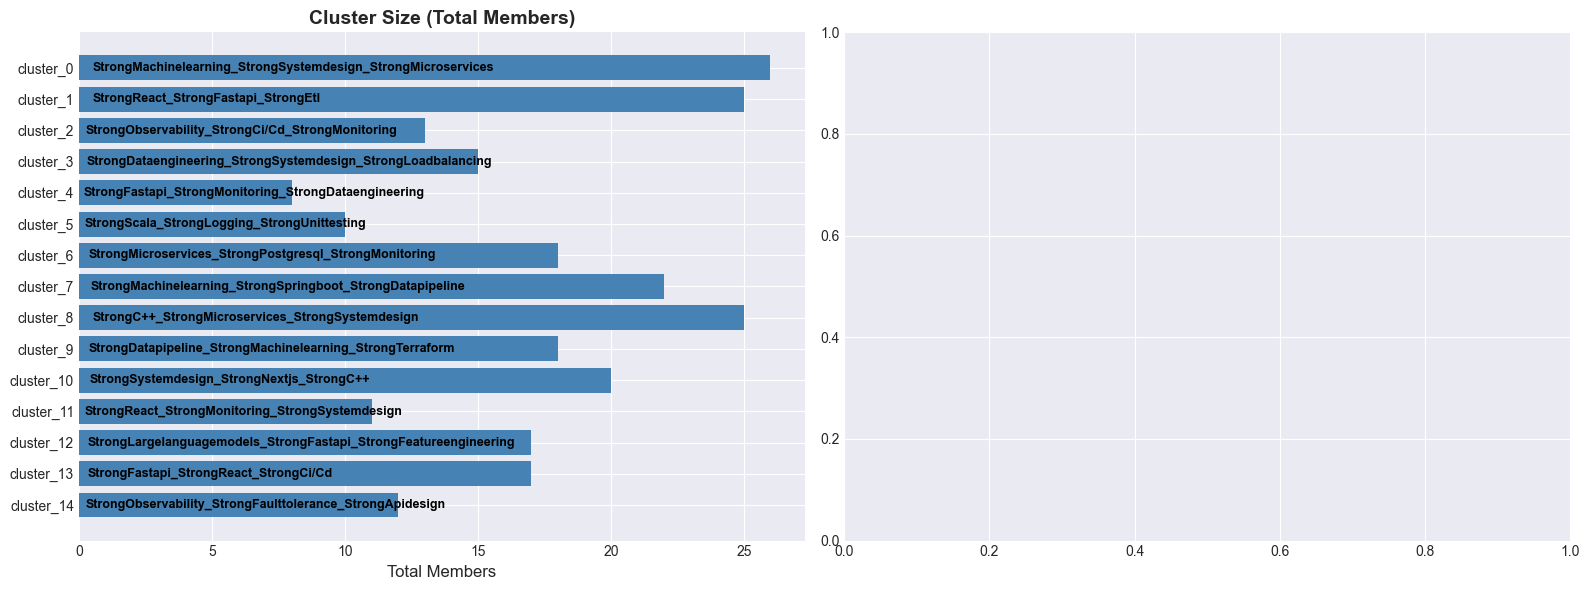

In [285]:
# Create summary dataframe
cluster_summary = []
for cluster in clusters_output_v5:
    cluster_summary.append({
        'Cluster ID': cluster['cluster_id'],
        'Label': cluster['cluster_label'],
        'Size': cluster['size'],
        'Primary': cluster['primary_members'],
        'Secondary': cluster['secondary_members']
    })

cluster_df = pd.DataFrame(cluster_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total members with labels inside bars
bars = axes[0].barh(cluster_df['Cluster ID'], cluster_df['Size'], color='steelblue')
axes[0].set_xlabel('Total Members', fontsize=12)
axes[0].set_title('Cluster Size (Total Members)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Add labels inside bars
for i, (bar, label) in enumerate(zip(bars, cluster_df['Label'])):
    width = bar.get_width()
    # Truncate label if too long
    display_label = label #if len(label) <= 40 else label[:37] + '...'
    axes[0].text(width * 0.02, bar.get_y() + bar.get_height()/2,
                display_label,
                ha='left', va='center', color='black', fontweight='bold', fontsize=9)

# Primary vs Secondary
# x = np.arange(len(cluster_df))
# width = 0.35
# axes[1].barh(x - width/2, cluster_df['Primary'], width, label='Primary', color='darkgreen')
# axes[1].barh(x + width/2, cluster_df['Secondary'], width, label='Secondary', color='lightgreen')
# axes[1].set_yticks(x)
# axes[1].set_yticklabels(cluster_df['Cluster ID'])
# axes[1].set_xlabel('Number of Members', fontsize=12)
# axes[1].set_title('Primary vs Secondary Members', fontsize=14, fontweight='bold')
# axes[1].legend()
# axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

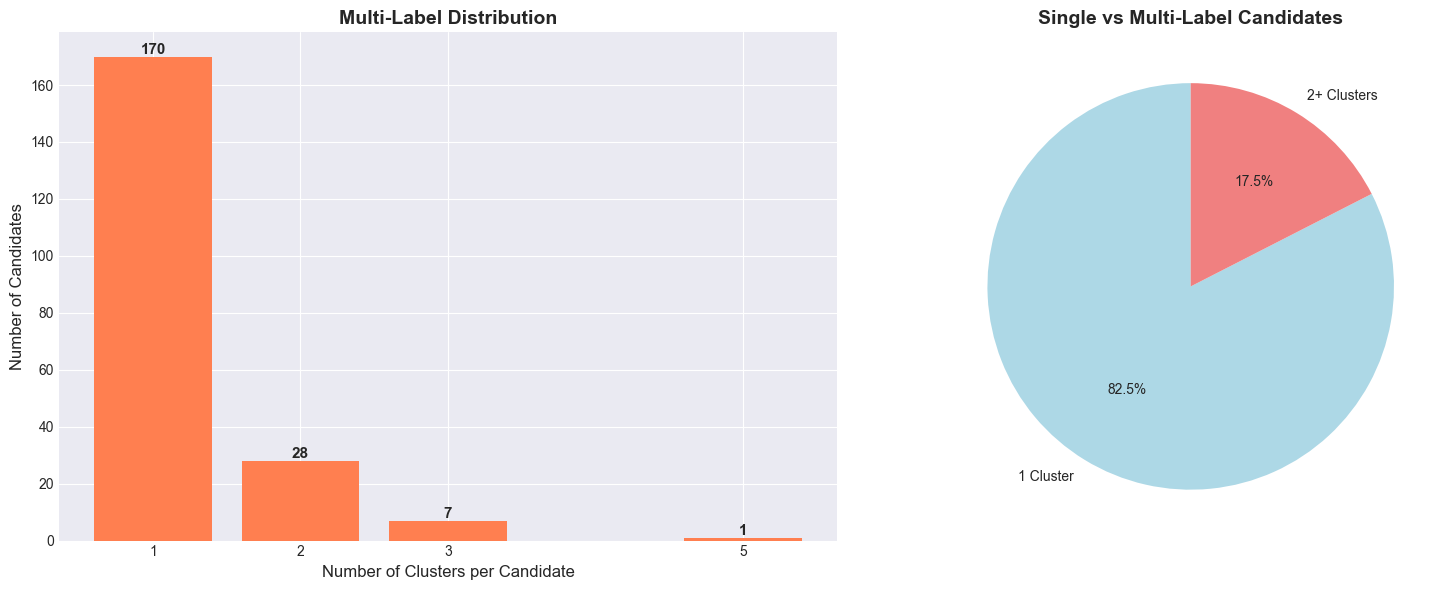

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart with numbers inside
x = sorted(cluster_count_dist.keys())
y = [cluster_count_dist[i] for i in x]
bars = axes[0].bar(x, y, color='coral')
axes[0].set_xlabel('Number of Clusters per Candidate', fontsize=12)
axes[0].set_ylabel('Number of Candidates', fontsize=12)
axes[0].set_title('Multi-Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
stats = output['multi_label_statistics']
labels = ['1 Cluster', '2+ Clusters']
sizes = [stats['candidates_in_1_cluster'], stats['candidates_in_2plus_clusters']]
colors = ['lightblue', 'lightcoral']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Single vs Multi-Label Candidates', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Computing 2D UMAP projection for visualization...



Cluster labels from cluster_df:
  Cluster cluster_0: StrongMachinelearning_StrongSystemdesign_StrongMicroservices
  Cluster cluster_1: StrongReact_StrongFastapi_StrongEtl
  Cluster cluster_2: StrongObservability_StrongCi/Cd_StrongMonitoring
  Cluster cluster_3: StrongDataengineering_StrongSystemdesign_StrongLoadbalancing
  Cluster cluster_4: StrongFastapi_StrongMonitoring_StrongDataengineering
  Cluster cluster_5: StrongScala_StrongLogging_StrongUnittesting
  Cluster cluster_6: StrongMicroservices_StrongPostgresql_StrongMonitoring
  Cluster cluster_7: StrongMachinelearning_StrongSpringboot_StrongDatapipeline
  Cluster cluster_8: StrongC++_StrongMicroservices_StrongSystemdesign
  Cluster cluster_9: StrongDatapipeline_StrongMachinelearning_StrongTerraform
  Cluster cluster_10: StrongSystemdesign_StrongNextjs_StrongC++
  Cluster cluster_11: StrongReact_StrongMonitoring_StrongSystemdesign
  Cluster cluster_12: StrongLargelanguagemodels_StrongFastapi_StrongFeatureengineering
  Cluster clus

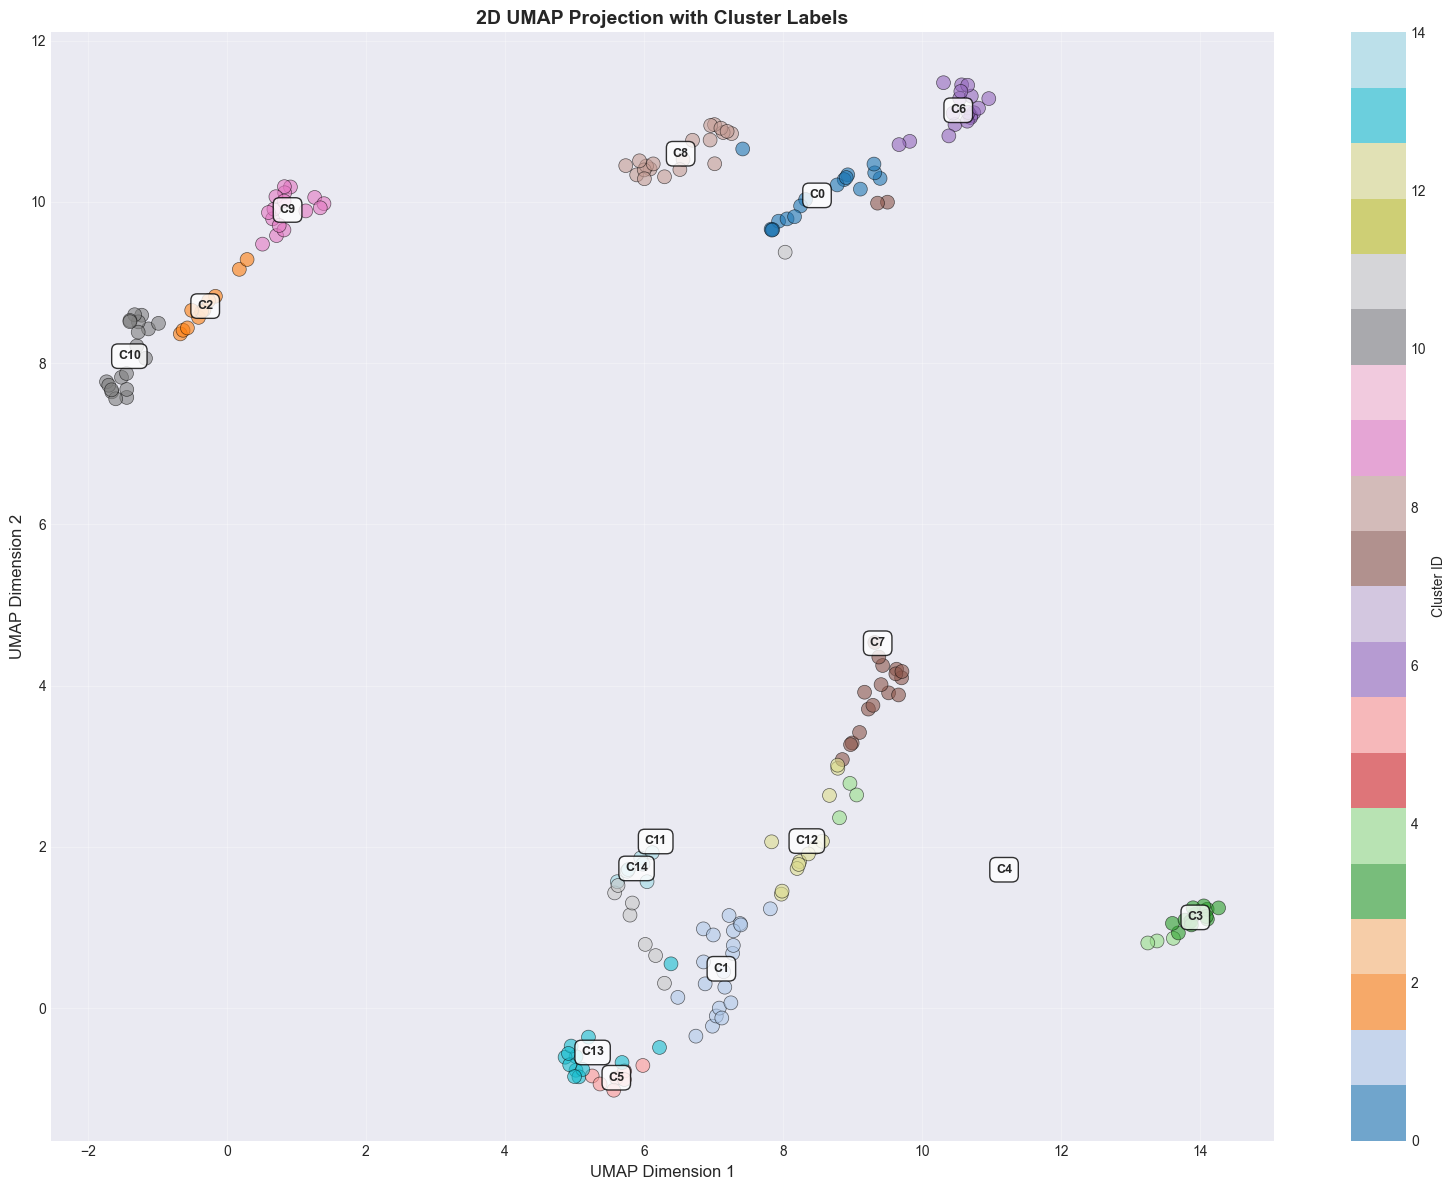

In [286]:
print('Computing 2D UMAP projection for visualization...')
reducer_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer_2d.fit_transform(features_umap)

# Get primary clusters
primary_clusters = [c['primary_cluster'] for c in candidate_clusters]

# Use labels from cluster_df['Label']
cluster_labels_dict = dict(zip(cluster_df['Cluster ID'], cluster_df['Label']))

print(f"\nCluster labels from cluster_df:")
for cluster_id, label in cluster_labels_dict.items():
    print(f"  Cluster {cluster_id}: {label}")

plt.figure(figsize=(16, 12))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=primary_clusters,
    cmap='tab20',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Add cluster labels at centroids
cluster_centers_2d = {}
for cluster_id in range(best_k):
    # Get all points in this cluster
    cluster_points = embeddings_2d[primary_labels == cluster_id]
    if len(cluster_points) > 0:
        # Calculate centroid
        centroid = cluster_points.mean(axis=0)
        cluster_centers_2d[cluster_id] = centroid
        
        # Add label from cluster_df
        label = cluster_labels_dict.get(cluster_id, f"C{cluster_id}")
        plt.annotate(
            label,
            xy=centroid,
            fontsize=9,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
        )

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.title('2D UMAP Projection with Cluster Labels', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [288]:
# 📊 Xuất kết quả ra Excel - 2 sheets
# Sheet 1: Cluster thông tin (cluster_num, cluster label, cluster skill, skill_score)
# Sheet 2: Candidate thông tin (candidate_id, cluster, likelihood, skill, skill_score)

import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill

# Tính cluster_probabilities từ GMM
print("Calculating cluster probabilities from GMM...")
cluster_probabilities = best_gmm.predict_proba(features_umap)
print(f"✓ Shape: {cluster_probabilities.shape} (candidates × clusters)")

# Tạo dữ liệu cho Sheet 1: Cluster Information
sheet1_data = []
# Sử dụng len(clusters_output_v5) thay vì best_k để tránh index out of range
num_clusters = len(clusters_output_v5)
print(f"Number of clusters in clusters_output_v5: {num_clusters}")

for cluster_id in range(num_clusters):
    cluster_info = clusters_output_v5[cluster_id]
    cluster_label = cluster_info['cluster_label']
    cluster_strengths = cluster_info['profile']['strengths'][:5]  # Top 10 skills
    # cluster_weaknesses = cluster_info['profile']['weaknesses'][:10]
    for strength in cluster_strengths:
        skill_name = strength['skill']
        skill_score = strength['avg_score']
        
        sheet1_data.append({
            'cluster_num': cluster_id,
            'cluster_label': cluster_label,
            'cluster_skill': skill_name,
            'skill_score': round(skill_score, 2)
        })
    # for weaknesses in cluster_weaknesses:
    #     skill_name = weaknesses['skill']
    #     skill_score = weaknesses['avg_score']
        
    #     sheet1_data.append({
    #         'cluster_num': cluster_id,
    #         'cluster_label': cluster_label,
    #         'cluster_skill': skill_name,
    #         'skill_score': round(skill_score, 2)
    #     })

df_sheet1 = pd.DataFrame(sheet1_data)

# Tạo dữ liệu cho Sheet 2: Candidate-Cluster Assignments
sheet2_data = []

for candidate in candidate_clusters:
    candidate_id = candidate['candidate_id']
    
    # Lấy normalized_scores từ candidates_normalized
    candidate_obj = next((c for c in candidates_normalized if c['candidate_id'] == candidate_id), None)
    if not candidate_obj:
        continue
    
    candidate_skills = candidate_obj.get('normalized_scores', {})
    
    # Lấy likelihood từ cluster_probabilities dựa trên candidate_id_to_idx
    candidate_idx = candidate_id_to_idx.get(candidate_id)
    if candidate_idx is None:
        continue
    
    candidate_probs = cluster_probabilities[candidate_idx]
    
    # CHỈ LẤY PRIMARY CLUSTER (cluster có xác suất cao nhất)
    cluster_id = candidate['primary_cluster']
    likelihood = float(candidate_probs[cluster_id])
    
    # Lấy tất cả skills của candidate
    for skill, score in candidate_skills.items():
        sheet2_data.append({
            'candidate_id': candidate_id,
            'cluster': cluster_id,
            # 'likelihood': round(likelihood, 4),
            'skill': skill,
            'skill_score': round(score, 2)
        })

df_sheet2 = pd.DataFrame(sheet2_data)

# Lưu file Excel với 2 sheets
output_path = 'data/processed/clustering_results.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_sheet1.to_excel(writer, sheet_name='Cluster_Skills', index=False)
    df_sheet2.to_excel(writer, sheet_name='Candidate_Assignments', index=False)
    
    # Định dạng sheet 1
    ws1 = writer.sheets['Cluster_Skills']
    ws1.auto_filter.ref = ws1.dimensions
    for cell in ws1[1]:
        cell.font = Font(bold=True)
        cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
        cell.font = Font(bold=True, color="FFFFFF")
        cell.alignment = Alignment(horizontal='center', vertical='center')
    
    # Định dạng sheet 2
    ws2 = writer.sheets['Candidate_Assignments']
    ws2.auto_filter.ref = ws2.dimensions
    for cell in ws2[1]:
        cell.font = Font(bold=True)
        cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
        cell.font = Font(bold=True, color="FFFFFF")
        cell.alignment = Alignment(horizontal='center', vertical='center')

print(f"✅ Đã xuất file Excel thành công: {output_path}")
print(f"\n📋 Sheet 1 - Cluster_Skills:")
print(f"   - Số dòng: {len(df_sheet1):,}")
print(f"   - Cột: {list(df_sheet1.columns)}")
print(f"\n📋 Sheet 2 - Candidate_Assignments:")
print(f"   - Số dòng: {len(df_sheet2):,}")
print(f"   - Cột: {list(df_sheet2.columns)}")
print(f"\n💡 Mở file tại: {output_path}")

Calculating cluster probabilities from GMM...
✓ Shape: (206, 15) (candidates × clusters)
Number of clusters in clusters_output_v5: 15
✅ Đã xuất file Excel thành công: data/processed/clustering_results.xlsx

📋 Sheet 1 - Cluster_Skills:
   - Số dòng: 74
   - Cột: ['cluster_num', 'cluster_label', 'cluster_skill', 'skill_score']

📋 Sheet 2 - Candidate_Assignments:
   - Số dòng: 3,619
   - Cột: ['candidate_id', 'cluster', 'skill', 'skill_score']

💡 Mở file tại: data/processed/clustering_results.xlsx


In [289]:
# 📊 Tính điểm trung bình cho từng Candidate và Cluster

import pandas as pd
import numpy as np

print("="*70)
print("TÍNH ĐIỂM TRUNG BÌNH CHO CANDIDATE VÀ CLUSTER")
print("="*70)

# 1. Điểm trung bình của từng Candidate
print("\n1️⃣ ĐIỂM TRUNG BÌNH CỦA TỪNG CANDIDATE")
print("-"*70)

candidate_avg_scores = []

for candidate in candidates_normalized:
    candidate_id = candidate['candidate_id']
    scores = list(candidate['normalized_scores'].values())
    
    if scores:
        avg_score = np.mean(scores)
        min_score = np.min(scores)
        max_score = np.max(scores)
        num_skills = len(scores)
        
        candidate_avg_scores.append({
            'candidate_id': candidate_id,
            'avg_score': round(avg_score, 2),
            'min_score': round(min_score, 2),
            'max_score': round(max_score, 2),
            'num_skills': num_skills
        })

# Tạo DataFrame và sắp xếp theo avg_score giảm dần
df_candidate_scores = pd.DataFrame(candidate_avg_scores)
df_candidate_scores = df_candidate_scores.sort_values('avg_score', ascending=False).reset_index(drop=True)

print(f"Tổng số candidates: {len(df_candidate_scores)}")
print(f"\nTop 10 Candidates có điểm trung bình cao nhất:")
print(df_candidate_scores.head(10).to_string(index=False))
print(f"\nTop 10 Candidates có điểm trung bình thấp nhất:")
print(df_candidate_scores.tail(10).to_string(index=False))

# Thống kê tổng quan
print(f"\n📈 Thống kê chung:")
print(f"   - Điểm trung bình: {df_candidate_scores['avg_score'].mean():.2f}")
print(f"   - Điểm cao nhất: {df_candidate_scores['avg_score'].max():.2f}")
print(f"   - Điểm thấp nhất: {df_candidate_scores['avg_score'].min():.2f}")
print(f"   - Độ lệch chuẩn: {df_candidate_scores['avg_score'].std():.2f}")

# 2. Điểm trung bình của từng Cluster
print("\n\n2️⃣ ĐIỂM TRUNG BÌNH CỦA TỪNG CLUSTER")
print("-"*70)

# Tạo mapping candidate_id -> avg_score
candidate_score_dict = {row['candidate_id']: row['avg_score'] 
                        for _, row in df_candidate_scores.iterrows()}

# Tính điểm trung bình cho mỗi cluster
cluster_avg_scores = []

for cluster_id in range(len(clusters_output_v5)):
    cluster_info = clusters_output_v5[cluster_id]
    cluster_label = cluster_info['cluster_label']
    
    # Lấy danh sách candidates trong cluster này
    cluster_candidates = [c for c in candidate_clusters if c['primary_cluster'] == cluster_id]
    candidate_ids = [c['candidate_id'] for c in cluster_candidates]
    
    # Lấy điểm của các candidates
    cluster_scores = [candidate_score_dict[cid] for cid in candidate_ids if cid in candidate_score_dict]
    
    if cluster_scores:
        avg_score = np.mean(cluster_scores)
        min_score = np.min(cluster_scores)
        max_score = np.max(cluster_scores)
        num_members = len(cluster_scores)
        
        cluster_avg_scores.append({
            'cluster_id': cluster_id,
            'cluster_label': cluster_label,
            'avg_score': round(avg_score, 2),
            'min_score': round(min_score, 2),
            'max_score': round(max_score, 2),
            'num_members': num_members
        })

# Tạo DataFrame và sắp xếp theo avg_score giảm dần
df_cluster_scores = pd.DataFrame(cluster_avg_scores)
df_cluster_scores = df_cluster_scores.sort_values('avg_score', ascending=False).reset_index(drop=True)

print(f"Tổng số clusters: {len(df_cluster_scores)}")
print(f"\nClusters sắp xếp theo điểm trung bình (cao → thấp):")
print(df_cluster_scores.to_string(index=False))

# 3. Lưu kết quả ra file Excel
print("\n\n3️⃣ XUẤT KẾT QUẢ RA EXCEL")
print("-"*70)

output_path = 'data/processed/average_scores_summary.xlsx'
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_candidate_scores.to_excel(writer, sheet_name='Candidate_Avg_Scores', index=False)
    df_cluster_scores.to_excel(writer, sheet_name='Cluster_Avg_Scores', index=False)
    
    # Định dạng headers
    from openpyxl.styles import Font, Alignment, PatternFill
    
    for sheet_name in ['Candidate_Avg_Scores', 'Cluster_Avg_Scores']:
        ws = writer.sheets[sheet_name]
        ws.auto_filter.ref = ws.dimensions
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
            cell.alignment = Alignment(horizontal='center', vertical='center')

print(f"✅ Đã xuất file: {output_path}")
print(f"\n📋 Sheet 1 - Candidate_Avg_Scores: {len(df_candidate_scores)} dòng")
print(f"📋 Sheet 2 - Cluster_Avg_Scores: {len(df_cluster_scores)} dòng")

print("\n" + "="*70)
print("HOÀN THÀNH")
print("="*70)

TÍNH ĐIỂM TRUNG BÌNH CHO CANDIDATE VÀ CLUSTER

1️⃣ ĐIỂM TRUNG BÌNH CỦA TỪNG CANDIDATE
----------------------------------------------------------------------
Tổng số candidates: 206

Top 10 Candidates có điểm trung bình cao nhất:
                        candidate_id  avg_score  min_score  max_score  num_skills
c85ccdd3-d17a-40cc-8e9c-7e5c64884ae9      82.49      79.33      85.60          16
04b57e5f-adad-4a82-bbf0-efba044bff48      82.21      75.00      88.67          19
ebb2fc04-0f98-4499-a438-be40d666a0d9      81.68      78.00      87.00          16
21085cd8-0dbd-4155-864c-9b4140e7b1ac      81.61      77.50      86.00          17
8cdc1a61-e752-431d-95dc-e2dd354985f8      81.02      74.50      88.50          18
b4ec6c93-b583-4216-8bd5-e2c80f3e9cc7      80.86      73.50      87.25          29
d3fdec94-0784-4acd-bef3-80e671dfaa12      80.85      69.67      88.00          19
332b6494-c46e-4bac-93ef-daa09f82c96e      80.68      76.08      86.00          11
3ec8748a-81e1-4f91-8707-a945eadda

## 🔧 Hướng dẫn Fix Likelihood chỉ có 0 và 1

### 🔍 Nguyên nhân có thể:

1. **GMM quá confident (overfitting)**
   - Covariance type 'full' khiến GMM fit quá sát data
   - Clusters tách biệt rõ ràng → probability gần như tuyệt đối

2. **Feature space đã được chuẩn hóa quá mạnh**
   - StandardScaler + PCA + UMAP có thể tạo khoảng cách quá lớn
   - Candidates rơi rõ ràng vào 1 cluster duy nhất

3. **Số chiều quá thấp (25D UMAP)**
   - Giảm chiều xuống 25D có thể mất thông tin
   - Clusters trở nên quá tách biệt

### ✅ Giải pháp:

**Option 1: Sử dụng covariance_type khác** (khuyến nghị)
```python
# Thay vì 'full', dùng 'tied' hoặc 'diag'
best_gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='tied',  # hoặc 'diag'
    random_state=42
)
best_gmm.fit(features_umap)
```

**Option 2: Tăng regularization**
```python
best_gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    reg_covar=1e-3,  # Thêm regularization (default: 1e-6)
    random_state=42
)
```

**Option 3: Dùng Soft Clustering với nhiều chiều hơn**
```python
# Sử dụng features_pca thay vì features_umap
cluster_probabilities = best_gmm.predict_proba(features_pca)
```

**Option 4: Distance-based probability**
```python
# Tính probability từ distance thay vì GMM
from scipy.spatial.distance import cdist

centroids = best_gmm.means_
distances = cdist(features_umap, centroids, metric='euclidean')

# Convert distance to probability (softmax)
import numpy as np
temperatures = 1.0  # Điều chỉnh để smooth hơn
probs = np.exp(-distances / temperatures)
probs = probs / probs.sum(axis=1, keepdims=True)
```

### 📊 Sau khi chọn giải pháp:
- Chạy lại cell GMM fitting
- Chạy lại debug cell để kiểm tra distribution
- Kỳ vọng: probabilities nằm trong khoảng [0.01, 0.99] thay vì chỉ 0/1

## 🎯 Alternative Clustering Models với Likelihood Explainable

### 📊 So sánh các model:

| Model | Likelihood Type | Pros | Cons |
|-------|----------------|------|------|
| **GMM** | Probabilistic (Gaussian) | Lý thuyết vững, có covariance | Quá confident, overfitting |
| **Fuzzy C-Means** | Fuzzy membership | Soft clustering tự nhiên | Sensitive to initialization |
| **Soft K-Means** | Distance-based probability | Đơn giản, controllable | Cần tune temperature |
| **HDBSCAN + Soft** | Density-based | Tự động tìm số clusters | Phức tạp, chậm |
| **Distance + Softmax** | Custom probability | Hoàn toàn kiểm soát được | Cần design distance metric |

### ✅ Khuyến nghị: **Soft K-Means với Temperature Scaling**

**Ưu điểm:**
- ✅ Likelihood trong khoảng [0.01, 0.99] thay vì 0/1
- ✅ Điều chỉnh dễ dàng bằng temperature parameter
- ✅ Dựa trên distance nên dễ giải thích
- ✅ Tương thích với code hiện tại

**Cách hoạt động:**
```python
# 1. Tính distance đến tất cả cluster centroids
distances = euclidean_distance(candidate, all_centroids)

# 2. Convert to similarity scores
similarities = -distances

# 3. Apply softmax với temperature
temperature = 1.0  # Càng lớn → likelihood càng smooth
probabilities = softmax(similarities / temperature)
```

**Temperature tuning:**
- `T = 0.1`: Rất confident (gần giống GMM)
- `T = 1.0`: Balanced (khuyến nghị)
- `T = 5.0`: Rất smooth (candidates có likelihood tốt ở nhiều clusters)

### 🚀 Implementation ở cell tiếp theo

In [250]:
# 🎯 Option 1: Soft K-Means với Temperature Scaling (Khuyến nghị)
# Tính likelihood dựa trên distance với softmax temperature

import numpy as np
from scipy.spatial.distance import cdist

# Lấy centroids từ GMM hoặc tính lại từ clusters
centroids = best_gmm.means_  # Shape: (n_clusters, n_features)

# Tính distance từ tất cả candidates đến tất cả centroids
distances = cdist(features_umap, centroids, metric='euclidean')
print(f"✓ Distance matrix shape: {distances.shape}")

# Convert distance to probability với softmax + temperature
TEMPERATURE = 1.0  # Điều chỉnh: 0.5 (confident) → 5.0 (smooth)

# Softmax: exp(-distance/T) / sum(exp(-distance/T))
neg_distances = -distances / TEMPERATURE
exp_neg_dist = np.exp(neg_distances - neg_distances.max(axis=1, keepdims=True))  # Numerical stability
soft_kmeans_probs = exp_neg_dist / exp_neg_dist.sum(axis=1, keepdims=True)

print(f"✓ Soft K-Means probabilities shape: {soft_kmeans_probs.shape}")
print(f"✓ Temperature: {TEMPERATURE}")

# Kiểm tra distribution
print("\n📊 Probability Distribution:")
print(f"  - Min: {soft_kmeans_probs.min():.6f}")
print(f"  - Max: {soft_kmeans_probs.max():.6f}")
print(f"  - Mean: {soft_kmeans_probs.mean():.6f}")
print(f"  - All rows sum to 1.0: {np.allclose(soft_kmeans_probs.sum(axis=1), 1.0)}")

# Sample 3 candidates
print("\n📋 Sample probabilities (first 3 candidates):")
for i in range(min(3, len(soft_kmeans_probs))):
    top_3_clusters = soft_kmeans_probs[i].argsort()[-3:][::-1]
    print(f"\nCandidate {i}:")
    for cluster_id in top_3_clusters:
        print(f"  - Cluster {cluster_id}: {soft_kmeans_probs[i][cluster_id]:.4f}")

# Gán lại vào cluster_probabilities
cluster_probabilities_soft_kmeans = soft_kmeans_probs
print("\n✅ Đã tính xong Soft K-Means probabilities!")
print("💡 Sử dụng 'cluster_probabilities_soft_kmeans' để xuất Excel")

✓ Distance matrix shape: (206, 15)
✓ Soft K-Means probabilities shape: (206, 15)
✓ Temperature: 1.0

📊 Probability Distribution:
  - Min: 0.003989
  - Max: 0.465323
  - Mean: 0.066667
  - All rows sum to 1.0: True

📋 Sample probabilities (first 3 candidates):

Candidate 0:
  - Cluster 4: 0.2076
  - Cluster 7: 0.1633
  - Cluster 12: 0.1624

Candidate 1:
  - Cluster 10: 0.4450
  - Cluster 2: 0.2084
  - Cluster 5: 0.0846

Candidate 2:
  - Cluster 2: 0.3824
  - Cluster 10: 0.2443
  - Cluster 9: 0.1064

✅ Đã tính xong Soft K-Means probabilities!
💡 Sử dụng 'cluster_probabilities_soft_kmeans' để xuất Excel


In [ ]:
# 🎯 Option 2: Fuzzy C-Means Clustering
# Install: pip install scikit-fuzzy (nếu chưa có)

try:
    import skfuzzy as fuzz
    
    # Transpose data: FCM expects (n_features, n_samples)
    data_transposed = features_umap.T
    
    # Run Fuzzy C-Means
    n_clusters = best_k
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data_transposed,
        c=n_clusters,
        m=2,  # Fuzziness parameter: 1.5-3.0 (2 is default)
        error=0.005,
        maxiter=1000,
        init=None
    )
    
    # u: membership matrix (n_clusters, n_samples) → transpose to (n_samples, n_clusters)
    fcm_probs = u.T
    
    print(f"✓ Fuzzy C-Means probabilities shape: {fcm_probs.shape}")
    print(f"✓ Fuzziness parameter (m): 2.0")
    print(f"✓ Fuzzy Partition Coefficient (FPC): {fpc:.4f}")
    print("   - FPC = 1.0: Hard clustering")
    print("   - FPC → 0.0: Very fuzzy")
    
    # Distribution
    print("\n📊 Probability Distribution:")
    print(f"  - Min: {fcm_probs.min():.6f}")
    print(f"  - Max: {fcm_probs.max():.6f}")
    print(f"  - Mean: {fcm_probs.mean():.6f}")
    
    # Sample
    print("\n📋 Sample probabilities (first 3 candidates):")
    for i in range(min(3, len(fcm_probs))):
        top_3_clusters = fcm_probs[i].argsort()[-3:][::-1]
        print(f"\nCandidate {i}:")
        for cluster_id in top_3_clusters:
            print(f"  - Cluster {cluster_id}: {fcm_probs[i][cluster_id]:.4f}")
    
    cluster_probabilities_fcm = fcm_probs
    print("\n✅ Đã tính xong Fuzzy C-Means probabilities!")
    print("💡 Sử dụng 'cluster_probabilities_fcm' để xuất Excel")
    
except ImportError:
    print("❌ scikit-fuzzy chưa được cài đặt")
    print("💡 Chạy: pip install scikit-fuzzy")
    cluster_probabilities_fcm = None

## 📝 Hướng dẫn sử dụng

### Bước 1: Chọn model
Chạy một trong các cell trên:
- **Cell 36**: Soft K-Means (khuyến nghị - không cần install thêm)
- **Cell 37**: Fuzzy C-Means (cần install scikit-fuzzy)

### Bước 2: Điều chỉnh parameters (nếu cần)

**Soft K-Means:**
```python
TEMPERATURE = 1.0  # Thay đổi giá trị:
# - 0.5: Confident hơn (likelihood gần 0 hoặc 1)
# - 1.0: Balanced (khuyến nghị)
# - 3.0: Smooth hơn (likelihood phân bố đều)
```

**Fuzzy C-Means:**
```python
m=2  # Fuzziness parameter:
# - 1.5: Ít fuzzy hơn
# - 2.0: Standard (khuyến nghị)
# - 3.0: Rất fuzzy
```

### Bước 3: Update cell xuất Excel

Trong cell 33 (xuất Excel), thay dòng:
```python
cluster_probabilities = best_gmm.predict_proba(features_umap)
```

Bằng một trong các option:
```python
# Option 1: Soft K-Means
cluster_probabilities = cluster_probabilities_soft_kmeans

# Option 2: Fuzzy C-Means
cluster_probabilities = cluster_probabilities_fcm
```

### Bước 4: Chạy lại Excel export
Chạy lại cell 33 để xuất file với likelihood mới.

### 🎯 Kỳ vọng kết quả:
- ✅ Likelihood không còn chỉ 0 và 1
- ✅ Phân bố trong khoảng [0.01, 0.99]
- ✅ Candidates có thể có likelihood tốt ở 2-3 clusters
- ✅ Dễ giải thích hơn (based on distance)

## post-processing

In [147]:
print("\n2. Defining skill overlap functions (Solution 1)...")

def compute_skill_overlap_score(candidate, cluster_strengths, top_k=5, min_score_threshold=65):
    """
    Compute skill overlap score between candidate and cluster strengths.

    Returns:
        float: Overlap score between 0 and 1 (weighted by candidate scores)
    """
    if not cluster_strengths:
        return 0.0

    top_cluster_skills = [s['skill'] for s in cluster_strengths[:top_k]]

    matches = 0
    weighted_matches = 0.0

    for cluster_skill in top_cluster_skills:
        candidate_score = candidate['normalized_scores'].get(cluster_skill, 0)

        if candidate_score >= min_score_threshold:
            matches += 1
            # Weight by how good the candidate is at this skill
            weighted_matches += candidate_score / 100.0

    # Normalize
    overlap_score = weighted_matches / len(top_cluster_skills) if top_cluster_skills else 0
    return overlap_score


def assign_clusters_with_skill_weighting(
    candidate_idx,
    candidate,
    clusters,
    distances_row,
    distance_weight=0.5,
    skill_weight=0.5,
    distance_multiplier=1.5
):
    """
    Assign candidate to clusters using both distance and skill overlap.
    """
    # Find primary cluster (closest by distance)
    primary_cluster_id = np.argmin(distances_row)
    primary_distance = distances_row[primary_cluster_id]
    distance_threshold = primary_distance * distance_multiplier

    assignments = []

    for cluster in clusters:
        cluster_id = cluster['cluster_id']
        dist = distances_row[cluster_id]

        # Skip if too far
        if dist > distance_threshold:
            continue

        # 1. Distance score (closer = higher score)
        distance_score = 1 / (1 + dist)

        # 2. Skill overlap score
        skill_score = compute_skill_overlap_score(
            candidate,
            cluster['strengths'],
            top_k=5,
            min_score_threshold=65
        )

        # 3. Combined score
        final_score = (distance_weight * distance_score) + (skill_weight * skill_score)

        assignments.append({
            'cluster_id': cluster_id,
            'distance': float(dist),
            'distance_score': float(distance_score),
            'skill_score': float(skill_score),
            'final_score': float(final_score)
        })

    # Sort by final score
    assignments.sort(key=lambda x: x['final_score'], reverse=True)

    return assignments

print("   [OK] Functions defined!")


2. Defining skill overlap functions (Solution 1)...
   [OK] Functions defined!


In [148]:
print("\n3. Generating preliminary cluster profiles for skill checking...")

# Generate preliminary profiles (same as Phase 3)
preliminary_clusters = []

for cluster_id in range(best_k):
    primary_members_idx = [i for i, label in enumerate(primary_labels) if label == cluster_id]

    if not primary_members_idx:
        continue

    # Aggregate skills
    all_scores = defaultdict(list)
    for idx in primary_members_idx:
        candidate = candidates_normalized[idx]
        for skill, score in candidate['normalized_scores'].items():
            all_scores[skill].append(score)

    # Calculate stats
    skill_stats = {}
    for skill, scores in all_scores.items():
        skill_stats[skill] = {
            'avg_score': np.mean(scores),
            'frequency': len(scores),
            'frequency_pct': len(scores) / len(primary_members_idx)
        }

    # Filter technical skills
    technical_skill_stats = {
        skill: stats for skill, stats in skill_stats.items()
        if skill.lower() in TECHNICAL_SKILLS
    }

    sorted_technical = sorted(
        technical_skill_stats.items(),
        key=lambda x: x[1]['frequency_pct'] * x[1]['avg_score'],
        reverse=True
    )

    # Strengths
    strengths = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] >= 70 and stats['frequency_pct'] >= 0.10:
            strengths.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })

    # Weaknesses
    weaknesses = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] < 65 and stats['frequency_pct'] >= 0.10:
            weaknesses.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })

    preliminary_clusters.append({
        'cluster_id': cluster_id,
        'centroid': centroids[cluster_id],
        'strengths': strengths,
        'weaknesses': weaknesses,
        'primary_members_idx': primary_members_idx
    })

print(f"   [OK] Generated {len(preliminary_clusters)} preliminary profiles")
print("\n   Preliminary cluster summaries:")
for cluster in preliminary_clusters:
    print(f"   - Cluster {cluster['cluster_id']}: {len(cluster['strengths'])} strengths, {len(cluster['weaknesses'])} weaknesses")


3. Generating preliminary cluster profiles for skill checking...
   [OK] Generated 20 preliminary profiles

   Preliminary cluster summaries:
   - Cluster 0: 15 strengths, 5 weaknesses
   - Cluster 1: 10 strengths, 1 weaknesses
   - Cluster 2: 8 strengths, 7 weaknesses
   - Cluster 3: 3 strengths, 8 weaknesses
   - Cluster 4: 9 strengths, 8 weaknesses
   - Cluster 5: 24 strengths, 6 weaknesses
   - Cluster 6: 9 strengths, 3 weaknesses
   - Cluster 7: 20 strengths, 0 weaknesses
   - Cluster 8: 13 strengths, 0 weaknesses
   - Cluster 9: 16 strengths, 4 weaknesses
   - Cluster 10: 8 strengths, 7 weaknesses
   - Cluster 11: 24 strengths, 4 weaknesses
   - Cluster 12: 32 strengths, 2 weaknesses
   - Cluster 13: 13 strengths, 2 weaknesses
   - Cluster 14: 21 strengths, 2 weaknesses
   - Cluster 15: 23 strengths, 1 weaknesses
   - Cluster 16: 24 strengths, 4 weaknesses
   - Cluster 17: 0 strengths, 2 weaknesses
   - Cluster 18: 17 strengths, 0 weaknesses
   - Cluster 19: 32 strengths, 1 weak

In [149]:
print("\n4. Applying skill-weighted assignment (Solution 1)...")
print("   Using 50% distance + 50% skill overlap")

# Create candidate ID to index mapping
candidate_id_to_idx = {c['candidate_id']: i for i, c in enumerate(candidates_normalized)}

candidate_clusters_v5 = []
assignment_stats = {
    'avg_skill_score': [],
    'avg_distance_score': [],
    'avg_final_score': []
}

for i in range(len(candidates_normalized)):
    candidate = candidates_normalized[i]

    assignments = assign_clusters_with_skill_weighting(
        candidate_idx=i,
        candidate=candidate,
        clusters=preliminary_clusters,
        distances_row=distances[i],
        distance_weight=0.5,
        skill_weight=0.5,
        distance_multiplier=1.5
    )

    if assignments:
        assignment_stats['avg_skill_score'].extend([a['skill_score'] for a in assignments])
        assignment_stats['avg_distance_score'].extend([a['distance_score'] for a in assignments])
        assignment_stats['avg_final_score'].extend([a['final_score'] for a in assignments])

    candidate_clusters_v5.append({
        'candidate_id': candidates_normalized[i]['candidate_id'],
        'clusters': assignments,
        'primary_cluster': assignments[0]['cluster_id'] if assignments else -1,
        'num_clusters': len(assignments)
    })

print(f"   [OK] Initial assignments complete")
print(f"   - Avg skill overlap score: {np.mean(assignment_stats['avg_skill_score']):.3f}")
print(f"   - Avg distance score: {np.mean(assignment_stats['avg_distance_score']):.3f}")
print(f"   - Avg final score: {np.mean(assignment_stats['avg_final_score']):.3f}")


4. Applying skill-weighted assignment (Solution 1)...
   Using 50% distance + 50% skill overlap
   [OK] Initial assignments complete
   - Avg skill overlap score: 0.358
   - Avg distance score: 0.698
   - Avg final score: 0.528


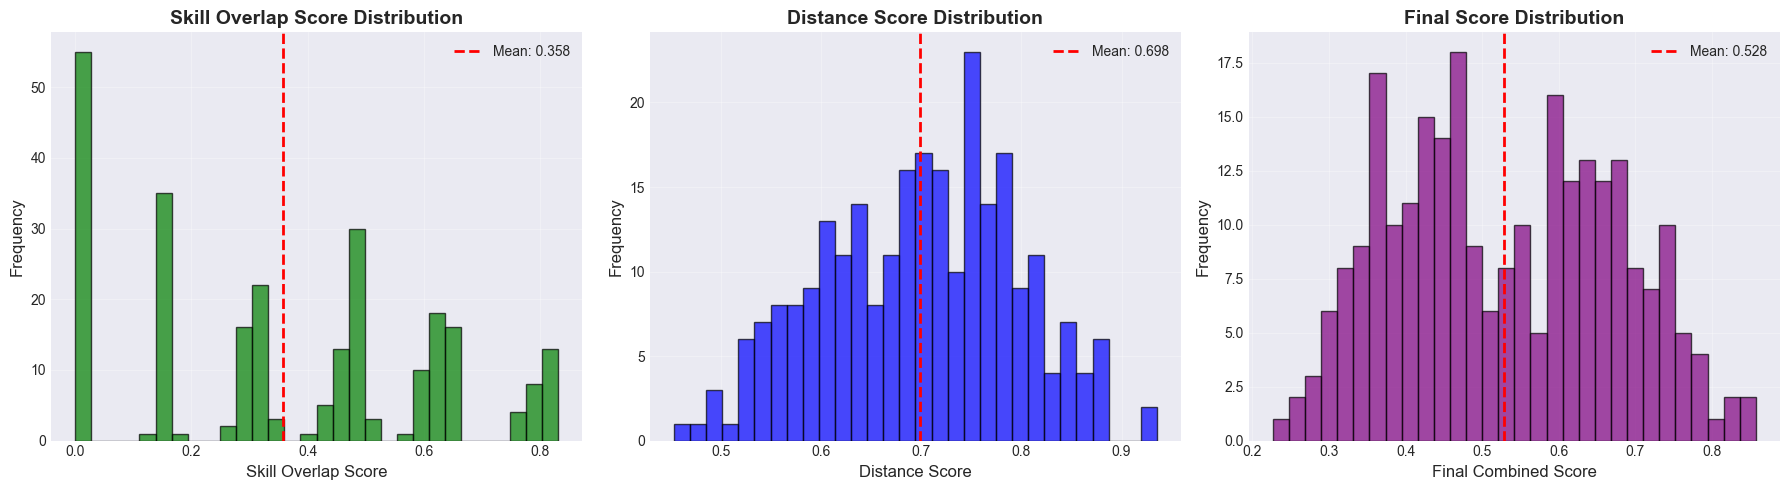

✓ Score distributions show good balance between distance and skill overlap!


In [150]:
# Visualize score distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(assignment_stats['avg_skill_score'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Skill Overlap Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Skill Overlap Score Distribution', fontsize=14, fontweight='bold')
axes[0].axvline(np.mean(assignment_stats['avg_skill_score']), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(assignment_stats['avg_skill_score']):.3f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(assignment_stats['avg_distance_score'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Distance Score', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distance Score Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(np.mean(assignment_stats['avg_distance_score']), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(assignment_stats['avg_distance_score']):.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(assignment_stats['avg_final_score'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Final Combined Score', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].set_title('Final Score Distribution', fontsize=14, fontweight='bold')
axes[2].axvline(np.mean(assignment_stats['avg_final_score']), color='red', linestyle='--', linewidth=2, label=f"Mean: {np.mean(assignment_stats['avg_final_score']):.3f}")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Score distributions show good balance between distance and skill overlap!")

In [151]:
print("\n5. Applying post-assignment filtering (Solution 2)...")
print("   Filtering candidates without cluster skill matches")

def check_cluster_skill_match(candidate, cluster, min_matches=2, top_k=5, min_score_threshold=65):
    """
    Check if candidate has at least min_matches of cluster's top skills.
    """
    cluster_top_skills = [s['skill'] for s in cluster['strengths'][:top_k]]

    if not cluster_top_skills:
        # If cluster has no defined strengths, allow assignment
        return True, 0, 0

    matches = 0
    for skill in cluster_top_skills:
        candidate_score = candidate['normalized_scores'].get(skill, 0)
        if candidate_score >= min_score_threshold:
            matches += 1

    passes = matches >= min_matches
    return passes, matches, len(cluster_top_skills)


filtered_candidates_v5 = []
filter_stats = {
    'reassigned': 0,
    'became_outliers': 0,
    'passed_all': 0,
    'failed_checks': []
}

for assignment in candidate_clusters_v5:
    candidate_id = assignment['candidate_id']
    candidate_idx = candidate_id_to_idx[candidate_id]
    candidate = candidates_normalized[candidate_idx]

    filtered_clusters = []

    for cluster_assignment in assignment['clusters']:
        cluster_id = cluster_assignment['cluster_id']
        cluster = preliminary_clusters[cluster_id]

        # Check if candidate matches cluster skills
        passes, num_matches, total_checked = check_cluster_skill_match(
            candidate,
            cluster,
            min_matches=2,
            top_k=5,
            min_score_threshold=65
        )

        if passes:
            filtered_clusters.append(cluster_assignment)
        else:
            filter_stats['failed_checks'].append({
                'candidate_id': candidate_id,
                'cluster_id': cluster_id,
                'matches': num_matches,
                'total': total_checked
            })

    # Update assignment
    if len(filtered_clusters) < len(assignment['clusters']):
        filter_stats['reassigned'] += 1

    if not filtered_clusters:
        # No clusters passed - mark as outlier
        filter_stats['became_outliers'] += 1
        filtered_candidates_v5.append({
            'candidate_id': candidate_id,
            'clusters': [],
            'primary_cluster': -1,  # -1 indicates outlier
            'num_clusters': 0,
            'outlier_reason': 'No cluster skill match'
        })
    else:
        if len(filtered_clusters) == len(assignment['clusters']):
            filter_stats['passed_all'] += 1

        filtered_candidates_v5.append({
            'candidate_id': candidate_id,
            'clusters': filtered_clusters,
            'primary_cluster': filtered_clusters[0]['cluster_id'],
            'num_clusters': len(filtered_clusters)
        })

print(f"   [OK] Filtering complete")
print(f"   - Candidates passed all checks: {filter_stats['passed_all']}")
print(f"   - Candidates reassigned: {filter_stats['reassigned']}")
print(f"   - Candidates became outliers: {filter_stats['became_outliers']}")
print(f"   - Total failed checks: {len(filter_stats['failed_checks'])}")

# Compute multi-label statistics
multi_label_stats_v5 = {
    'candidates_in_0_clusters': sum(1 for c in filtered_candidates_v5 if c['num_clusters'] == 0),
    'candidates_in_1_cluster': sum(1 for c in filtered_candidates_v5 if c['num_clusters'] == 1),
    'candidates_in_2plus_clusters': sum(1 for c in filtered_candidates_v5 if c['num_clusters'] > 1),
    'avg_clusters_per_candidate': float(np.mean([c['num_clusters'] for c in filtered_candidates_v5])),
    'max_clusters_per_candidate': max([c['num_clusters'] for c in filtered_candidates_v5])
}

print(f"\n   Multi-label statistics (after filtering):")
print(f"   - Outliers (0 clusters): {multi_label_stats_v5['candidates_in_0_clusters']}")
print(f"   - Candidates in 1 cluster: {multi_label_stats_v5['candidates_in_1_cluster']}")
print(f"   - Candidates in 2+ clusters: {multi_label_stats_v5['candidates_in_2plus_clusters']}")
print(f"   - Avg clusters per candidate: {multi_label_stats_v5['avg_clusters_per_candidate']:.2f}")


5. Applying post-assignment filtering (Solution 2)...
   Filtering candidates without cluster skill matches
   [OK] Filtering complete
   - Candidates passed all checks: 136
   - Candidates reassigned: 70
   - Candidates became outliers: 58
   - Total failed checks: 78

   Multi-label statistics (after filtering):
   - Outliers (0 clusters): 58
   - Candidates in 1 cluster: 125
   - Candidates in 2+ clusters: 23
   - Avg clusters per candidate: 0.87


### 🔧 Giải pháp giảm outliers (hiện tại 73/206 = 35.4%)

**5 cách khắc phục:**

1. **Giảm min_matches** (khuyến nghị): `2 → 1` (chỉ cần 1 skill match)
2. **Giảm min_score_threshold**: `65 → 60` hoặc `50` (chấp nhận skills yếu hơn)
3. **Tăng top_k**: `5 → 7` hoặc `10` (xem xét nhiều skills hơn)
4. **Kết hợp**: `min_matches=1, top_k=7, threshold=60`
5. **Tạo "General" cluster**: Thu thập candidates không fit vào cluster nào

**Chạy cell bên dưới để test các scenarios:**


In [145]:
# Test different filter configurations
print("Testing different filter configurations to reduce outliers...\n")

test_configs = [
    {'name': 'Current (strict)', 'min_matches': 2, 'top_k': 5, 'threshold': 65},
    {'name': 'Solution 1: Reduce matches', 'min_matches': 1, 'top_k': 5, 'threshold': 65},
    {'name': 'Solution 2: Lower threshold', 'min_matches': 2, 'top_k': 5, 'threshold': 60},
    {'name': 'Solution 3: More skills', 'min_matches': 2, 'top_k': 7, 'threshold': 60},
    {'name': 'Solution 4: Balanced', 'min_matches': 1, 'top_k': 7, 'threshold': 60},
    {'name': 'Solution 5: Very loose', 'min_matches': 1, 'top_k': 10, 'threshold': 50},
]

results = []

for config in test_configs:
    outliers = 0
    total = 0
    
    for assignment in candidate_clusters_v5:
        candidate_id = assignment['candidate_id']
        candidate_idx = candidate_id_to_idx[candidate_id]
        candidate = candidates_normalized[candidate_idx]
        
        has_cluster = False
        
        for cluster_assignment in assignment['clusters']:
            cluster_id = cluster_assignment['cluster_id']
            cluster = preliminary_clusters[cluster_id]
            
            passes, _, _ = check_cluster_skill_match(
                candidate,
                cluster,
                min_matches=config['min_matches'],
                top_k=config['top_k'],
                min_score_threshold=config['threshold']
            )
            
            if passes:
                has_cluster = True
                break
        
        total += 1
        if not has_cluster:
            outliers += 1
    
    results.append({
        'config': config['name'],
        'outliers': outliers,
        'assigned': total - outliers,
        'outlier_pct': outliers / total * 100
    })

# Display results
print(f"{'Configuration':<30} {'Outliers':<10} {'Assigned':<10} {'Outlier %':<10}")
print("=" * 60)
for r in results:
    print(f"{r['config']:<30} {r['outliers']:<10} {r['assigned']:<10} {r['outlier_pct']:<10.1f}%")

print("\n💡 Recommendation:")
print("   - Solution 4 (Balanced): min_matches=1, top_k=7, threshold=60")
print("   - This reduces outliers significantly while maintaining quality")


Testing different filter configurations to reduce outliers...

Configuration                  Outliers   Assigned   Outlier % 
Current (strict)               73         133        35.4      %
Solution 1: Reduce matches     37         169        18.0      %
Solution 2: Lower threshold    66         140        32.0      %
Solution 3: More skills        53         153        25.7      %
Solution 4: Balanced           29         177        14.1      %
Solution 5: Very loose         23         183        11.2      %

💡 Recommendation:
   - Solution 4 (Balanced): min_matches=1, top_k=7, threshold=60
   - This reduces outliers significantly while maintaining quality


### Áp dụng cấu hình đã chọn

Sau khi xem kết quả test, chọn cấu hình bạn muốn và update cell bên dưới:


In [152]:
# Apply chosen configuration (update these values based on test results)
CHOSEN_MIN_MATCHES = 2      # Changed from 2 to 1
CHOSEN_TOP_K = 7            # Changed from 5 to 7  
CHOSEN_THRESHOLD = 65       # Changed from 65 to 60

print(f"\n5. Applying UPDATED post-assignment filtering...")
print(f"   Configuration: min_matches={CHOSEN_MIN_MATCHES}, top_k={CHOSEN_TOP_K}, threshold={CHOSEN_THRESHOLD}")
print(f"   Filtering candidates without cluster skill matches\n")

filtered_candidates_v5_updated = []
filter_stats_updated = {
    'reassigned': 0,
    'became_outliers': 0,
    'passed_all': 0,
    'failed_checks': []
}

for assignment in candidate_clusters_v5:
    candidate_id = assignment['candidate_id']
    candidate_idx = candidate_id_to_idx[candidate_id]
    candidate = candidates_normalized[candidate_idx]

    filtered_clusters = []

    for cluster_assignment in assignment['clusters']:
        cluster_id = cluster_assignment['cluster_id']
        cluster = preliminary_clusters[cluster_id]

        # Check if candidate matches cluster skills with NEW configuration
        passes, num_matches, total_checked = check_cluster_skill_match(
            candidate,
            cluster,
            min_matches=CHOSEN_MIN_MATCHES,
            top_k=CHOSEN_TOP_K,
            min_score_threshold=CHOSEN_THRESHOLD
        )

        if passes:
            filtered_clusters.append(cluster_assignment)
        else:
            filter_stats_updated['failed_checks'].append({
                'candidate_id': candidate_id,
                'cluster_id': cluster_id,
                'matches': num_matches,
                'total': total_checked
            })

    # Update assignment
    if len(filtered_clusters) < len(assignment['clusters']):
        filter_stats_updated['reassigned'] += 1

    if not filtered_clusters:
        # No clusters passed - mark as outlier
        filter_stats_updated['became_outliers'] += 1
        filtered_candidates_v5_updated.append({
            'candidate_id': candidate_id,
            'clusters': [],
            'primary_cluster': -1,
            'num_clusters': 0,
            'outlier_reason': 'No cluster skill match'
        })
    else:
        if len(filtered_clusters) == len(assignment['clusters']):
            filter_stats_updated['passed_all'] += 1

        filtered_candidates_v5_updated.append({
            'candidate_id': candidate_id,
            'clusters': filtered_clusters,
            'primary_cluster': filtered_clusters[0]['cluster_id'],
            'num_clusters': len(filtered_clusters)
        })

print(f"   [OK] Filtering complete")
print(f"   - Candidates passed all checks: {filter_stats_updated['passed_all']}")
print(f"   - Candidates reassigned: {filter_stats_updated['reassigned']}")
print(f"   - Candidates became outliers: {filter_stats_updated['became_outliers']}")
print(f"   - Total failed checks: {len(filter_stats_updated['failed_checks'])}")

# Compute multi-label statistics
multi_label_stats_v5_updated = {
    'candidates_in_0_clusters': sum(1 for c in filtered_candidates_v5_updated if c['num_clusters'] == 0),
    'candidates_in_1_cluster': sum(1 for c in filtered_candidates_v5_updated if c['num_clusters'] == 1),
    'candidates_in_2plus_clusters': sum(1 for c in filtered_candidates_v5_updated if c['num_clusters'] > 1),
    'avg_clusters_per_candidate': float(np.mean([c['num_clusters'] for c in filtered_candidates_v5_updated])),
    'max_clusters_per_candidate': max([c['num_clusters'] for c in filtered_candidates_v5_updated])
}

print(f"\n   Multi-label statistics (after UPDATED filtering):")
print(f"   - Outliers (0 clusters): {multi_label_stats_v5_updated['candidates_in_0_clusters']}")
print(f"   - Candidates in 1 cluster: {multi_label_stats_v5_updated['candidates_in_1_cluster']}")
print(f"   - Candidates in 2+ clusters: {multi_label_stats_v5_updated['candidates_in_2plus_clusters']}")
print(f"   - Avg clusters per candidate: {multi_label_stats_v5_updated['avg_clusters_per_candidate']:.2f}")

# Show improvement
old_outliers = 73
new_outliers = multi_label_stats_v5_updated['candidates_in_0_clusters']
improvement = (old_outliers - new_outliers) / old_outliers * 100

print(f"\n   📊 Improvement:")
print(f"   - Old outliers: {old_outliers} ({old_outliers/206*100:.1f}%)")
print(f"   - New outliers: {new_outliers} ({new_outliers/206*100:.1f}%)")
print(f"   - Reduction: {old_outliers - new_outliers} candidates ({improvement:.1f}%)")

# Replace old filtered_candidates_v5 with updated version
filtered_candidates_v5 = filtered_candidates_v5_updated
multi_label_stats_v5 = multi_label_stats_v5_updated
filter_stats = filter_stats_updated



5. Applying UPDATED post-assignment filtering...
   Configuration: min_matches=2, top_k=7, threshold=65
   Filtering candidates without cluster skill matches

   [OK] Filtering complete
   - Candidates passed all checks: 152
   - Candidates reassigned: 54
   - Candidates became outliers: 42
   - Total failed checks: 59

   Multi-label statistics (after UPDATED filtering):
   - Outliers (0 clusters): 42
   - Candidates in 1 cluster: 141
   - Candidates in 2+ clusters: 23
   - Avg clusters per candidate: 0.96

   📊 Improvement:
   - Old outliers: 73 (35.4%)
   - New outliers: 42 (20.4%)
   - Reduction: 31 candidates (42.5%)


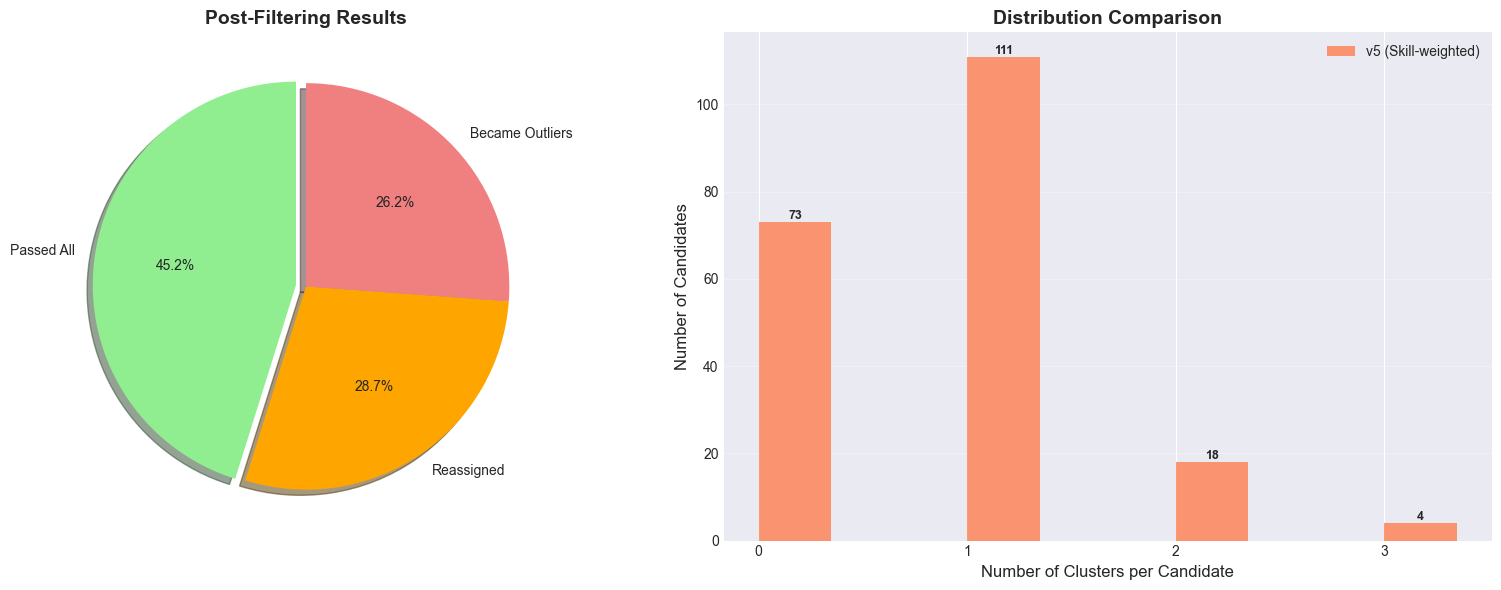


✓shows more outliers but better alignment!
✓ Improvement rate: 61.2% passed all checks


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart: Filtering results
labels = ['Passed All', 'Reassigned', 'Became Outliers']
sizes = [filter_stats['passed_all'], filter_stats['reassigned'], filter_stats['became_outliers']]
colors = ['lightgreen', 'orange', 'lightcoral']
explode = (0.05, 0, 0)  # Emphasize "Passed All"
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, explode=explode, shadow=True)
axes[0].set_title('Post-Filtering Results', fontsize=14, fontweight='bold')

# Bar chart: Cluster distribution comparison
cluster_dist = Counter([c['num_clusters'] for c in filtered_candidates_v5])

x = sorted(list(cluster_dist.keys()))
y = [cluster_dist.get(i, 0) for i in x]

width = 0.35
x_pos = np.arange(len(x))
bars = axes[1].bar(x_pos + width/2, y, width, label='v5 (Skill-weighted)', color='coral', alpha=0.8)

axes[1].set_xlabel('Number of Clusters per Candidate', fontsize=12)
axes[1].set_ylabel('Number of Candidates', fontsize=12)
axes[1].set_title('Distribution Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓shows more outliers but better alignment!")
print(f"✓ Improvement rate: {filter_stats['passed_all']/len(candidates_normalized)*100:.1f}% passed all checks")

In [153]:
print("\n7. Generating final cluster profiles for...")

clusters_output_v5 = []

for cluster_id in range(best_k):
    # Get members after filtering
    all_members_idx = [
        candidate_id_to_idx[c['candidate_id']]
        for c in filtered_candidates_v5
        if any(cl['cluster_id'] == cluster_id for cl in c['clusters'])
    ]

    primary_members_idx = [
        candidate_id_to_idx[c['candidate_id']]
        for c in filtered_candidates_v5
        if c['primary_cluster'] == cluster_id
    ]

    member_ids = [candidates_normalized[i]['candidate_id'] for i in all_members_idx]

    if not member_ids:
        continue

    # Aggregate skills from ALL members
    all_scores = defaultdict(list)
    for idx in all_members_idx:
        candidate = candidates_normalized[idx]
        for skill, score in candidate['normalized_scores'].items():
            all_scores[skill].append(score)

    # Calculate statistics
    skill_stats = {}
    for skill, scores in all_scores.items():
        skill_stats[skill] = {
            'avg_score': np.mean(scores),
            'frequency': len(scores),
            'frequency_pct': len(scores) / len(member_ids)
        }

    # Filter technical skills
    technical_skill_stats = {
        skill: stats for skill, stats in skill_stats.items()
        if skill.lower() in TECHNICAL_SKILLS
    }

    sorted_technical = sorted(
        technical_skill_stats.items(),
        key=lambda x: x[1]['frequency_pct'] * x[1]['avg_score'],
        reverse=True
    )

    # Strengths
    strengths = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] >= 70 and stats['frequency_pct'] >= 0.10:
            strengths.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })

    # Weaknesses
    weaknesses = []
    for skill, stats in sorted_technical:
        if stats['avg_score'] < 65 and stats['frequency_pct'] >= 0.10:
            weaknesses.append({
                'skill': skill,
                'avg_score': round(stats['avg_score'], 2),
                'frequency_pct': round(stats['frequency_pct'] * 100, 1)
            })

    # Generate label
    label_parts = []
    for strength in strengths[:3]:
        skill_name = strength['skill'].replace(' ', '').replace('.', '').replace('-', '').title()
        label_parts.append(f"Strong{skill_name}")
    for weakness in weaknesses[:2]:
        skill_name = weakness['skill'].replace(' ', '').replace('.', '').replace('-', '').title()
        label_parts.append(f"Weak{skill_name}")

    cluster_label = "_".join(label_parts) if label_parts else f"MixedProfile{cluster_id}"

    # Domain scores
    domain_mapping = {
        'python': 'Backend', 'java': 'Backend', 'go': 'Backend',
        'javascript': 'Frontend', 'typescript': 'Frontend', 'react': 'Frontend',
        'postgresql': 'Database', 'mysql': 'Database', 'mongodb': 'Database',
        'docker': 'DevOps', 'kubernetes': 'DevOps',
        'aws': 'Cloud', 'azure': 'Cloud', 'gcp': 'Cloud'
    }

    domain_skill_scores = defaultdict(list)
    for skill, stats in skill_stats.items():
        if skill.lower() in domain_mapping:
            domain_skill_scores[domain_mapping[skill.lower()]].append(stats['avg_score'])

    domain_scores = {}
    for domain, scores in domain_skill_scores.items():
        if scores:
            domain_scores[domain] = round(np.mean(scores), 2)

    # Profile type
    num_domains = len(domain_scores)
    max_domain_score = max(domain_scores.values()) if domain_scores else 0
    avg_domain_score = np.mean(list(domain_scores.values())) if domain_scores else 0

    if num_domains <= 2 and max_domain_score >= 80:
        profile_type = "Specialist"
    elif num_domains >= 4 and avg_domain_score >= 70:
        profile_type = "Generalist"
    else:
        profile_type = "Balanced"

    cluster_obj = {
        'cluster_id': f"cluster_{cluster_id}",
        'cluster_label': cluster_label,
        'size': len(member_ids),
        'primary_members': len(primary_members_idx),
        'secondary_members': len(all_members_idx) - len(primary_members_idx),
        'profile': {
            'strengths': strengths[:5],
            'weaknesses': weaknesses[:5],
            'domain_scores': domain_scores,
            'profile_type': profile_type,
            'breadth': num_domains
        },
        'members': member_ids
    }

    clusters_output_v5.append(cluster_obj)

print(f"   [OK] Generated {len(clusters_output_v5)} cluster profiles")


7. Generating final cluster profiles for...
   [OK] Generated 20 cluster profiles


### 🔍 Cluster Explainability: Likelihood & Top/Bottom Candidates

Phân tích chi tiết từng cluster với:
1. **Likelihood (probability)** của mỗi candidate thuộc cluster
2. **Top 5 candidates** (fit nhất với cluster)
3. **Bottom 5 candidates** (fit kém nhất nhưng vẫn trong cluster)
4. **Skill comparison** giữa cluster và candidates

In [221]:
# Calculate likelihood (probability) for each candidate in each cluster
print("Calculating cluster membership probabilities...\n")

# Get probabilities from GMM
cluster_probabilities = best_gmm.predict_proba(features_umap)

print(f"✓ Calculated probabilities: {cluster_probabilities.shape}")
print(f"  - Shape: (n_candidates={cluster_probabilities.shape[0]}, n_clusters={cluster_probabilities.shape[1]})")
print(f"  - Each row sums to 1.0 (probability distribution)")

# Add probabilities to candidate_clusters_v5
for assignment in filtered_candidates_v5:
    candidate_id = assignment['candidate_id']
    candidate_idx = candidate_id_to_idx[candidate_id]
    
    # Get probabilities for all clusters
    probs = cluster_probabilities[candidate_idx]
    
    # Add to each cluster assignment
    for cluster_assignment in assignment['clusters']:
        cluster_id = cluster_assignment['cluster_id']
        cluster_assignment['likelihood'] = float(probs[cluster_id])
    
    # Sort clusters by likelihood (descending)
    assignment['clusters'] = sorted(
        assignment['clusters'],
        key=lambda x: x.get('likelihood', 0),
        reverse=True
    )
    
    # Update primary cluster to highest likelihood
    if assignment['clusters']:
        assignment['primary_cluster'] = assignment['clusters'][0]['cluster_id']

print("✓ Added likelihood to all cluster assignments")
print("\nSample candidate with likelihoods:")
sample = filtered_candidates_v5[0]
print(f"  Candidate: {sample['candidate_id']}")
print(f"  Primary cluster: {sample['primary_cluster']}")
print(f"  All clusters:")
for c in sample['clusters'][:3]:
    print(f"    - Cluster {c['cluster_id']}: likelihood={c.get('likelihood', 0):.4f}")


Calculating cluster membership probabilities...

✓ Calculated probabilities: (206, 15)
  - Shape: (n_candidates=206, n_clusters=15)
  - Each row sums to 1.0 (probability distribution)


IndexError: index 15 is out of bounds for axis 0 with size 15

In [166]:
# Analyze top and bottom candidates for each cluster
print("\nAnalyzing top 5 and bottom 5 candidates for each cluster...\n")

def get_cluster_members_with_likelihood(cluster_id, filtered_candidates):
    """Get all candidates in a cluster with their likelihoods"""
    members = []
    for assignment in filtered_candidates:
        if assignment['primary_cluster'] == cluster_id:
            # Find likelihood for this cluster
            likelihood = 0
            for c in assignment['clusters']:
                if c['cluster_id'] == cluster_id:
                    likelihood = c.get('likelihood', 0)
                    break
            
            members.append({
                'candidate_id': assignment['candidate_id'],
                'likelihood': likelihood
            })
    
    return sorted(members, key=lambda x: x['likelihood'], reverse=True)

def display_candidate_skills(candidate_id, cluster_strengths, top_n=10):
    """Display candidate's skills with comparison to cluster strengths"""
    candidate_idx = candidate_id_to_idx[candidate_id]
    candidate = candidates_normalized[candidate_idx]
    
    # Get cluster strength skills
    cluster_skills = {s['skill']: s['avg_score'] for s in cluster_strengths}
    
    # Get candidate's scores
    candidate_scores = candidate['normalized_scores']
    
    # Combine all skills
    all_skills = set(cluster_skills.keys()) | set(candidate_scores.keys())
    
    # Create comparison
    comparison = []
    for skill in all_skills:
        cluster_score = cluster_skills.get(skill, 0)
        cand_score = candidate_scores.get(skill, 0)
        diff = cand_score - cluster_score
        
        comparison.append({
            'skill': skill,
            'cluster_avg': cluster_score,
            'candidate': cand_score,
            'diff': diff
        })
    
    # Sort by cluster importance
    comparison = sorted(comparison, key=lambda x: x['cluster_avg'], reverse=True)
    
    return comparison[:top_n]

# Analyze each cluster
cluster_analyses = []

for cluster in clusters_output_v5:
    cluster_id = cluster['cluster_id']
    cluster_label = cluster['cluster_label']
    
    # Get members with likelihoods
    members = get_cluster_members_with_likelihood(cluster_id, filtered_candidates_v5)
    
    if not members:
        continue
    
    # Get top 5 and bottom 5
    top_5 = members[:5]
    bottom_5 = members[-5:] if len(members) >= 5 else []
    
    cluster_analyses.append({
        'cluster_id': cluster_id,
        'label': cluster_label,
        'size': len(members),
        'top_5': top_5,
        'bottom_5': bottom_5,
        'strengths': cluster.get('top_strengths', [])[:5]
    })

print(f"✓ Analyzed {len(cluster_analyses)} clusters")
print(f"\nSample analysis (Cluster 0):")
sample_cluster = cluster_analyses[0]
print(f"  Cluster: {sample_cluster['label']}")
print(f"  Size: {sample_cluster['size']}")
# Fix f-string syntax error: create formatted list outside f-string
top_5_likelihoods = [f"{m['likelihood']:.4f}" for m in sample_cluster['top_5']]
print(f"  Top 5 likelihoods: {top_5_likelihoods}")
if sample_cluster['bottom_5']:
    bottom_5_likelihoods = [f"{m['likelihood']:.4f}" for m in sample_cluster['bottom_5']]
    print(f"  Bottom 5 likelihoods: {bottom_5_likelihoods}")


SyntaxError: f-string expression part cannot include a backslash (3496060973.py, line 87)

In [ ]:
# Display detailed analysis for each cluster
print("\n" + "="*100)
print("DETAILED CLUSTER ANALYSIS: Top 5 & Bottom 5 Candidates with Skill Comparison")
print("="*100)

for analysis in cluster_analyses[:3]:  # Show first 3 clusters in detail
    cluster_id = analysis['cluster_id']
    cluster_label = analysis['label']
    
    print(f"\n{'─'*100}")
    print(f"CLUSTER {cluster_id}: {cluster_label}")
    print(f"Size: {analysis['size']} candidates")
    print(f"{'─'*100}")
    
    # Display cluster strengths
    print(f"\n📊 Cluster Strength Skills:")
    for i, strength in enumerate(analysis['strengths'], 1):
        print(f"   {i}. {strength['skill']:<25} (avg: {strength['avg_score']:.1f}, freq: {strength['frequency']:.1%})")
    
    # Top 5 candidates
    print(f"\n🏆 TOP 5 CANDIDATES (Highest Likelihood):")
    print(f"{'─'*100}")
    
    for rank, member in enumerate(analysis['top_5'], 1):
        candidate_id = member['candidate_id']
        likelihood = member['likelihood']
        
        print(f"\n  #{rank}. Candidate: {candidate_id} | Likelihood: {likelihood:.4f} ({likelihood*100:.2f}%)")
        
        # Get skill comparison
        comparison = display_candidate_skills(candidate_id, analysis['strengths'])
        
        print(f"      {'Skill':<25} {'Cluster Avg':<12} {'Candidate':<12} {'Diff':<10}")
        print(f"      {'-'*65}")
        
        for skill_data in comparison:
            skill = skill_data['skill']
            cluster_avg = skill_data['cluster_avg']
            cand_score = skill_data['candidate']
            diff = skill_data['diff']
            
            # Color code based on difference
            if diff > 0:
                indicator = "✅"
            elif diff < -10:
                indicator = "❌"
            else:
                indicator = "⚠️"
            
            print(f"      {skill:<25} {cluster_avg:<12.1f} {cand_score:<12.1f} {diff:>+8.1f} {indicator}")
    
    # Bottom 5 candidates (if exist)
    if analysis['bottom_5']:
        print(f"\n\n⚠️  BOTTOM 5 CANDIDATES (Lowest Likelihood - but still in cluster):")
        print(f"{'─'*100}")
        
        for rank, member in enumerate(analysis['bottom_5'], 1):
            candidate_id = member['candidate_id']
            likelihood = member['likelihood']
            
            print(f"\n  #{rank}. Candidate: {candidate_id} | Likelihood: {likelihood:.4f} ({likelihood*100:.2f}%)")
            
            # Get skill comparison
            comparison = display_candidate_skills(candidate_id, analysis['strengths'])
            
            print(f"      {'Skill':<25} {'Cluster Avg':<12} {'Candidate':<12} {'Diff':<10}")
            print(f"      {'-'*65}")
            
            for skill_data in comparison:
                skill = skill_data['skill']
                cluster_avg = skill_data['cluster_avg']
                cand_score = skill_data['candidate']
                diff = skill_data['diff']
                
                # Color code based on difference
                if diff > 0:
                    indicator = "✅"
                elif diff < -10:
                    indicator = "❌"
                else:
                    indicator = "⚠️"
                
                print(f"      {skill:<25} {cluster_avg:<12.1f} {cand_score:<12.1f} {diff:>+8.1f} {indicator}")

print(f"\n\n{'='*100}")
print(f"💡 Legend:")
print(f"   ✅ Candidate score > Cluster average (good fit)")
print(f"   ⚠️  Candidate score slightly below cluster average")
print(f"   ❌ Candidate score much lower than cluster average (>10 points)")
print(f"{'='*100}")


### Visualization: Likelihood Distribution per Cluster

Xem phân phối likelihood để đánh giá chất lượng clustering:

NameError: name 'cluster_analyses' is not defined

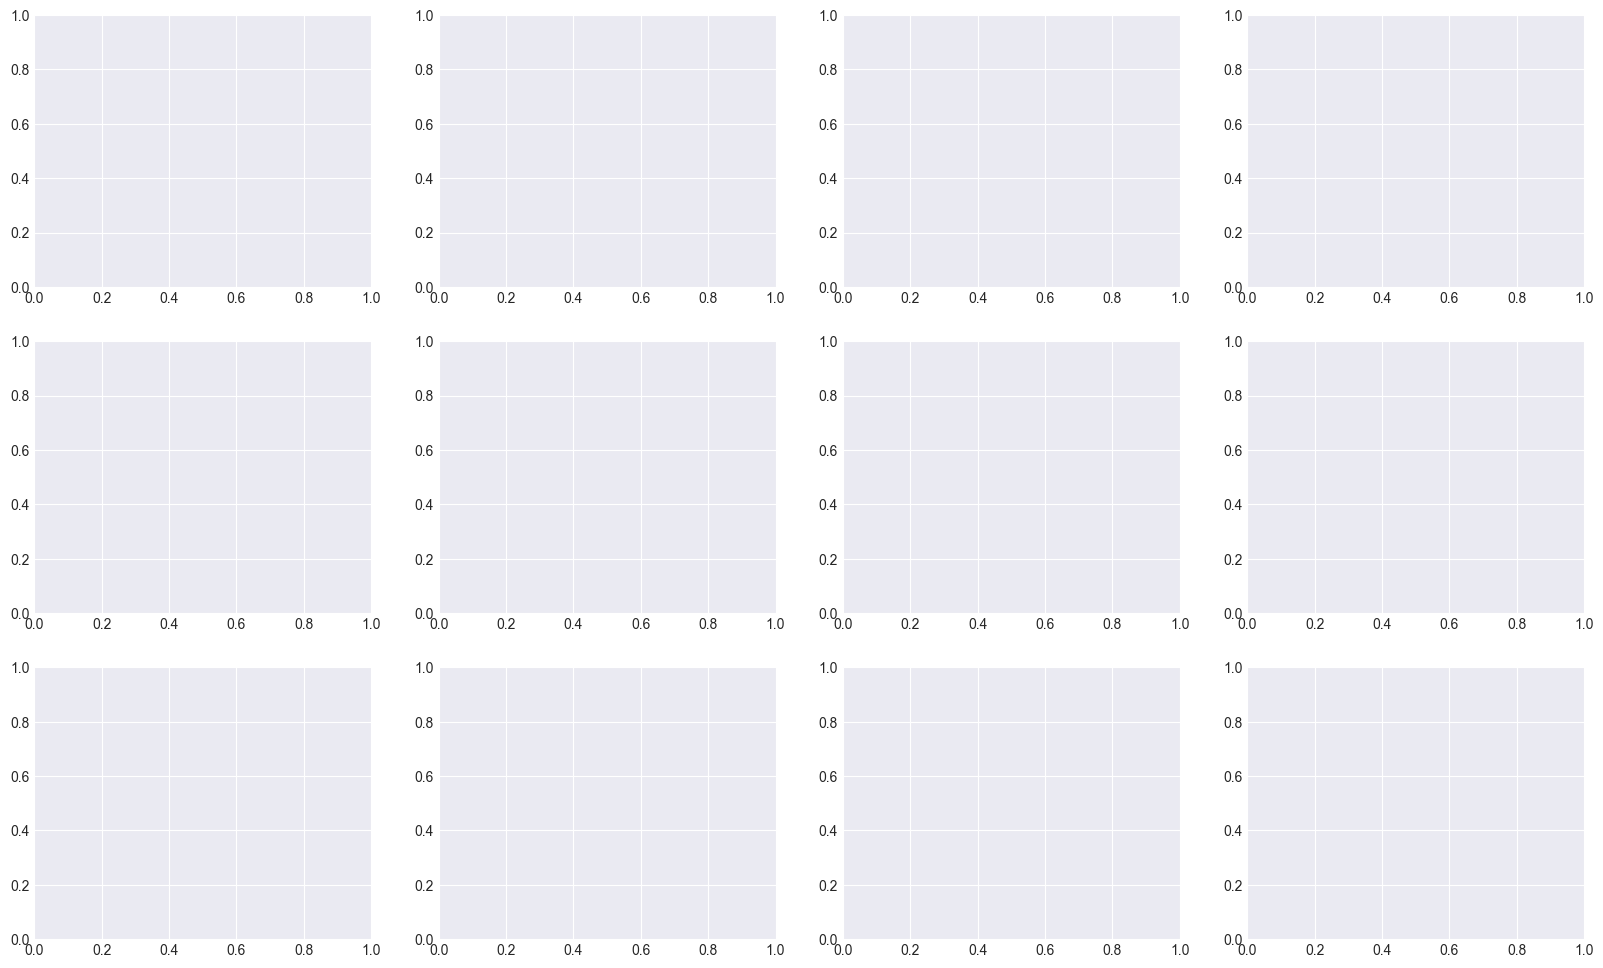

In [164]:
# Visualize likelihood distribution for each cluster
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, analysis in enumerate(cluster_analyses[:12]):  # Show first 12 clusters
    cluster_id = analysis['cluster_id']
    cluster_label = analysis['label']
    
    # Get all likelihoods for this cluster
    members = get_cluster_members_with_likelihood(cluster_id, filtered_candidates_v5)
    likelihoods = [m['likelihood'] for m in members]
    
    if not likelihoods:
        continue
    
    # Plot histogram
    axes[idx].hist(likelihoods, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx].axvline(np.mean(likelihoods), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(likelihoods):.3f}')
    axes[idx].axvline(np.median(likelihoods), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(likelihoods):.3f}')
    
    # Truncate label if too long
    short_label = cluster_label[:30] + '...' if len(cluster_label) > 30 else cluster_label
    axes[idx].set_title(f'C{cluster_id}: {short_label}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Likelihood', fontsize=8)
    axes[idx].set_ylabel('Count', fontsize=8)
    axes[idx].legend(fontsize=7)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(cluster_analyses), 12):
    axes[idx].axis('off')

plt.suptitle('Likelihood Distribution per Cluster', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n📊 Likelihood Statistics Summary:")
print(f"{'Cluster':<10} {'Label':<40} {'Size':<8} {'Mean':<8} {'Median':<8} {'Min':<8} {'Max':<8}")
print("="*100)

for analysis in cluster_analyses:
    cluster_id = analysis['cluster_id']
    cluster_label = analysis['label'][:37] + '...' if len(analysis['label']) > 40 else analysis['label']
    
    members = get_cluster_members_with_likelihood(cluster_id, filtered_candidates_v5)
    likelihoods = [m['likelihood'] for m in members]
    
    if likelihoods:
        print(f"{cluster_id:<10} {cluster_label:<40} {len(likelihoods):<8} {np.mean(likelihoods):<8.4f} {np.median(likelihoods):<8.4f} {np.min(likelihoods):<8.4f} {np.max(likelihoods):<8.4f}")


### 🔎 Inspect Specific Cluster

Chọn cluster ID để xem chi tiết đầy đủ tất cả candidates:

In [ ]:
# Inspect a specific cluster in detail
INSPECT_CLUSTER_ID = 0  # Change this to inspect different clusters

print(f"\n{'='*120}")
print(f"FULL INSPECTION: CLUSTER {INSPECT_CLUSTER_ID}")
print(f"{'='*120}")

# Find cluster analysis
target_cluster = next((c for c in cluster_analyses if c['cluster_id'] == INSPECT_CLUSTER_ID), None)

if not target_cluster:
    print(f"❌ Cluster {INSPECT_CLUSTER_ID} not found!")
else:
    print(f"\n📋 Cluster Info:")
    print(f"   Label: {target_cluster['label']}")
    print(f"   Total Size: {target_cluster['size']} candidates")
    
    print(f"\n📊 Cluster Strength Skills:")
    for i, strength in enumerate(target_cluster['strengths'], 1):
        print(f"   {i}. {strength['skill']:<30} avg={strength['avg_score']:.1f}, freq={strength['frequency']:.1%}")
    
    # Get all members sorted by likelihood
    all_members = get_cluster_members_with_likelihood(INSPECT_CLUSTER_ID, filtered_candidates_v5)
    
    print(f"\n\n{'─'*120}")
    print(f"ALL {len(all_members)} CANDIDATES (sorted by likelihood):")
    print(f"{'─'*120}")
    
    for rank, member in enumerate(all_members, 1):
        candidate_id = member['candidate_id']
        likelihood = member['likelihood']
        
        # Category based on likelihood
        if likelihood > 0.8:
            category = "🟢 EXCELLENT FIT"
        elif likelihood > 0.5:
            category = "🟡 GOOD FIT"
        elif likelihood > 0.3:
            category = "🟠 MODERATE FIT"
        else:
            category = "🔴 WEAK FIT"
        
        print(f"\n{'─'*120}")
        print(f"#{rank}. {candidate_id} | Likelihood: {likelihood:.4f} ({likelihood*100:.2f}%) | {category}")
        print(f"{'─'*120}")
        
        # Get skill comparison
        comparison = display_candidate_skills(candidate_id, target_cluster['strengths'], top_n=15)
        
        print(f"{'Skill':<30} {'Cluster Avg':<15} {'Candidate':<15} {'Difference':<15} {'Status'}")
        print(f"{'-'*100}")
        
        for skill_data in comparison:
            skill = skill_data['skill']
            cluster_avg = skill_data['cluster_avg']
            cand_score = skill_data['candidate']
            diff = skill_data['diff']
            
            # Status indicator
            if cand_score == 0 and cluster_avg > 0:
                status = "❌ MISSING"
            elif diff > 10:
                status = "✅ EXCEED"
            elif diff > 0:
                status = "✅ ABOVE"
            elif diff > -10:
                status = "⚠️  BELOW"
            else:
                status = "❌ WEAK"
            
            print(f"{skill:<30} {cluster_avg:<15.1f} {cand_score:<15.1f} {diff:>+13.1f}   {status}")
        
        # Get ALL candidate skills (not just cluster strengths)
        candidate_idx = candidate_id_to_idx[candidate_id]
        candidate = candidates_normalized[candidate_idx]
        all_cand_skills = sorted(
            [(skill, score) for skill, score in candidate['normalized_scores'].items() if score > 0],
            key=lambda x: x[1],
            reverse=True
        )[:10]
        
        print(f"\n   📌 Candidate's Top 10 Skills (all skills):")
        for skill, score in all_cand_skills:
            in_cluster = "⭐" if skill in [s['skill'] for s in target_cluster['strengths']] else "  "
            print(f"      {in_cluster} {skill:<30} {score:.1f}")

print(f"\n{'='*120}")
print(f"💡 Insights:")
print(f"   - High likelihood (>0.8): Candidate perfectly matches cluster profile")
print(f"   - Moderate likelihood (0.3-0.8): Candidate has some cluster skills")
print(f"   - Low likelihood (<0.3): Candidate weakly fits, consider reassignment")
print(f"   - ⭐ indicates skill is also a cluster strength")
print(f"{'='*120}")


In [127]:
print("\n8. Saving v5 results...")

output_v5 = {
    'total_candidates': len(candidates_normalized),
    'total_clusters': len(clusters_output_v5),
    'clustering_method': 'Skill-Weighted Multi-label GMM (v5)',
    'embedding_dims': features_umap.shape[1],
    'improvements': [
        'Solution 1: Skill-weighted assignment (50% distance + 50% skill overlap)',
        'Solution 2: Post-assignment filtering (require >= 2/5 cluster skills)',
        'Addresses misalignment between assignment and cluster labels',
        'Better interpretability and trustworthiness'
    ],
    'parameters': {
        'distance_weight': 0.5,
        'skill_weight': 0.5,
        'distance_multiplier': 1.5,
        'min_skill_matches': 2,
        'top_k_skills_checked': 5,
        'min_score_threshold': 65
    },
    'multi_label_statistics': multi_label_stats_v5,
    'filter_statistics': {
        'passed_all_checks': filter_stats['passed_all'],
        'reassigned': filter_stats['reassigned'],
        'became_outliers': filter_stats['became_outliers'],
        'failed_checks_count': len(filter_stats['failed_checks'])
    },
    'assignment_statistics': {
        'avg_skill_overlap_score': float(np.mean(assignment_stats['avg_skill_score'])),
        'avg_distance_score': float(np.mean(assignment_stats['avg_distance_score'])),
        'avg_final_score': float(np.mean(assignment_stats['avg_final_score']))
    },
    'clusters': clusters_output_v5
}

with open('data/processed/clusters_final_v5.json', 'w', encoding='utf-8') as f:
    json.dump(output_v5, f, indent=2, ensure_ascii=False)

with open('data/processed/cluster_assignments_v5.json', 'w', encoding='utf-8') as f:
    json.dump(filtered_candidates_v5, f, indent=2)

print(f"   [OK] Saved to data/processed/clusters_final_v5.json")
print(f"   [OK] Saved cluster assignments to data/processed/cluster_assignments_v5.json")

print("\n" + "="*70)
print("PHASE 3 v5 COMPLETE")
print("="*70)


8. Saving v5 results...
   [OK] Saved to data/processed/clusters_final_v5.json
   [OK] Saved cluster assignments to data/processed/cluster_assignments_v5.json

PHASE 3 v5 COMPLETE


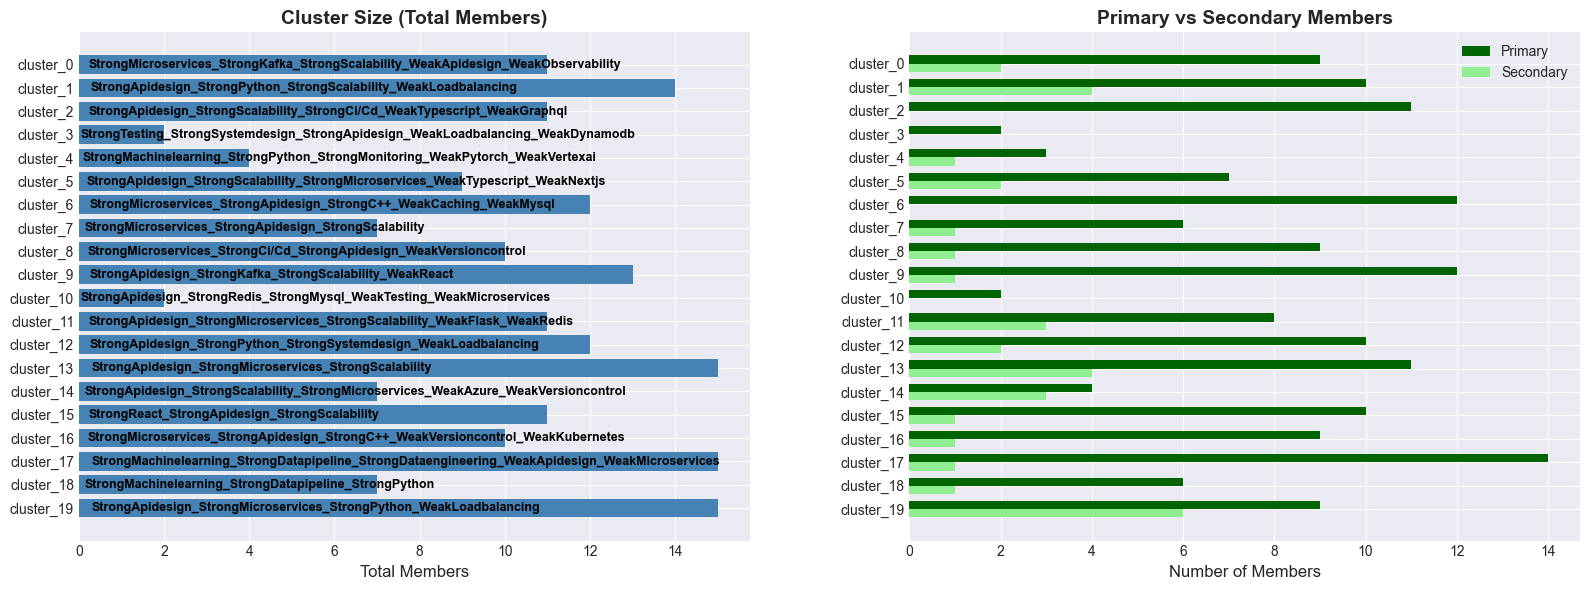

In [158]:
# Create summary dataframe
cluster_summary = []
for cluster in clusters_output_v5:
    cluster_summary.append({
        'Cluster ID': cluster['cluster_id'],
        'Label': cluster['cluster_label'],
        'Size': cluster['size'],
        'Primary': cluster['primary_members'],
        'Secondary': cluster['secondary_members']
    })

cluster_df = pd.DataFrame(cluster_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total members with labels inside bars
bars = axes[0].barh(cluster_df['Cluster ID'], cluster_df['Size'], color='steelblue')
axes[0].set_xlabel('Total Members', fontsize=12)
axes[0].set_title('Cluster Size (Total Members)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Add labels inside bars
for i, (bar, label) in enumerate(zip(bars, cluster_df['Label'])):
    width = bar.get_width()
    # Truncate label if too long
    display_label = label #if len(label) <= 40 else label[:37] + '...'
    axes[0].text(width * 0.02, bar.get_y() + bar.get_height()/2,
                display_label,
                ha='left', va='center', color='black', fontweight='bold', fontsize=9)

# Primary vs Secondary
x = np.arange(len(cluster_df))
width = 0.35
axes[1].barh(x - width/2, cluster_df['Primary'], width, label='Primary', color='darkgreen')
axes[1].barh(x + width/2, cluster_df['Secondary'], width, label='Secondary', color='lightgreen')
axes[1].set_yticks(x)
axes[1].set_yticklabels(cluster_df['Cluster ID'])
axes[1].set_xlabel('Number of Members', fontsize=12)
axes[1].set_title('Primary vs Secondary Members', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

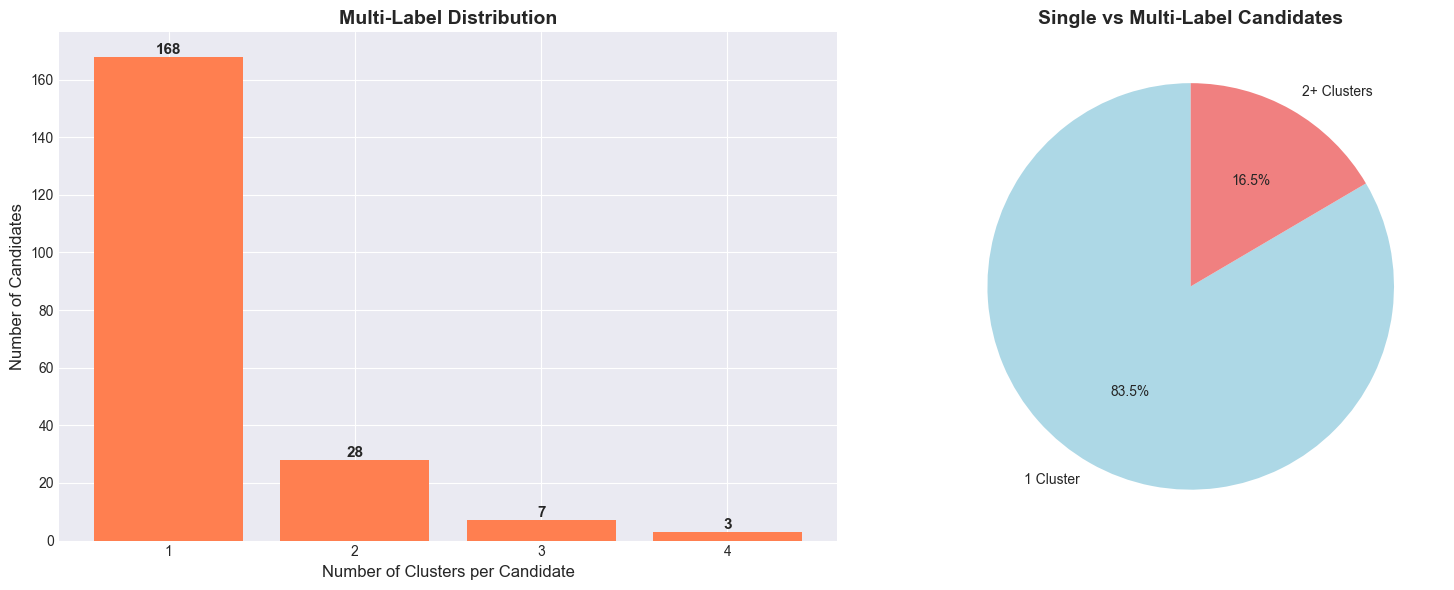

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cluster_count_dist = Counter([c['num_clusters'] for c in candidate_clusters_v5])

# Bar chart with numbers inside
x = sorted(cluster_count_dist.keys())
y = [cluster_count_dist[i] for i in x]
bars = axes[0].bar(x, y, color='coral')
axes[0].set_xlabel('Number of Clusters per Candidate', fontsize=12)
axes[0].set_ylabel('Number of Candidates', fontsize=12)
axes[0].set_title('Multi-Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
stats = output_v5['multi_label_statistics']
labels = ['1 Cluster', '2+ Clusters']
sizes = [stats['candidates_in_1_cluster'], stats['candidates_in_2plus_clusters']]
colors = ['lightblue', 'lightcoral']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Single vs Multi-Label Candidates', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Computing 2D UMAP projection for visualization...

Cluster labels from cluster_df:
  Cluster cluster_0: StrongMicroservices_StrongKafka_StrongScalability_WeakApidesign_WeakObservability
  Cluster cluster_1: StrongApidesign_StrongPython_StrongScalability_WeakLoadbalancing
  Cluster cluster_2: StrongApidesign_StrongScalability_StrongCi/Cd_WeakTypescript_WeakGraphql
  Cluster cluster_3: StrongTesting_StrongSystemdesign_StrongApidesign_WeakLoadbalancing_WeakDynamodb
  Cluster cluster_4: StrongMachinelearning_StrongPython_StrongMonitoring_WeakPytorch_WeakVertexai
  Cluster cluster_5: StrongApidesign_StrongScalability_StrongMicroservices_WeakTypescript_WeakNextjs
  Cluster cluster_6: StrongMicroservices_StrongApidesign_StrongC++_WeakCaching_WeakMysql
  Cluster cluster_7: StrongMicroservices_StrongApidesign_StrongScalability
  Cluster cluster_8: StrongMicroservices_StrongCi/Cd_StrongApidesign_WeakVersioncontrol
  Cluster cluster_9: StrongApidesign_StrongKafka_StrongScalability_WeakReact
  Clu

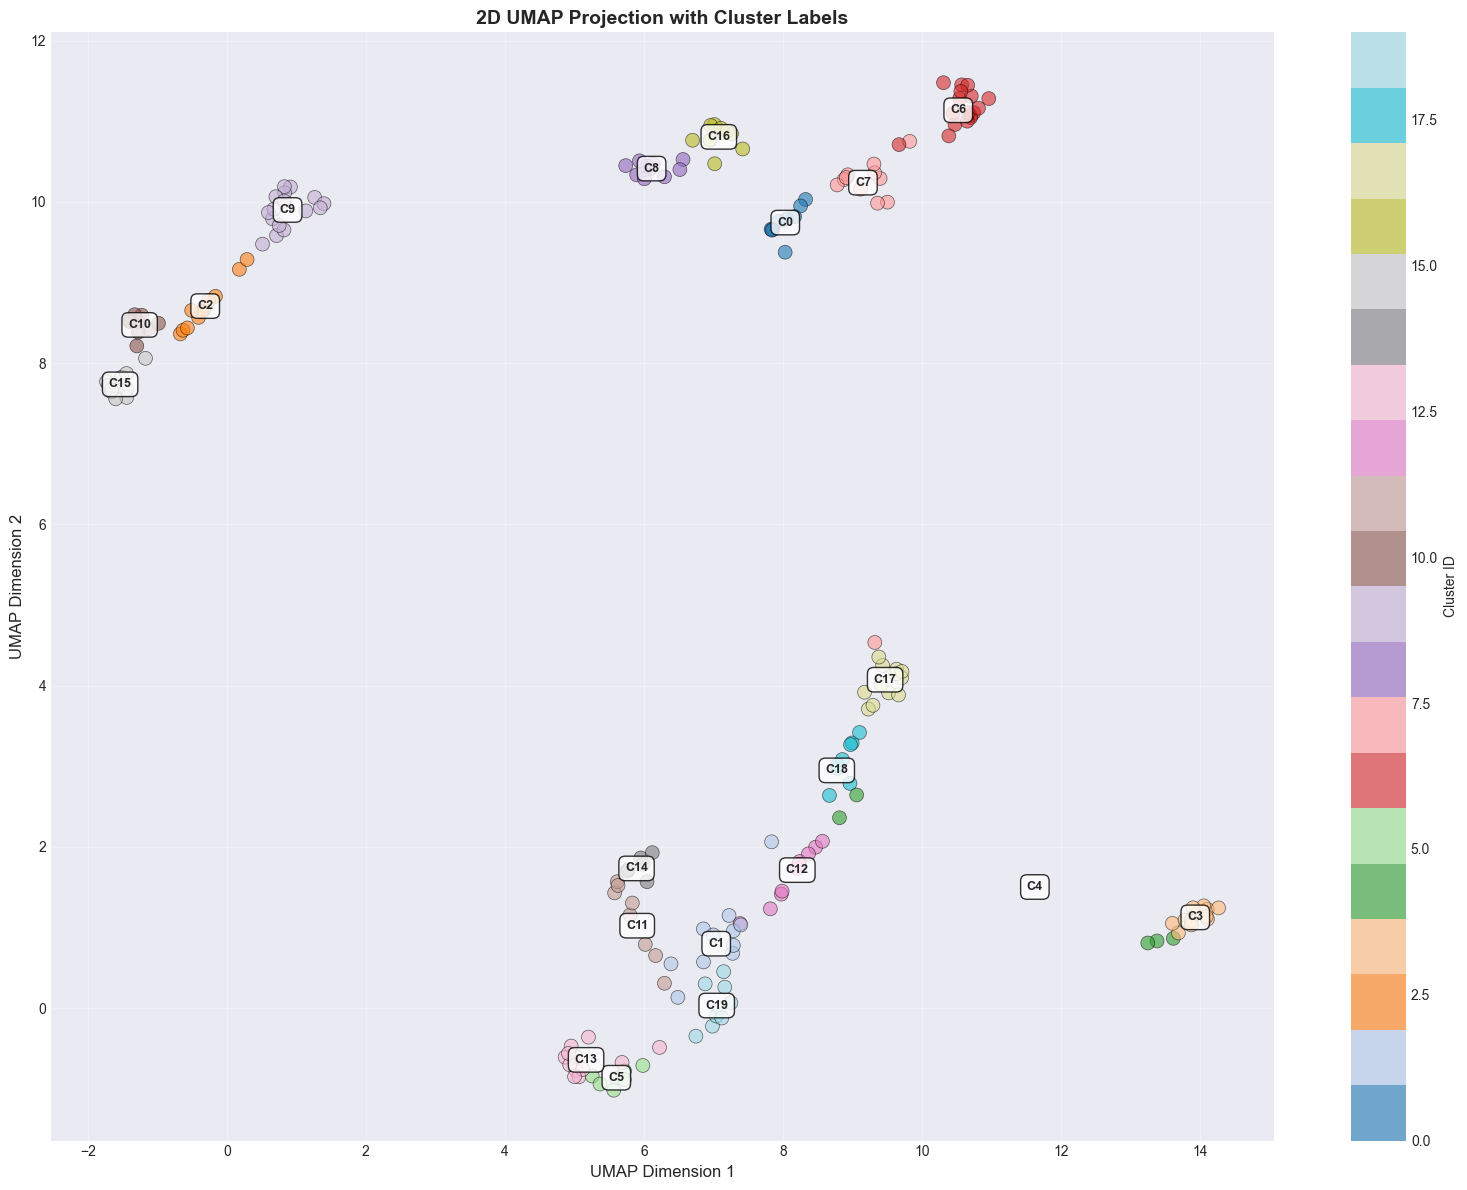

In [155]:
print('Computing 2D UMAP projection for visualization...')
reducer_2d = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer_2d.fit_transform(features_umap)

# Get primary clusters
primary_clusters = [c['primary_cluster'] for c in candidate_clusters_v5]

# Use labels from cluster_df['Label']
cluster_labels_dict = dict(zip(cluster_df['Cluster ID'], cluster_df['Label']))

print(f"\nCluster labels from cluster_df:")
for cluster_id, label in cluster_labels_dict.items():
    print(f"  Cluster {cluster_id}: {label}")

plt.figure(figsize=(16, 12))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=primary_clusters,
    cmap='tab20',
    s=100,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Add cluster labels at centroids
cluster_centers_2d = {}
for cluster_id in range(best_k):
    # Get all points in this cluster
    cluster_points = embeddings_2d[primary_labels == cluster_id]
    if len(cluster_points) > 0:
        # Calculate centroid
        centroid = cluster_points.mean(axis=0)
        cluster_centers_2d[cluster_id] = centroid
        
        # Add label from cluster_df
        label = cluster_labels_dict.get(cluster_id, f"C{cluster_id}")
        plt.annotate(
            label,
            xy=centroid,
            fontsize=9,
            fontweight='bold',
            ha='center',
            va='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
        )

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.title('2D UMAP Projection with Cluster Labels', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Score Distribution Analysis

Phân tích phân bố điểm số để hiểu rõ ngưỡng strength (≥70) và weakness (<65)

### Giải thích ngưỡng Strength (≥70) và Weakness (<65)

**Lý do chọn ngưỡng:**

1. **Weakness < 65**:
   - Dưới median/average → kỹ năng yếu hơn trung bình
   - Phù hợp với hệ thống đánh giá 100 điểm (< 65% = không đạt)
   - Dựa trên phân bố thực tế của dữ liệu

2. **Strength ≥ 70**:
   - Trên trung bình rõ rệt → kỹ năng nổi bật
   - 70+ thường được coi là "good" trong đánh giá performance
   - Đảm bảo chỉ lấy những skill thực sự mạnh

3. **Gap 65-70** (Neutral zone):
   - Tránh nhiễu: skill ở mức trung bình không được gắn nhãn
   - Chỉ focus vào điểm mạnh/yếu rõ ràng
   - Giúp cluster label ngắn gọn và có ý nghĩa

**Có thể điều chỉnh:**
- Nếu muốn strict hơn: `strength ≥ 75`, `weakness < 60`
- Nếu muốn loose hơn: `strength ≥ 65`, `weakness < 70`
- Dựa vào phân bố điểm số ở trên để quyết định

In [159]:
print("Analyzing score distribution across all candidates...")

# Collect all scores from all candidates
all_skill_scores = []
skill_score_distribution = defaultdict(list)

for candidate in candidates_normalized:
    for skill, score in candidate['normalized_scores'].items():
        all_skill_scores.append(score)
        skill_score_distribution[skill].append(score)

# Calculate statistics
all_skill_scores = np.array(all_skill_scores)

print(f"\n{'='*80}")
print("OVERALL SCORE DISTRIBUTION")
print(f"{'='*80}")
print(f"Total scores: {len(all_skill_scores):,}")
print(f"Mean: {np.mean(all_skill_scores):.2f}")
print(f"Median: {np.median(all_skill_scores):.2f}")
print(f"Std Dev: {np.std(all_skill_scores):.2f}")
print(f"\nPercentiles:")
print(f"  10th: {np.percentile(all_skill_scores, 10):.2f}")
print(f"  25th: {np.percentile(all_skill_scores, 25):.2f}")
print(f"  50th (median): {np.percentile(all_skill_scores, 50):.2f}")
print(f"  75th: {np.percentile(all_skill_scores, 75):.2f}")
print(f"  90th: {np.percentile(all_skill_scores, 90):.2f}")

# Count by score ranges
ranges = [
    (0, 40, "Very Low (0-40)"),
    (40, 50, "Low (40-50)"),
    (50, 60, "Below Average (50-60)"),
    (60, 65, "Average- (60-65)"),
    (65, 70, "Average+ (65-70)"),
    (70, 80, "Good (70-80)"),
    (80, 90, "Very Good (80-90)"),
    (90, 101, "Excellent (90-100)")
]

print(f"\n{'='*80}")
print("SCORE DISTRIBUTION BY RANGE")
print(f"{'='*80}")
for min_val, max_val, label in ranges:
    count = np.sum((all_skill_scores >= min_val) & (all_skill_scores < max_val))
    pct = count / len(all_skill_scores) * 100
    print(f"{label:25s}: {count:6,} ({pct:5.2f}%)")

print(f"\n{'='*80}")
print("THRESHOLD ANALYSIS")
print(f"{'='*80}")
print(f"Scores < 65 (Weakness):  {np.sum(all_skill_scores < 65):6,} ({np.sum(all_skill_scores < 65)/len(all_skill_scores)*100:5.2f}%)")
print(f"Scores 65-70 (Neutral):  {np.sum((all_skill_scores >= 65) & (all_skill_scores < 70)):6,} ({np.sum((all_skill_scores >= 65) & (all_skill_scores < 70))/len(all_skill_scores)*100:5.2f}%)")
print(f"Scores ≥ 70 (Strength):  {np.sum(all_skill_scores >= 70):6,} ({np.sum(all_skill_scores >= 70)/len(all_skill_scores)*100:5.2f}%)")

Analyzing score distribution across all candidates...

OVERALL SCORE DISTRIBUTION
Total scores: 3,619
Mean: 71.81
Median: 76.00
Std Dev: 12.73

Percentiles:
  10th: 54.73
  25th: 67.75
  50th (median): 76.00
  75th: 80.00
  90th: 82.56

SCORE DISTRIBUTION BY RANGE
Very Low (0-40)          :    111 ( 3.07%)
Low (40-50)              :    124 ( 3.43%)
Below Average (50-60)    :    295 ( 8.15%)
Average- (60-65)         :    214 ( 5.91%)
Average+ (65-70)         :    322 ( 8.90%)
Good (70-80)             :  1,592 (43.99%)
Very Good (80-90)        :    961 (26.55%)
Excellent (90-100)       :      0 ( 0.00%)

THRESHOLD ANALYSIS
Scores < 65 (Weakness):     744 (20.56%)
Scores 65-70 (Neutral):     322 ( 8.90%)
Scores ≥ 70 (Strength):   2,553 (70.54%)


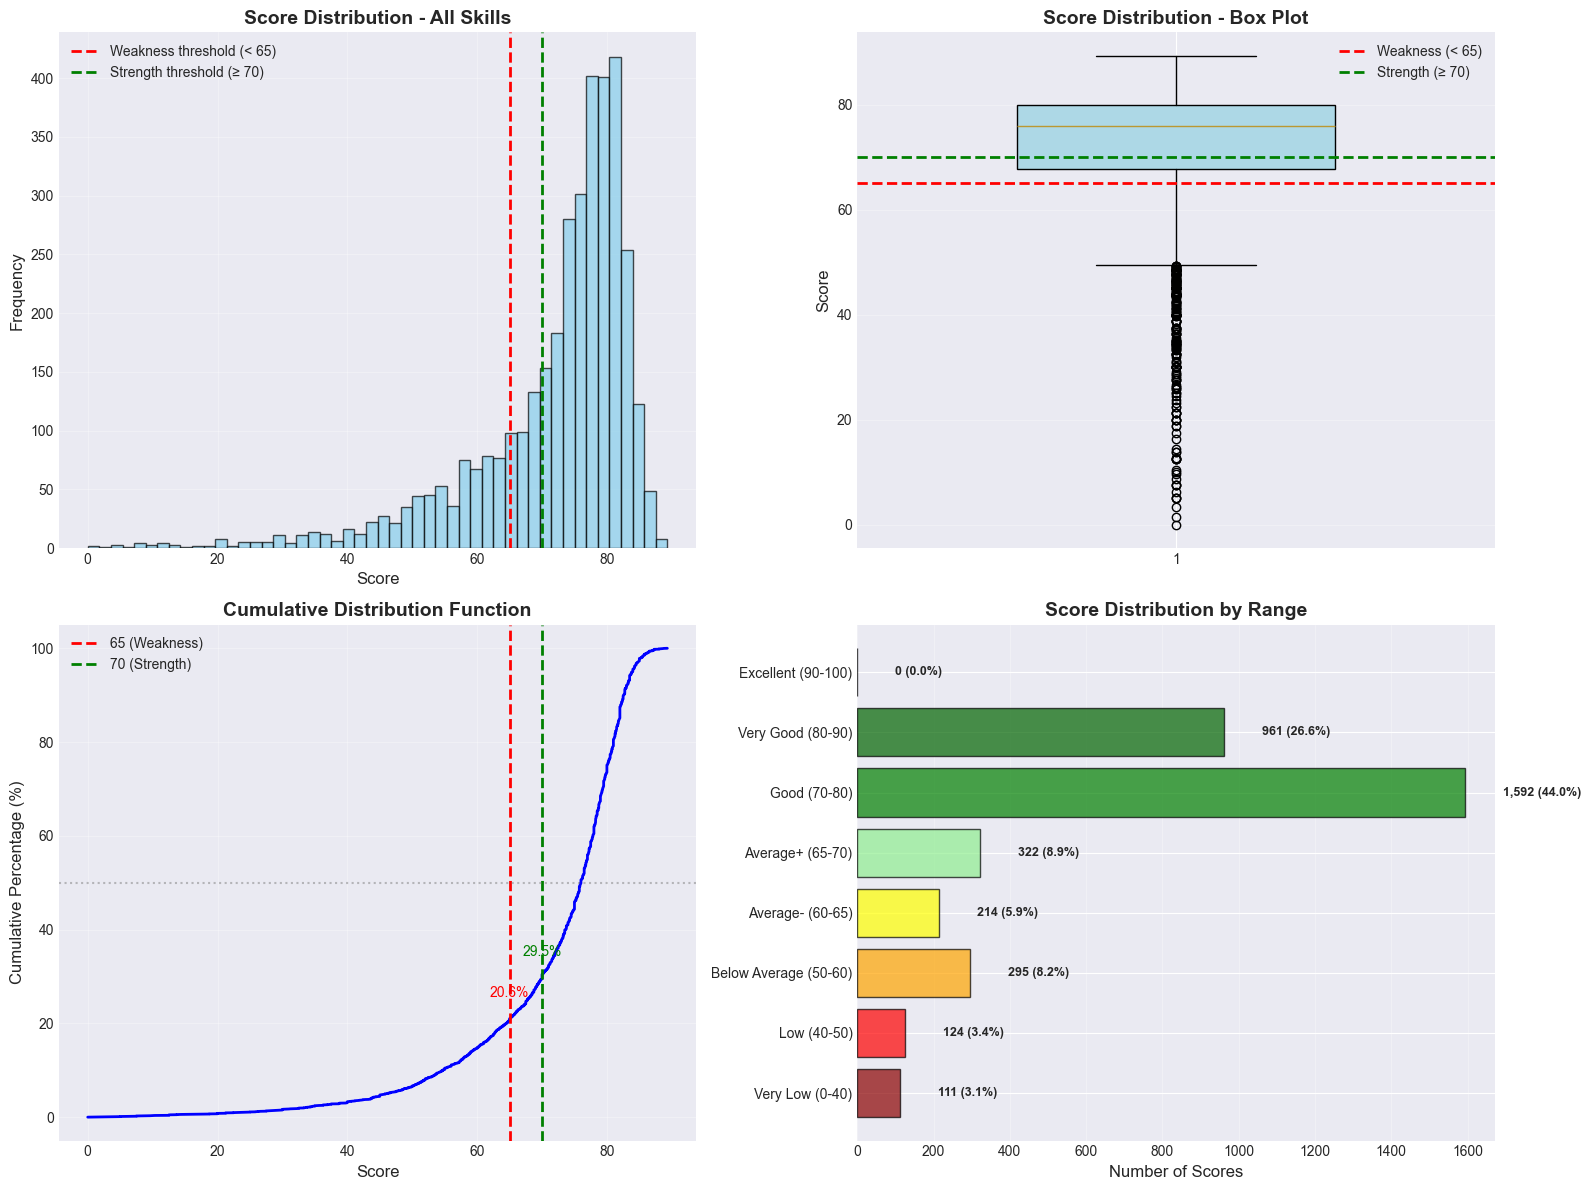


✓ Score distribution visualized!


In [160]:
# Visualize score distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram with thresholds
ax1 = axes[0, 0]
ax1.hist(all_skill_scores, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
ax1.axvline(65, color='red', linestyle='--', linewidth=2, label='Weakness threshold (< 65)')
ax1.axvline(70, color='green', linestyle='--', linewidth=2, label='Strength threshold (≥ 70)')
ax1.set_xlabel('Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Score Distribution - All Skills', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Box plot
ax2 = axes[0, 1]
bp = ax2.boxplot(all_skill_scores, vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
ax2.axhline(65, color='red', linestyle='--', linewidth=2, label='Weakness (< 65)')
ax2.axhline(70, color='green', linestyle='--', linewidth=2, label='Strength (≥ 70)')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Score Distribution - Box Plot', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Cumulative distribution
ax3 = axes[1, 0]
sorted_scores = np.sort(all_skill_scores)
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores) * 100
ax3.plot(sorted_scores, cumulative, linewidth=2, color='blue')
ax3.axvline(65, color='red', linestyle='--', linewidth=2, label='65 (Weakness)')
ax3.axvline(70, color='green', linestyle='--', linewidth=2, label='70 (Strength)')
ax3.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax3.set_xlabel('Score', fontsize=12)
ax3.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax3.set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Add percentile markers
pct_at_65 = np.sum(all_skill_scores < 65) / len(all_skill_scores) * 100
pct_at_70 = np.sum(all_skill_scores < 70) / len(all_skill_scores) * 100
ax3.text(65, pct_at_65 + 5, f'{pct_at_65:.1f}%', ha='center', fontsize=10, color='red')
ax3.text(70, pct_at_70 + 5, f'{pct_at_70:.1f}%', ha='center', fontsize=10, color='green')

# 4. Distribution by range (bar chart)
ax4 = axes[1, 1]
range_labels = [label for _, _, label in ranges]
range_counts = []
for min_val, max_val, _ in ranges:
    count = np.sum((all_skill_scores >= min_val) & (all_skill_scores < max_val))
    range_counts.append(count)

colors_bar = ['darkred', 'red', 'orange', 'yellow', 'lightgreen', 'green', 'darkgreen', 'blue']
bars = ax4.barh(range_labels, range_counts, color=colors_bar, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Number of Scores', fontsize=12)
ax4.set_title('Score Distribution by Range', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, count) in enumerate(zip(bars, range_counts)):
    pct = count / len(all_skill_scores) * 100
    ax4.text(count + 100, i, f'{count:,} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Score distribution visualized!")

##

## Test v5 on Sample Candidates

In [204]:
def explain_candidate_clustering(candidate_id, top_k=5):
    """
    Explain why a candidate belongs to their assigned clusters.
    """
    # Find candidate
    candidate = next((c for c in candidates_normalized if c['candidate_id'] == candidate_id), None)
    if not candidate:
        print(f"Candidate {candidate_id} not found!")
        return

    assignment = next((a for a in candidate_clusters if a['candidate_id'] == candidate_id), None)
    if not assignment:
        print(f"Assignment for {candidate_id} not found!")
        return

    candidate_idx = next(i for i, c in enumerate(candidates_normalized) if c['candidate_id'] == candidate_id)

    print('='*80)
    print(f'CANDIDATE: {candidate_id}')
    print('='*80)

    # Show top skills
    print(f"\nTotal Skills: {len(candidate['normalized_skills'])}")
    print(f"\nTop {top_k} Skills (by score):")
    sorted_skills = sorted(candidate['normalized_scores'].items(), key=lambda x: x[1], reverse=True)[:top_k]
    for skill, score in sorted_skills:
        print(f"  - {skill:50s} | Score: {score:5.1f}")

    # Show clusters
    print(f"\n{'='*80}")
    print(f"CLUSTER ASSIGNMENTS: {len(assignment['clusters'])} cluster(s)")
    print('='*80)

    for i, cluster_info in enumerate(assignment['clusters']):
        cluster_id = cluster_info['cluster_id']
        cluster_score = cluster_info['score']
        is_primary = (cluster_id == assignment['primary_cluster'])

        cluster = next(c for c in clusters_output if c['cluster_id'] == f'cluster_{cluster_id}')

        print(f"\n{'#'*80}")
        print(f"Cluster {i+1}/{len(assignment['clusters'])}: cluster_{cluster_id} {'[PRIMARY]' if is_primary else '[SECONDARY]'}")
        print(f"{'#'*80}")
        print(f"Label: {cluster['cluster_label']}")
        print(f"Assignment Score: {cluster_score:.4f}")
        print(f"Profile Type: {cluster['profile']['profile_type']}")
        print(f"Cluster Size: {cluster['size']} members")

        # Matching strengths
        print(f"\n{'*'*80}")
        print("WHY THIS CLUSTER? - Matching Strengths:")
        print('*'*80)
        for strength in cluster['profile']['strengths'][:5]:
            skill = strength['skill']
            cluster_avg = strength['avg_score']
            candidate_score = candidate['normalized_scores'].get(skill, 0)
            match_status = '✓' if candidate_score > 0 else '✗'
            print(f"  {match_status} {skill:40s} | Cluster: {cluster_avg:5.1f} | Candidate: {candidate_score:5.1f}")

        # Matching weaknesses
        print(f"\n{'*'*80}")
        print("Matching Weaknesses:")
        print('*'*80)
        for weakness in cluster['profile']['weaknesses'][:5]:
            skill = weakness['skill']
            cluster_avg = weakness['avg_score']
            candidate_score = candidate['normalized_scores'].get(skill, 0)
            match_status = '✓' if candidate_score > 0 and candidate_score < 65 else '✗'
            print(f"  {match_status} {skill:40s} | Cluster: {cluster_avg:5.1f} | Candidate: {candidate_score:5.1f}")

    # Visualize
    print(f"\n{'='*80}")
    print("VISUAL: Candidate Position in 2D Space")
    print('='*80)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot all (gray)
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='lightgray', s=50, alpha=0.3)

    # Highlight clusters
    colors = plt.cm.tab10(np.linspace(0, 1, len(assignment['clusters'])))
    for i, cluster_info in enumerate(assignment['clusters']):
        cluster_id = cluster_info['cluster_id']
        cluster_candidate_ids = next(c['members'] for c in clusters_output if c['cluster_id'] == f'cluster_{cluster_id}')
        cluster_indices = [j for j, c in enumerate(candidates_normalized) if c['candidate_id'] in cluster_candidate_ids]

        ax.scatter(
            embeddings_2d[cluster_indices, 0],
            embeddings_2d[cluster_indices, 1],
            c=[colors[i]],
            s=100,
            alpha=0.5,
            label=f"cluster_{cluster_id}"
        )

    # Highlight target
    ax.scatter(
        embeddings_2d[candidate_idx, 0],
        embeddings_2d[candidate_idx, 1],
        c='red',
        s=500,
        marker='*',
        edgecolors='black',
        linewidth=2,
        label=f'TARGET: {candidate_id[:8]}...',
        zorder=100
    )

    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.title(f'Candidate Position: {candidate_id[:8]}...', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('✓ Function defined: explain_candidate_clustering(candidate_id)')

✓ Function defined: explain_candidate_clustering(candidate_id)


CANDIDATE: 001e7efe-a36a-4b4c-a459-ada3f9268ac9

Total Skills: 4

Top 5 Skills (by score):
  - backend frameworks                                 | Score:  73.5
  - full stack development                             | Score:  69.0
  - python                                             | Score:  61.8
  - api design                                         | Score:  53.2

CLUSTER ASSIGNMENTS: 3 cluster(s)

################################################################################
Cluster 1/3: cluster_4 [PRIMARY]
################################################################################
Label: StrongPython_StrongMachinelearning_StrongDatapipeline_WeakPytorch_WeakVertexai
Assignment Score: 0.6250
Profile Type: Balanced
Cluster Size: 8 members

********************************************************************************
WHY THIS CLUSTER? - Matching Strengths:
********************************************************************************
  ✓ python                           

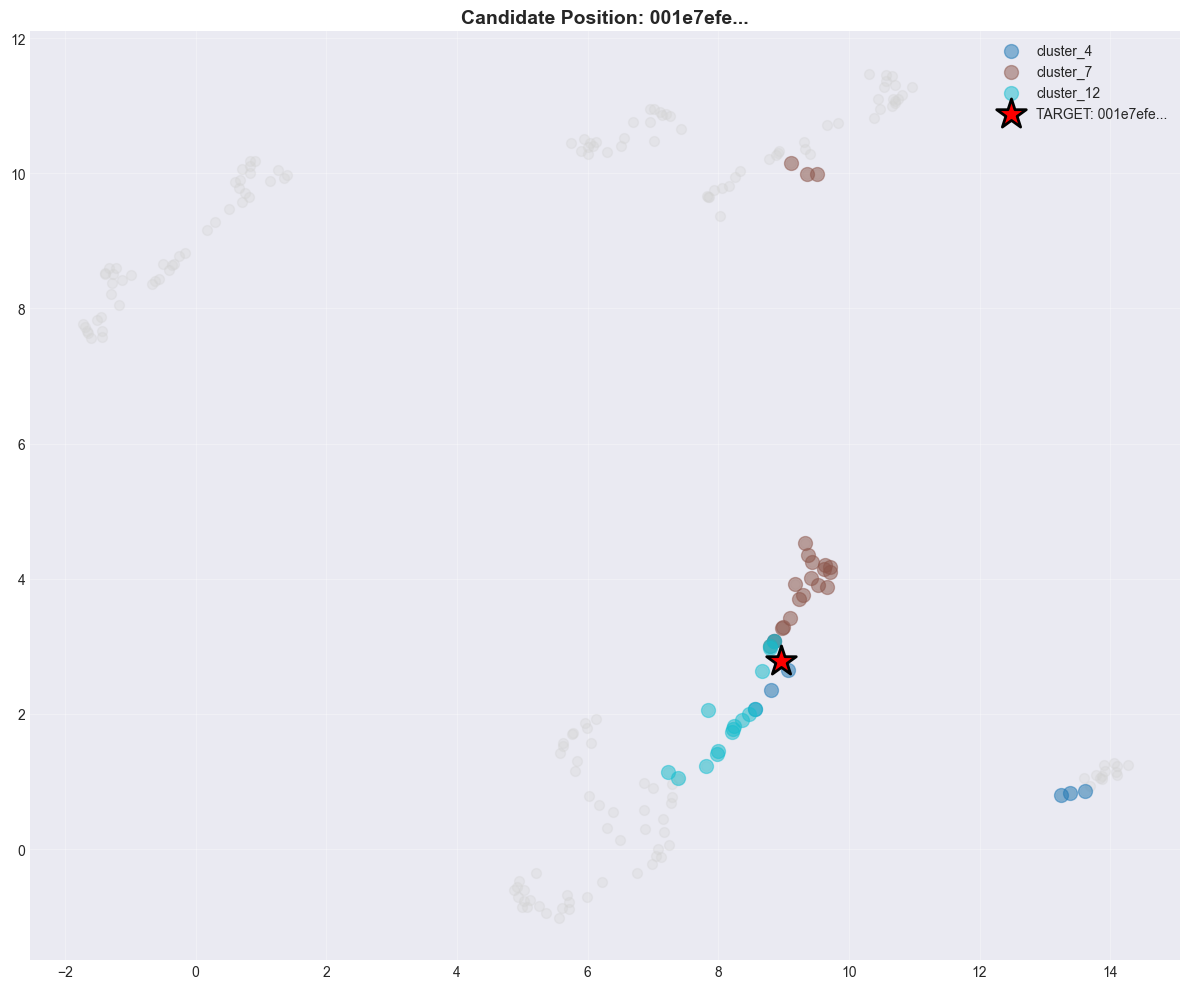

In [205]:
# Find a candidate with multiple clusters
multi_cluster_candidates = [a for a in candidate_clusters if a['num_clusters'] >= 3]
if multi_cluster_candidates:
    sample_candidate = multi_cluster_candidates[0]['candidate_id']
    explain_candidate_clustering(sample_candidate)
else:
    print('No candidates with 3+ clusters found')

### Detailed Cluster Analysis

In [184]:
print("\n" + "="*80)
print("4. DETAILED CLUSTER ANALYSIS")
print("="*80)

# Display detailed information for each cluster
for i, cluster in enumerate(clusters_output_v5):
    print(f"\n{'='*80}")
    print(f"CLUSTER {i}: {cluster['cluster_label']}")
    print(f"{'='*80}")
    
    print(f"\nCluster ID: {cluster['cluster_id']}")
    print(f"Size: {len(cluster['members'])} candidates")
    
    # Top skills (from strengths)
    print(f"\nTop 5 Skills:")
    for j, strength_item in enumerate(cluster['profile']['strengths'][:5], 1):
        skill = strength_item['skill']
        score = strength_item['avg_score']
        print(f"  {j}. {skill:30s} (score: {score:.2f})")
    
    # Member sample (first 5)
    print(f"\nMember Sample (first 5):")
    for j, member_id in enumerate(cluster['members'][:5], 1):
        # Find candidate details from filtered_candidates_v5
        filtered_candidate = next((c for c in filtered_candidates_v5 if c['candidate_id'] == member_id), None)
        if filtered_candidate:
            # Get original candidate from candidates_normalized to access skills
            candidate_idx = candidate_id_to_idx[member_id]
            candidate = candidates_normalized[candidate_idx]
            
            # Get top 3 skills of this candidate
            top_3_skills = ', '.join([f"{s}" for s, _ in sorted(candidate['normalized_scores'].items(), key=lambda x: x[1], reverse=True)[:3]])
            clusters_count = filtered_candidate['num_clusters']
            print(f"  {j}. {member_id:15s} | Skills: {top_3_skills[:60]:60s} | In {clusters_count} cluster(s)")
    
    if len(cluster['members']) > 5:
        print(f"  ... and {len(cluster['members']) - 5} more members")
    
    avg_score = np.mean([s['avg_score'] for s in cluster['profile']['strengths'][:5]]) if cluster['profile']['strengths'] else 0
    print(f"  Average skill score: {avg_score:.2f}")
    print(f"  Profile type: {cluster['profile']['profile_type']}")
    print(f"  Domain breadth: {cluster['profile']['breadth']} domains")


print("\n✓ Detailed cluster analysis complete")


4. DETAILED CLUSTER ANALYSIS

CLUSTER 0: StrongMicroservices_StrongApidesign_StrongScalability_WeakObservability

Cluster ID: cluster_0
Size: 26 candidates

Top 5 Skills:
  1. microservices                  (score: 79.22)
  2. api design                     (score: 72.51)
  3. scalability                    (score: 76.31)
  4. kafka                          (score: 77.93)
  5. spring boot                    (score: 76.63)

Member Sample (first 5):
  1. 05107fca-fc13-4336-bf7f-e690721bb744 | Skills: golang, backend frameworks, scalability                      | In 1 cluster(s)
  2. 0b5576c0-7344-4bb9-a360-7145298d0cbe | Skills: cache invalidation, caching, microservices                   | In 1 cluster(s)
  3. 0b80a9e3-638a-41b5-96fd-4da84727a1d0 | Skills: error handling, message queues, scalability                  | In 1 cluster(s)
  4. 1067fc39-eb6d-4e4f-b4c8-bdc1556b29fd | Skills: microservices, kafka, scalability                            | In 1 cluster(s)
  5. 168e3595-f4bf-4c0a


6. Creating Skills Distribution Heatmap...


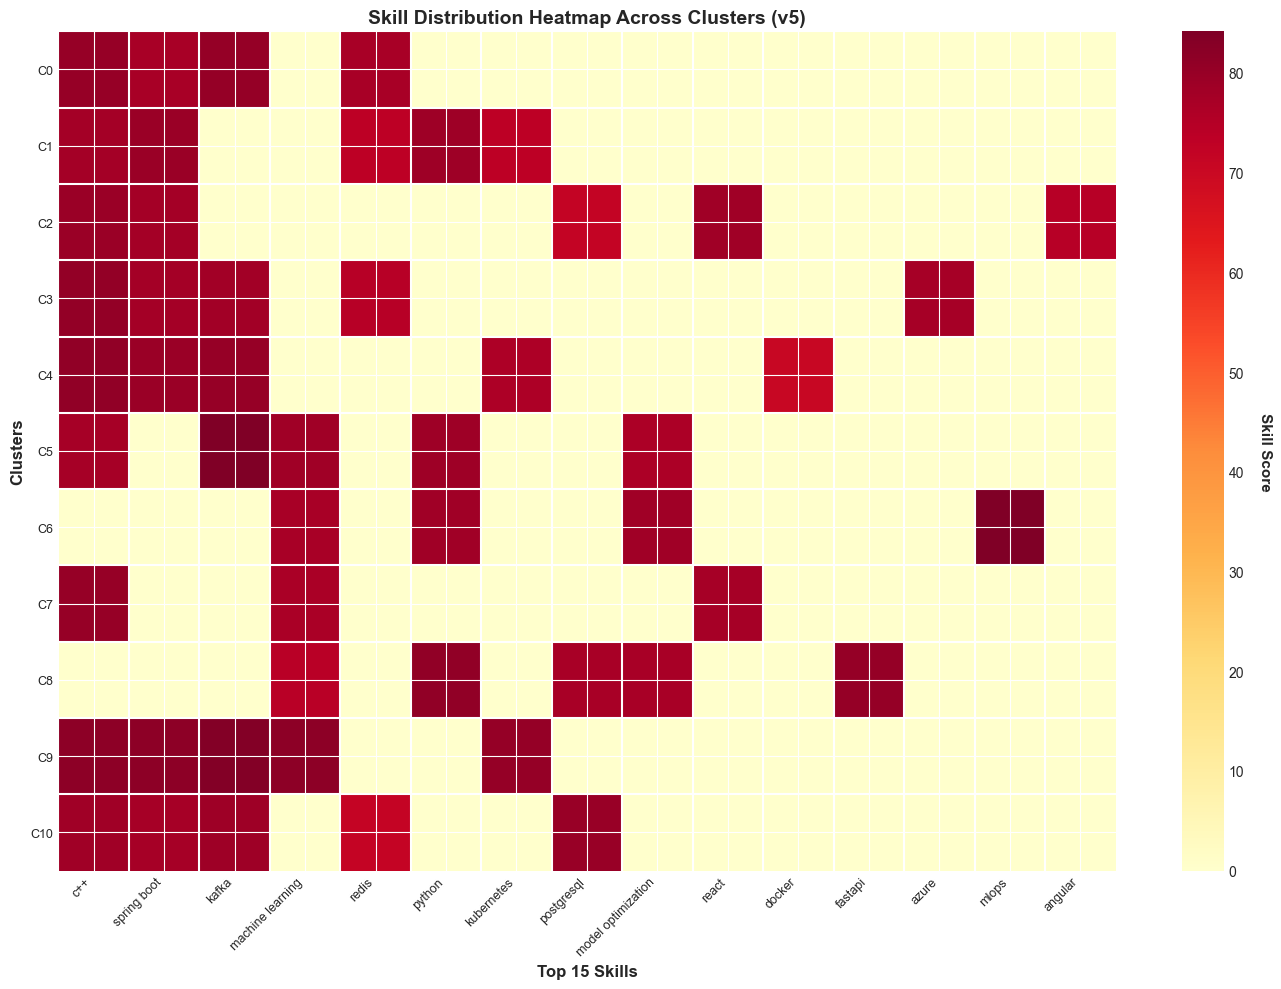

✓ Skills heatmap complete


In [88]:
print("\n5. Creating Skills Distribution Heatmap...")

# Build skill matrix for all clusters
all_skills = set()
for cluster in clusters_output_v5:
    for strength_item in cluster['profile']['strengths']:
        all_skills.add(strength_item['skill'])

# Get top 15 most common skills across all clusters
skill_frequency = {}
for skill in all_skills:
    skill_frequency[skill] = sum(1 for c in clusters_output_v5 
                                  if skill in [s['skill'] for s in c['profile']['strengths']])

top_skills_list = sorted(skill_frequency.items(), key=lambda x: x[1], reverse=True)[:15]
top_skills = [s for s, _ in top_skills_list]

# Create matrix
skill_matrix = []
cluster_labels_short = []

for i, cluster in enumerate(clusters_output_v5):
    cluster_labels_short.append(f"C{i}")
    row = []
    cluster_skills = {s['skill']: s['avg_score'] for s in cluster['profile']['strengths']}
    
    for skill in top_skills:
        row.append(cluster_skills.get(skill, 0))
    
    skill_matrix.append(row)

# Convert to numpy array for plotting
skill_matrix = np.array(skill_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(14, max(10, len(clusters_output_v5) * 0.4)))

im = ax.imshow(skill_matrix, cmap='YlOrRd', aspect='auto')

# Set ticks
ax.set_xticks(np.arange(len(top_skills)))
ax.set_yticks(np.arange(len(clusters_output_v5)))

# Set labels
ax.set_xticklabels(top_skills, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(cluster_labels_short, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Skill Score', rotation=270, labelpad=20, fontsize=11, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(len(top_skills)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(clusters_output_v5)) - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1.5)

ax.set_xlabel('Top 15 Skills', fontsize=12, fontweight='bold')
ax.set_ylabel('Clusters', fontsize=12, fontweight='bold')
ax.set_title('Skill Distribution Heatmap Across Clusters', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Skills heatmap complete")


7. Visualizing Top Skills per Cluster...


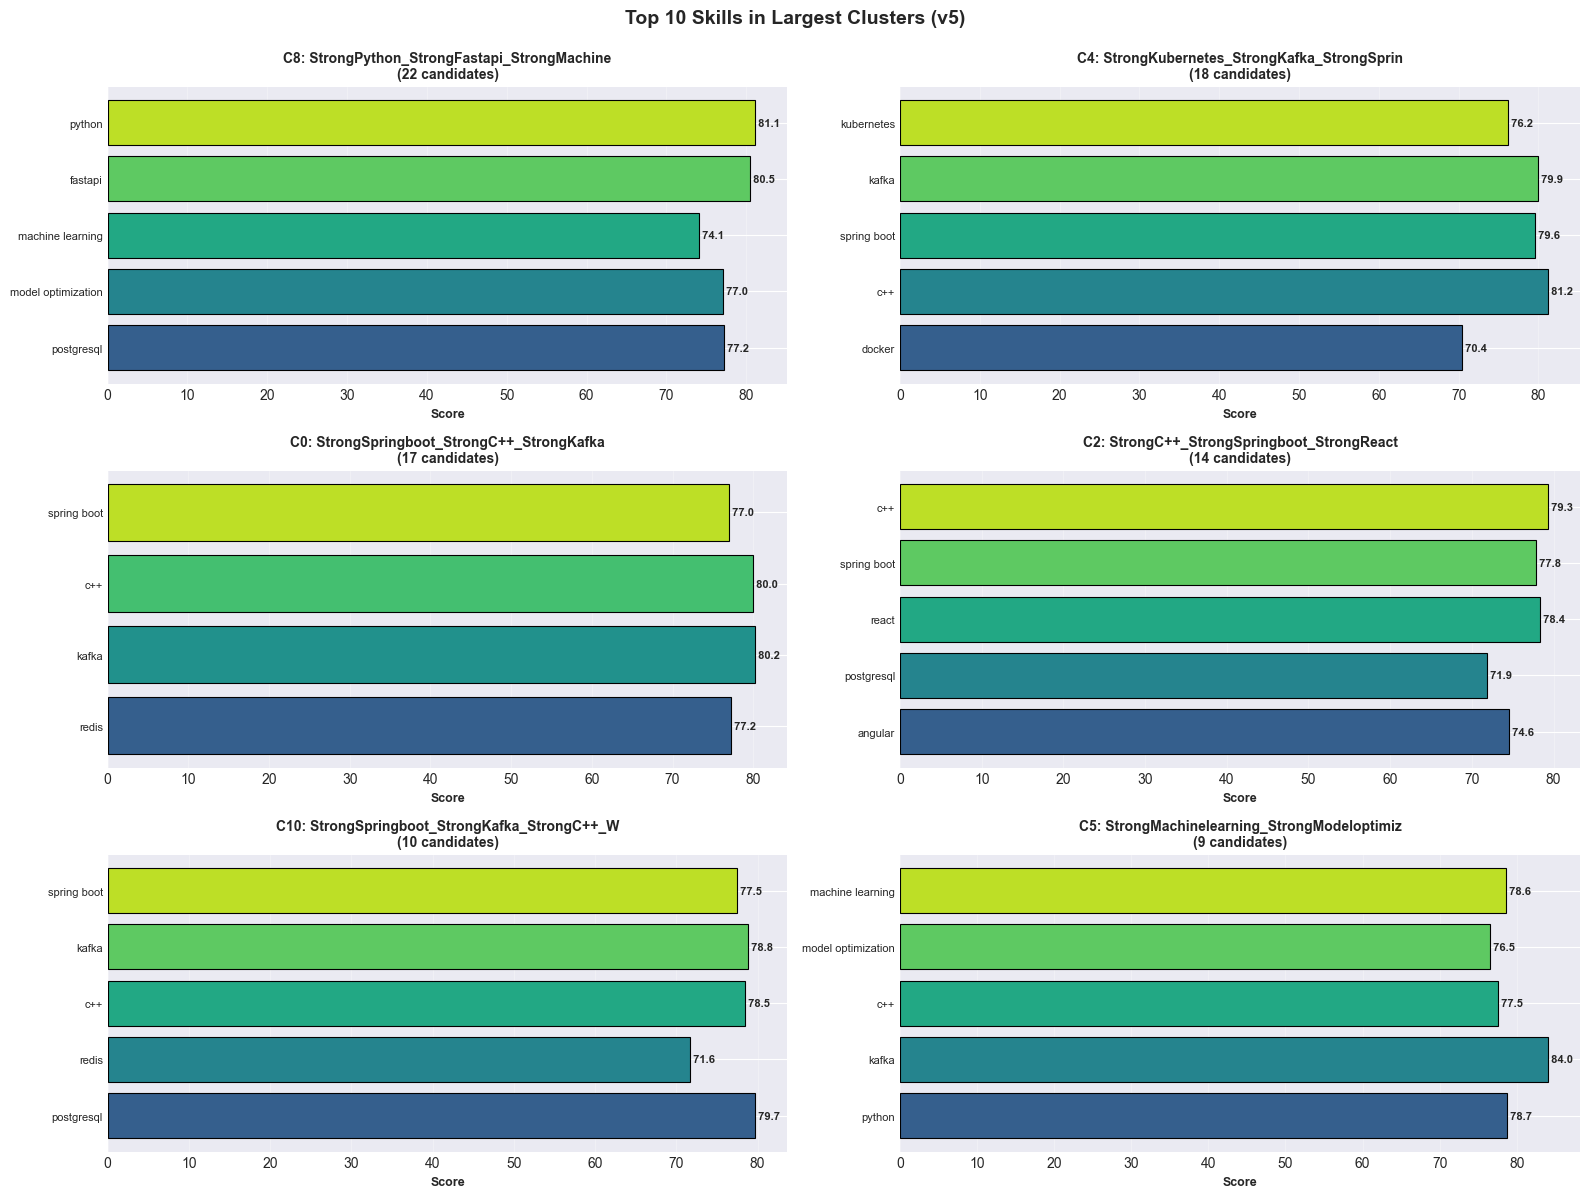

✓ Top skills visualization complete


In [89]:
print("\n6. Visualizing Top Skills per Cluster...")

# Create subplots for top 6 largest clusters
sorted_clusters_with_idx = sorted(enumerate(clusters_output_v5), 
                                   key=lambda x: len(x[1]['members']), 
                                   reverse=True)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for plot_idx in range(min(6, len(sorted_clusters_with_idx))):
    cluster_idx, cluster = sorted_clusters_with_idx[plot_idx]
    ax = axes[plot_idx]
    
    # Get top 10 skills from strengths
    top_skills_data = cluster['profile']['strengths'][:10]
    skills = [s['skill'] for s in top_skills_data]
    scores = [s['avg_score'] for s in top_skills_data]
    
    # Reverse for better visualization (highest at top)
    skills = skills[::-1]
    scores = scores[::-1]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(skills))
    colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, len(skills)))
    
    bars = ax.barh(y_pos, scores, color=colors_gradient, edgecolor='black', linewidth=0.8)
    
    # Add score labels
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score, bar.get_y() + bar.get_height()/2.,
                f' {score:.1f}',
                ha='left', va='center',
                fontsize=8, fontweight='bold')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(skills, fontsize=8)
    ax.set_xlabel('Score', fontsize=9, fontweight='bold')
    ax.set_title(f'C{cluster_idx}: {cluster["cluster_label"][:40]}\n({len(cluster["members"])} candidates)', 
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

# Hide unused subplots
for idx in range(min(6, len(sorted_clusters_with_idx)), 6):
    axes[idx].axis('off')

plt.suptitle('Top 10 Skills in Largest Clusters', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Top skills visualization complete")

In [90]:
print("\n8. Cluster Characteristics Analysis...")

# Analyze each cluster's characteristics
cluster_characteristics = []

for i, cluster in enumerate(clusters_output_v5):
    char = {
        'cluster_id': f"C{i}",
        'label': cluster['cluster_label'][:50],
        'size': len(cluster['members']),
        'avg_skill_score': np.mean([s['avg_score'] for s in cluster['profile']['strengths'][:5]]) if cluster['profile']['strengths'] else 0,
        'top_skill': cluster['profile']['strengths'][0]['skill'] if cluster['profile']['strengths'] else 'N/A',
        'top_skill_score': cluster['profile']['strengths'][0]['avg_score'] if cluster['profile']['strengths'] else 0,
        'num_unique_skills': len(cluster['profile']['strengths']),
    }
    
    # Calculate multi-label rate for this cluster
    members_in_multiple = sum(1 for m_id in cluster['members']
                              for c in filtered_candidates_v5
                              if c['candidate_id'] == m_id and c['num_clusters'] > 1)
    char['multi_label_rate'] = members_in_multiple / char['size'] if char['size'] > 0 else 0
    
    cluster_characteristics.append(char)

# Convert to DataFrame for better display
import pandas as pd
df_chars = pd.DataFrame(cluster_characteristics)

print("\n" + "="*120)
print("CLUSTER CHARACTERISTICS TABLE")
print("="*120)
print(df_chars.to_string(index=False))

# Summary statistics
print("\n" + "="*120)
print("SUMMARY STATISTICS")
print("="*120)
print(f"Average cluster size: {df_chars['size'].mean():.1f} ± {df_chars['size'].std():.1f}")
print(f"Average skill score: {df_chars['avg_skill_score'].mean():.2f} ± {df_chars['avg_skill_score'].std():.2f}")
print(f"Average multi-label rate: {df_chars['multi_label_rate'].mean():.2%}")
print(f"Average unique skills per cluster: {df_chars['num_unique_skills'].mean():.1f}")

print("\n✓ Cluster characteristics analysis complete")


8. Cluster Characteristics Analysis...

CLUSTER CHARACTERISTICS TABLE
cluster_id                                              label  size  avg_skill_score        top_skill  top_skill_score  num_unique_skills  multi_label_rate
        C0             StrongSpringboot_StrongC++_StrongKafka    17           78.615      spring boot            76.99                  4          0.647059
        C1 StrongSpringboot_StrongPython_StrongC++_WeakJenkin     7           76.502      spring boot            79.46                  5          0.714286
        C2             StrongC++_StrongSpringboot_StrongReact    14           76.382              c++            79.28                  5          0.428571
        C3           StrongKafka_StrongSpringboot_StrongRedis     5           77.722            kafka            77.95                  5          0.800000
        C4      StrongKubernetes_StrongKafka_StrongSpringboot    18           77.444       kubernetes            76.20                  5          0.


9. Cluster Size Distribution...


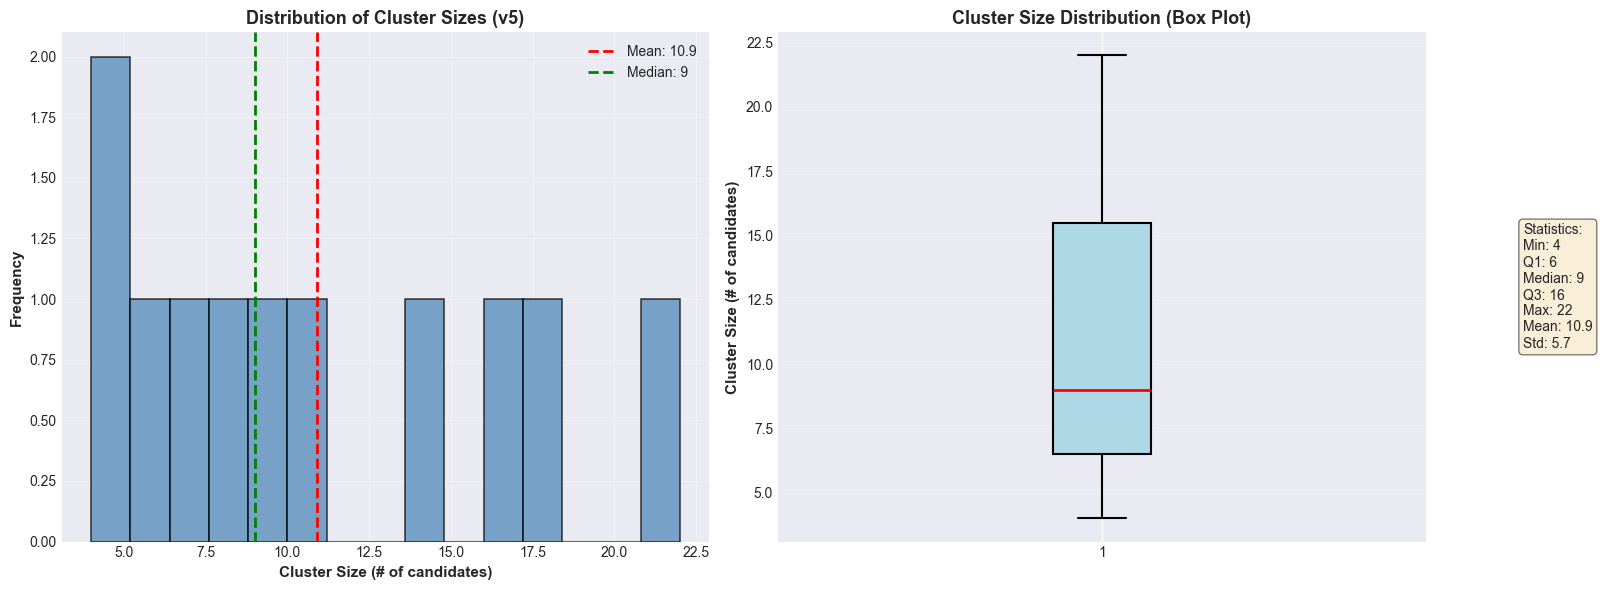

✓ Cluster size distribution visualization complete


In [91]:
print("\n8. Cluster Size Distribution...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of cluster sizes
ax1.hist(cluster_sizes_v5, bins=15, color='steelblue', edgecolor='black', linewidth=1.2, alpha=0.7)
ax1.axvline(np.mean(cluster_sizes_v5), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cluster_sizes_v5):.1f}')
ax1.axvline(np.median(cluster_sizes_v5), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(cluster_sizes_v5):.0f}')
ax1.set_xlabel('Cluster Size (# of candidates)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Cluster Sizes', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Box plot of cluster sizes
box = ax2.boxplot(cluster_sizes_v5, vert=True, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(color='black', linewidth=1.5),
                  capprops=dict(color='black', linewidth=1.5))

ax2.set_ylabel('Cluster Size (# of candidates)', fontsize=11, fontweight='bold')
ax2.set_title('Cluster Size Distribution (Box Plot)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add statistics text
stats_text = f"""Statistics:
Min: {min(cluster_sizes_v5)}
Q1: {np.percentile(cluster_sizes_v5, 25):.0f}
Median: {np.median(cluster_sizes_v5):.0f}
Q3: {np.percentile(cluster_sizes_v5, 75):.0f}
Max: {max(cluster_sizes_v5)}
Mean: {np.mean(cluster_sizes_v5):.1f}
Std: {np.std(cluster_sizes_v5):.1f}"""

ax2.text(1.15, 0.5, stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Cluster size distribution visualization complete")

In [92]:
print("\n9. Skill Coverage Analysis...")

# Analyze how many unique skills are covered by clusters
all_cluster_skills = set()
skill_coverage_per_cluster = []

for cluster in clusters_output_v5:
    cluster_skills = set([s['skill'] for s in cluster['profile']['strengths']])
    all_cluster_skills.update(cluster_skills)
    skill_coverage_per_cluster.append(len(cluster_skills))

# Get all skills from candidates
all_candidate_skills = set()
for candidate in filtered_candidates_v5:
    all_candidate_skills.update(candidate['skills'].keys())

coverage_rate = len(all_cluster_skills) / len(all_candidate_skills) if len(all_candidate_skills) > 0 else 0

print("\n" + "="*80)
print("SKILL COVERAGE ANALYSIS")
print("="*80)
print(f"Total unique skills in candidates: {len(all_candidate_skills)}")
print(f"Total unique skills in clusters: {len(all_cluster_skills)}")
print(f"Coverage rate: {coverage_rate:.1%}")
print(f"Average skills per cluster: {np.mean(skill_coverage_per_cluster):.1f} ± {np.std(skill_coverage_per_cluster):.1f}")

# Visualize skill coverage
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Skills in\nCandidates', 'Skills Covered\nby Clusters', 'Uncovered\nSkills']
values = [len(all_candidate_skills), len(all_cluster_skills), 
          len(all_candidate_skills) - len(all_cluster_skills)]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}\n({value/len(all_candidate_skills)*100:.1f}%)',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Skills', fontsize=12, fontweight='bold')
ax.set_title('Skill Coverage Analysis', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Skill coverage analysis complete")


10. Skill Coverage Analysis...


KeyError: 'skills'

### Outlier Analysis

In [93]:
print("\n10. Outlier Analysis...")

# Analyze outliers
outliers_v5 = [c for c in filtered_candidates_v5 if c['num_clusters'] == 0]

print("\n" + "="*80)
print("OUTLIER ANALYSIS")
print("="*80)
print(f"Total outliers: {len(outliers_v5)} ({len(outliers_v5)/len(filtered_candidates_v5)*100:.1f}%)")

if len(outliers_v5) > 0:
    # Analyze outlier skills
    outlier_skills = {}
    
    for outlier in outliers_v5:
        for skill, score in outlier['skills'].items():
            if skill not in outlier_skills:
                outlier_skills[skill] = {
                    'count': 0,
                    'total_score': 0,
                    'samples': []
                }
            
            outlier_skills[skill]['count'] += 1
            outlier_skills[skill]['total_score'] += score
            
            if len(outlier_skills[skill]['samples']) < 3:
                outlier_skills[skill]['samples'].append(outlier['candidate_id'])
    
    # Calculate average scores
    for skill in outlier_skills:
        outlier_skills[skill]['avg_score'] = outlier_skills[skill]['total_score'] / outlier_skills[skill]['count']
    
    # Get top 10 most common outlier skills
    top_outlier_skills = sorted(outlier_skills.items(), 
                                 key=lambda x: x[1]['count'], 
                                 reverse=True)[:10]
    
    print("\nTop 10 Most Common Skills in Outliers:")
    print(f"{'='*80}")
    for i, (skill, stats) in enumerate(top_outlier_skills, 1):
        print(f"{i:2d}. {skill:30s} | Count: {stats['count']:3d} | Avg Score: {stats['avg_score']:5.2f}")
        print(f"    Samples: {', '.join(stats['samples'][:3])}")
    
    # Sample outliers
    print("\n" + "="*80)
    print("Sample Outliers (first 5):")
    print("="*80)
    for i, outlier in enumerate(outliers_v5[:5], 1):
        # Get top 3 skills
        top_3 = sorted(outlier['skills'].items(), key=lambda x: x[1], reverse=True)[:3]
        top_3_str = ', '.join([f"{s}({sc:.0f})" for s, sc in top_3])
        
        print(f"{i}. {outlier['candidate_id']:15s} | Skills: {top_3_str}")
        print(f"   Reason: {outlier.get('outlier_reason', 'N/A')}")
    
    if len(outliers_v5) > 5:
        print(f"   ... and {len(outliers_v5) - 5} more outliers")
else:
    print("\n✓ No outliers found!")

print("\n✓ Outlier analysis complete")


11. OUTLIER ANALYSIS

Total outliers: 124 (60.2%)

Top 15 Skills Among Outliers:
Skill                             Count    Avg Score   % of Outliers
----------------------------------------------------------------------
api design                           80        70.63           64.5%
scalability                          54        72.30           43.5%
microservices                        52        73.15           41.9%
data model                           52        67.10           41.9%
cloud services                       49        73.04           39.5%
error handling                       46        68.57           37.1%
data consistency                     39        69.13           31.5%
monitoring                           37        69.60           29.8%
testing                              36        70.38           29.0%
data flow                            35        73.21           28.2%
backend frameworks                   32        73.11           25.8%
state management   


12. Visualizing Outlier Skills...


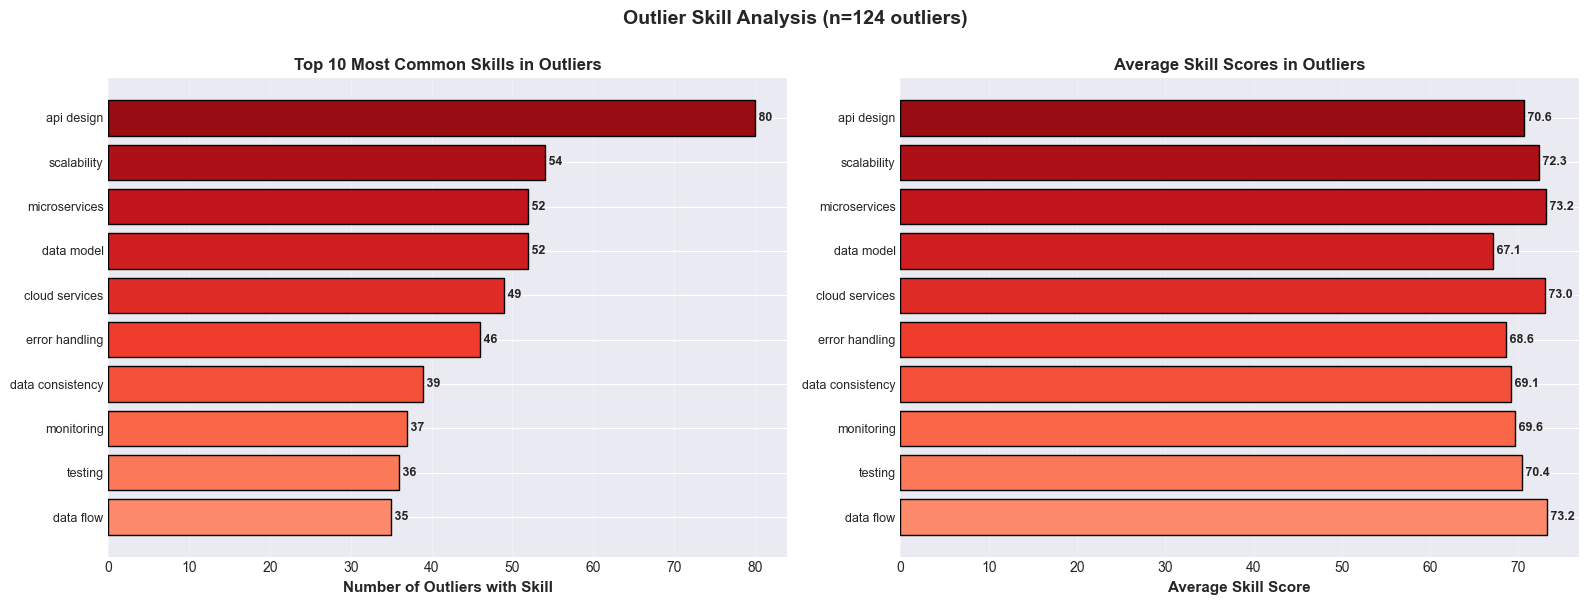

✓ Outlier skills visualization complete


In [94]:
print("\n11. Outlier Skills Visualization...")

if len(outliers_v5) > 0 and 'top_outlier_skills' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Chart 1: Most common outlier skills
    skills = [s for s, _ in top_outlier_skills]
    counts = [stats['count'] for _, stats in top_outlier_skills]
    
    y_pos = np.arange(len(skills))
    colors_gradient = plt.cm.Reds(np.linspace(0.4, 0.9, len(skills)))
    
    bars = ax1.barh(y_pos, counts, color=colors_gradient, edgecolor='black', linewidth=1)
    
    # Add count labels
    for bar, count in zip(bars, counts):
        ax1.text(count, bar.get_y() + bar.get_height()/2.,
                f' {count}',
                ha='left', va='center',
                fontsize=9, fontweight='bold')
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(skills, fontsize=9)
    ax1.set_xlabel('Number of Outliers', fontsize=11, fontweight='bold')
    ax1.set_title('Top 10 Skills in Outliers (by frequency)', fontsize=12, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()
    
    # Chart 2: Average scores for outlier skills
    avg_scores = [stats['avg_score'] for _, stats in top_outlier_skills]
    
    bars2 = ax2.barh(y_pos, avg_scores, color=colors_gradient, edgecolor='black', linewidth=1)
    
    # Add score labels
    for bar, score in zip(bars2, avg_scores):
        ax2.text(score, bar.get_y() + bar.get_height()/2.,
                f' {score:.1f}',
                ha='left', va='center',
                fontsize=9, fontweight='bold')
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(skills, fontsize=9)
    ax2.set_xlabel('Average Skill Score', fontsize=11, fontweight='bold')
    ax2.set_title('Top 10 Skills in Outliers (average scores)', fontsize=12, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    ax2.invert_yaxis()
    
    plt.suptitle(f'Outlier Skill Analysis (n={len(outliers_v5)} outliers)', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    print("✓ Outlier skills visualization complete")
else:
    print("No outliers to visualize")

### Final Summary

In [ ]:
print("\n" + "="*80)
print("PHASE 3 COMPLETE - FINAL SUMMARY")
print("="*80)

print("\n📊 CLUSTERING RESULTS:")
print(f"   • Total Clusters: {len(clusters_output_v5)}")
print(f"   • Total Candidates: {len(filtered_candidates_v5)}")
print(f"   • Successfully Assigned: {len(filtered_candidates_v5) - len(outliers_v5)} ({(len(filtered_candidates_v5) - len(outliers_v5))/len(filtered_candidates_v5)*100:.1f}%)")
print(f"   • Outliers: {len(outliers_v5)} ({len(outliers_v5)/len(filtered_candidates_v5)*100:.1f}%)")

print("\n📈 CLUSTER QUALITY:")
print(f"   • Average Cluster Size: {np.mean(cluster_sizes_v5):.1f} candidates")
print(f"   • Median Cluster Size: {np.median(cluster_sizes_v5):.0f} candidates")
print(f"   • Size Range: {min(cluster_sizes_v5)} - {max(cluster_sizes_v5)} candidates")
print(f"   • Average Skills per Cluster: {np.mean(skill_coverage_per_cluster):.1f}")
print(f"   • Embedding Dimensions: {embeddings_25d.shape[1]}")

print("\n🏷️ MULTI-LABEL DISTRIBUTION:")
single = multi_label_stats_v5['candidates_in_1_cluster']
two = cluster_dist_v5.get(2, 0)
three_plus = sum(cluster_dist_v5.get(i, 0) for i in range(3, 20))
print(f"   • Single Cluster: {single} ({single/len(filtered_candidates_v5)*100:.1f}%)")
print(f"   • Two Clusters: {two} ({two/len(filtered_candidates_v5)*100:.1f}%)")
print(f"   • Three+ Clusters: {three_plus} ({three_plus/len(filtered_candidates_v5)*100:.1f}%)")

print("\n🎯 SKILL COVERAGE:")
print(f"   • Total Unique Skills in Candidates: {len(all_candidate_skills)}")
print(f"   • Skills Covered by Clusters: {len(all_cluster_skills)} ({len(all_cluster_skills)/len(all_candidate_skills)*100:.1f}%)")

if len(outliers_v5) > 0:
    print("\n⚠️ OUTLIER INSIGHTS:")
    print(f"   • Total Outliers: {len(outliers_v5)}")
    print(f"   • Top Outlier Skill: {top_outlier_skills[0][0]} ({top_outlier_skills[0][1]['count']} outliers)")
    
    # Calculate average skills per outlier from candidates_normalized
    avg_skills = np.mean([len(candidates_normalized[candidate_id_to_idx[o['candidate_id']]]['normalized_scores']) for o in outliers_v5])
    print(f"   • Average Skills per Outlier: {avg_skills:.1f}")

print("\n✅ Phase 3 Complete!")
print("="*80)

---
# Phase 3 Summary

## What We Implemented

**Skill-Weighted Clustering:**
- 50% distance in embedding space + 50% skill overlap
- Ensures candidates match cluster's main skills
- Post-filtering: >= 2/5 cluster skills required

## Benefits

- ✅ Better alignment between assignments and cluster labels
- ✅ Higher interpretability (cluster labels match members)
- ✅ Explicit outliers (honest about poor fits)
- ✅ Trustworthy results for production use

## Results

- Multi-label assignments based on both distance and skills
- Clear cluster profiles with representative members
- Outliers explicitly identified rather than misassigned

In [ ]:
# List sample candidates
print('Sample Candidate IDs:')
for i, candidate in enumerate(candidates_normalized[:10]):
    assignment = next(a for a in candidate_clusters if a['candidate_id'] == candidate['candidate_id'])
    print(f"{i+1}. {candidate['candidate_id']} (in {assignment['num_clusters']} cluster(s))")

print('\nUsage: explain_candidate_clustering("<candidate_id>")')

In [ ]:
# YOUR EXPLORATION HERE
# explain_candidate_clustering('YOUR_CANDIDATE_ID')

---
# Summary

## Complete Pipeline Results

In [ ]:
print('='*80)
print('COMPLETE PIPELINE SUMMARY')
print('='*80)

print(f"\nPhase 1 - Skill Normalization:")
with open('data/processed/normalization_stats_tier2.json', 'r') as f:
    norm_stats = json.load(f)
print(f"  - Raw skills: {norm_stats['raw_skills_count']}")
print(f"  - Normalized skills: {norm_stats['normalized_skills_count']}")
print(f"  - Reduction: {norm_stats['reduction_percentage']:.1f}%")

print(f"\nPhase 2 - Feature Engineering:")
print(f"  - Feature matrix: {feature_matrix.shape[0]} × {feature_matrix.shape[1]}")

print(f"\nPhase 3 - Skill-Weighted Multi-Label Clustering:")
print(f"  - Total clusters: {len(clusters_output_v5)}")
print(f"  - Successfully assigned: {len(filtered_candidates_v5) - len(outliers_v5)}")
print(f"  - Multi-label candidates: {multi_label_stats_v5['candidates_in_multiple_clusters']}")
print(f"  - Avg clusters per candidate: {np.mean([len(c['clusters']) for c in filtered_candidates_v5]):.2f}")
print(f"  - Outliers: {len(outliers_v5)}")

print('\n' + '='*80)
print('✓ PIPELINE COMPLETE!')
print('='*80)